In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kavyadhyani/global-oil-prices-and-geopolitical-events/oil_geopolitics_dataset_2010_2026.csv
/kaggle/input/datasets/kavyadhyani/global-oil-prices-and-geopolitical-events/geopolitical_events_timeline.csv


# Problem Statement

Oil prices are highly volatile and influenced by geopolitical events, making accurate forecasting challenging. Traditional models struggle to capture complex relationships between global events, market fear, and crude prices.

**Key Question:**
How can we predict oil prices accurately by incorporating geopolitical risk indicators and market sentiment?

**Why AI Adoption Matters**

- Traditional statistical models fail to capture non-linear interactions in global markets.

- AI and machine learning can detect patterns between geopolitical events, market sentiment, and price movements.

- Predictive AI helps stakeholders make informed decisions and mitigate risk.

**Objectives of this Notebook**

- Analyze 16 years of Brent & WTI prices alongside geopolitical events (2010–2026).

- Quantify the impact of wars, sanctions, and OPEC decisions on oil markets.

- Build ML models (LightGBM, XGBoost, ensembles) to predict prices with < $2 error margin.

- Explain model predictions using SHAP to identify key drivers.

- Forecast future prices with Prophet and time series analysis.

- Detect oil shocks and volatility regimes automatically.

- Visualize insights through interactive dashboards.

#  IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from datetime import timedelta
import itertools


import xgboost as xgb
import lightgbm as lgb
import shap
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from prophet import Prophet

warnings.filterwarnings('ignore')

#  CONFIGURATION & STYLING

In [3]:

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams.update({
    'figure.figsize': (16, 8),'figure.dpi': 150,'figure.facecolor': 'white','axes.facecolor': '#f8f9fa',
    'axes.grid': True,'grid.alpha': 0.3,'grid.linestyle': '--','axes.spines.top': False,'axes.spines.right': False,
    'font.size': 11,'axes.titlesize': 14,'axes.titleweight': 'bold','axes.labelsize': 12, 'legend.fontsize': 10,'xtick.labelsize': 10,'ytick.labelsize': 10
})


COLORS = {
    'brent': '#1f77b4', 'wti': '#d62728', 'gpr': '#2ca02c', 'vix': '#ff7f0e', 'dxy': '#9467bd','spread': '#17becf','event': '#e377c2','volatility': '#7f7f7f',
    'positive': '#2ecc71','negative': '#e74c3c','shock': '#e74c3c','forecast': '#3498db'
}

#  DATA LOADING & INITIAL INSPECTION

## Load datasets

In [4]:

oil_path = "/kaggle/input/datasets/kavyadhyani/global-oil-prices-and-geopolitical-events/oil_geopolitics_dataset_2010_2026.csv"
event_path = "/kaggle/input/datasets/kavyadhyani/global-oil-prices-and-geopolitical-events/geopolitical_events_timeline.csv"

df = pd.read_csv(oil_path, parse_dates=["date"])
events_timeline = pd.read_csv(event_path, parse_dates=["date"])

# Sort and clean
df = df.sort_values('date').reset_index(drop=True)

# Merge event data
df = df.merge(events_timeline,on="date",how="left",suffixes=("", "_timeline"))
df["event_flag"] = df["event_type"].notna().astype(int)


## Dataset overview

In [5]:



print(f"Oil Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Event Dataset Shape: {events_timeline.shape[0]:,} rows × {events_timeline.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Trading days: {df['date'].nunique():,}")
print(f"Geopolitical events flagged: {df['event_flag'].sum():,} ({df['event_flag'].mean()*100:.2f}% of days)")

# Basic info

print(df.dtypes.to_string())

# Memory usage


print(f"Total memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Display samples

print("DATA SAMPLES")

print("\nOil Dataset Head:")
print(df.head())
print("\nEvents Timeline Head:")
print(events_timeline.head())

Oil Dataset Shape: 4,047 rows × 26 columns
Event Dataset Shape: 35 rows × 4 columns
Date range: 2010-02-17 to 2026-03-12
Trading days: 4,047
Geopolitical events flagged: 4,047 (100.00% of days)
date                          datetime64[ns]
brent_price                          float64
wti_price                            float64
dxy_index                            float64
vix                                  float64
gpr_index                            float64
brent_return                         float64
wti_return                           float64
brent_lag_1                          float64
brent_lag_3                          float64
brent_lag_7                          float64
wti_lag_1                            float64
wti_lag_3                            float64
wti_lag_7                            float64
brent_volatility_7d                  float64
brent_volatility_30d                 float64
wti_volatility_7d                    float64
wti_volatility_30d                   floa

#  MISSING VALUES & DATA QUALITY

                            Missing  Percentage
event_type_timeline            4022       99.38
event_description_timeline     4022       99.38
event_severity_timeline        4022       99.38


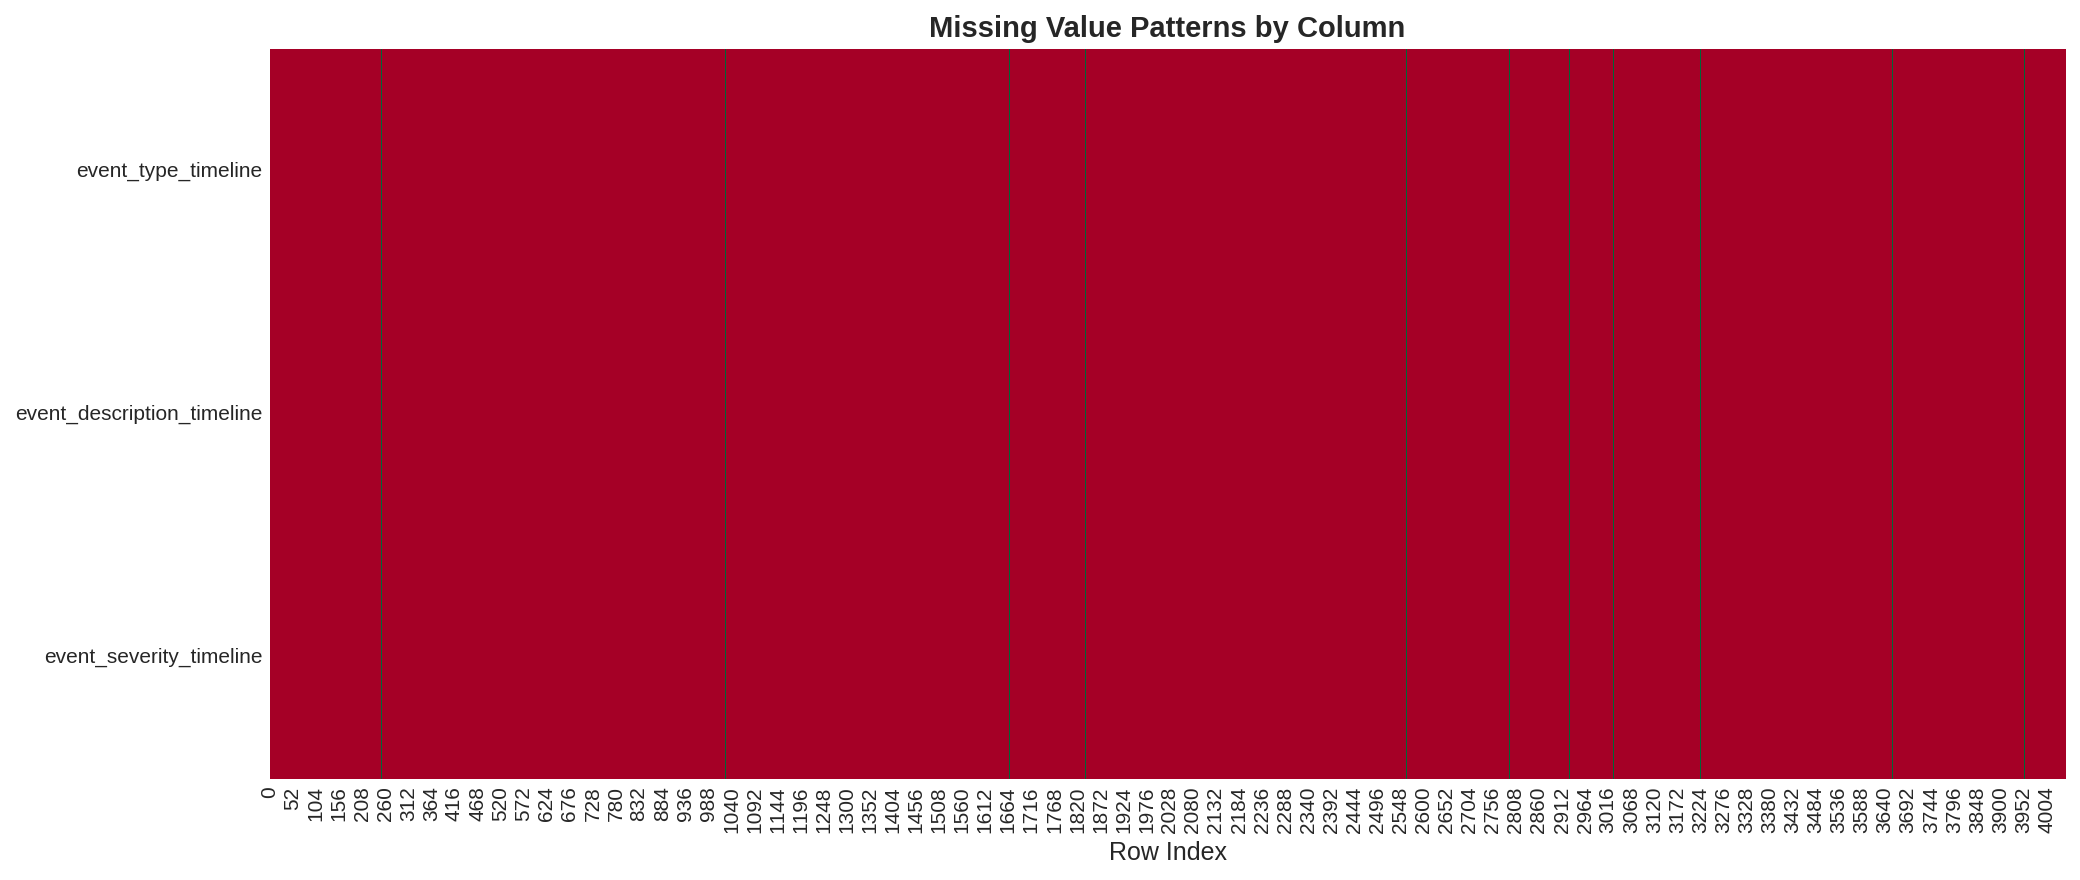


Duplicate dates: 0
brent_price: min=$19.33, max=$127.98, negatives=0, zeros=0
wti_price: min=$-37.63, max=$123.70, negatives=1, zeros=0


In [6]:
missing_df = pd.DataFrame({
    'Missing': df.isnull().sum(),
    'Percentage': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Missing > 0').sort_values('Percentage', ascending=False)

if missing_df.empty:
    print(" No missing ")
else:
    print(missing_df.to_string())
    
    # Visualize missing patterns
    fig, ax = plt.subplots(figsize=(14, 6))
    msno_matrix = df[df.columns[df.isnull().any()].tolist()].isnull()
    sns.heatmap(msno_matrix.T, cbar=False, cmap='RdYlGn_r', ax=ax, yticklabels=True)
    ax.set_title('Missing Value Patterns by Column', fontweight='bold', fontsize=14)
    ax.set_xlabel('Row Index')
    plt.tight_layout()
    plt.show()

# Duplicate check
duplicates = df.duplicated(subset='date').sum()
print(f"\nDuplicate dates: {duplicates}")


# Price validation
price_cols = ['brent_price', 'wti_price']
for col in price_cols:
    negatives = (df[col] < 0).sum()
    zeros = (df[col] == 0).sum()
    print(f"{col}: min=${df[col].min():.2f}, max=${df[col].max():.2f}, "
          f"negatives={negatives}, zeros={zeros}")


#  DESCRIPTIVE STATISTICS

In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
stats_df = df[numeric_cols].describe().T
stats_df['skewness'] = df[numeric_cols].skew()
stats_df['kurtosis'] = df[numeric_cols].kurtosis()
stats_df['range'] = stats_df['max'] - stats_df['min']
stats_df['cv'] = stats_df['std'] / stats_df['mean']  

print("\nKey Statistics:")

print(f"Average Brent price: ${df['brent_price'].mean():.2f}/bbl")
print(f"Average WTI price: ${df['wti_price'].mean():.2f}/bbl")
print(f"Average GPR index: {df['gpr_index'].mean():.1f}")
print(f"Average VIX: {df['vix'].mean():.1f}")
print(f"Average DXY: {df['dxy_index'].mean():.1f}")

print("\nExtreme Values:")

print(f"Brent all-time high: ${df['brent_price'].max():.2f} ({df.loc[df['brent_price'].idxmax(), 'date'].date()})")
print(f"Brent all-time low: ${df['brent_price'].min():.2f} ({df.loc[df['brent_price'].idxmin(), 'date'].date()})")
print(f"Highest GPR: {df['gpr_index'].max():.1f} ({df.loc[df['gpr_index'].idxmax(), 'date'].date()})")
print(f"Highest VIX: {df['vix'].max():.1f} ({df.loc[df['vix'].idxmax(), 'date'].date()})")

print("\nSummary Statistics Table:")
print(stats_df.round(4))


Key Statistics:
Average Brent price: $77.62/bbl
Average WTI price: $71.42/bbl
Average GPR index: 102.6
Average VIX: 18.4
Average DXY: 92.9

Extreme Values:
Brent all-time high: $127.98 (2022-03-08)
Brent all-time low: $19.33 (2020-04-21)
Highest GPR: 319.0 (2022-03-01)
Highest VIX: 82.7 (2020-03-16)

Summary Statistics Table:
                          count      mean      std      min      25%      50%  \
brent_price              4047.0   77.6239  23.5293  19.3300  60.7850  75.1700   
wti_price                4047.0   71.4175  20.7773 -37.6300  54.3400  71.1200   
dxy_index                4047.0   92.9090   9.2855  72.9300  82.7350  95.3100   
vix                      4047.0   18.3932   6.8538   9.1400  13.7750  16.6500   
gpr_index                4047.0  102.5964  31.5592  58.4208  81.3896  93.5213   
brent_return             4047.0    0.0003   0.0224  -0.2440  -0.0097   0.0005   
wti_return               4047.0   -0.0005   0.0581  -3.0597  -0.0115   0.0009   
brent_lag_1            

#  TIME SERIES VISUALIZATION

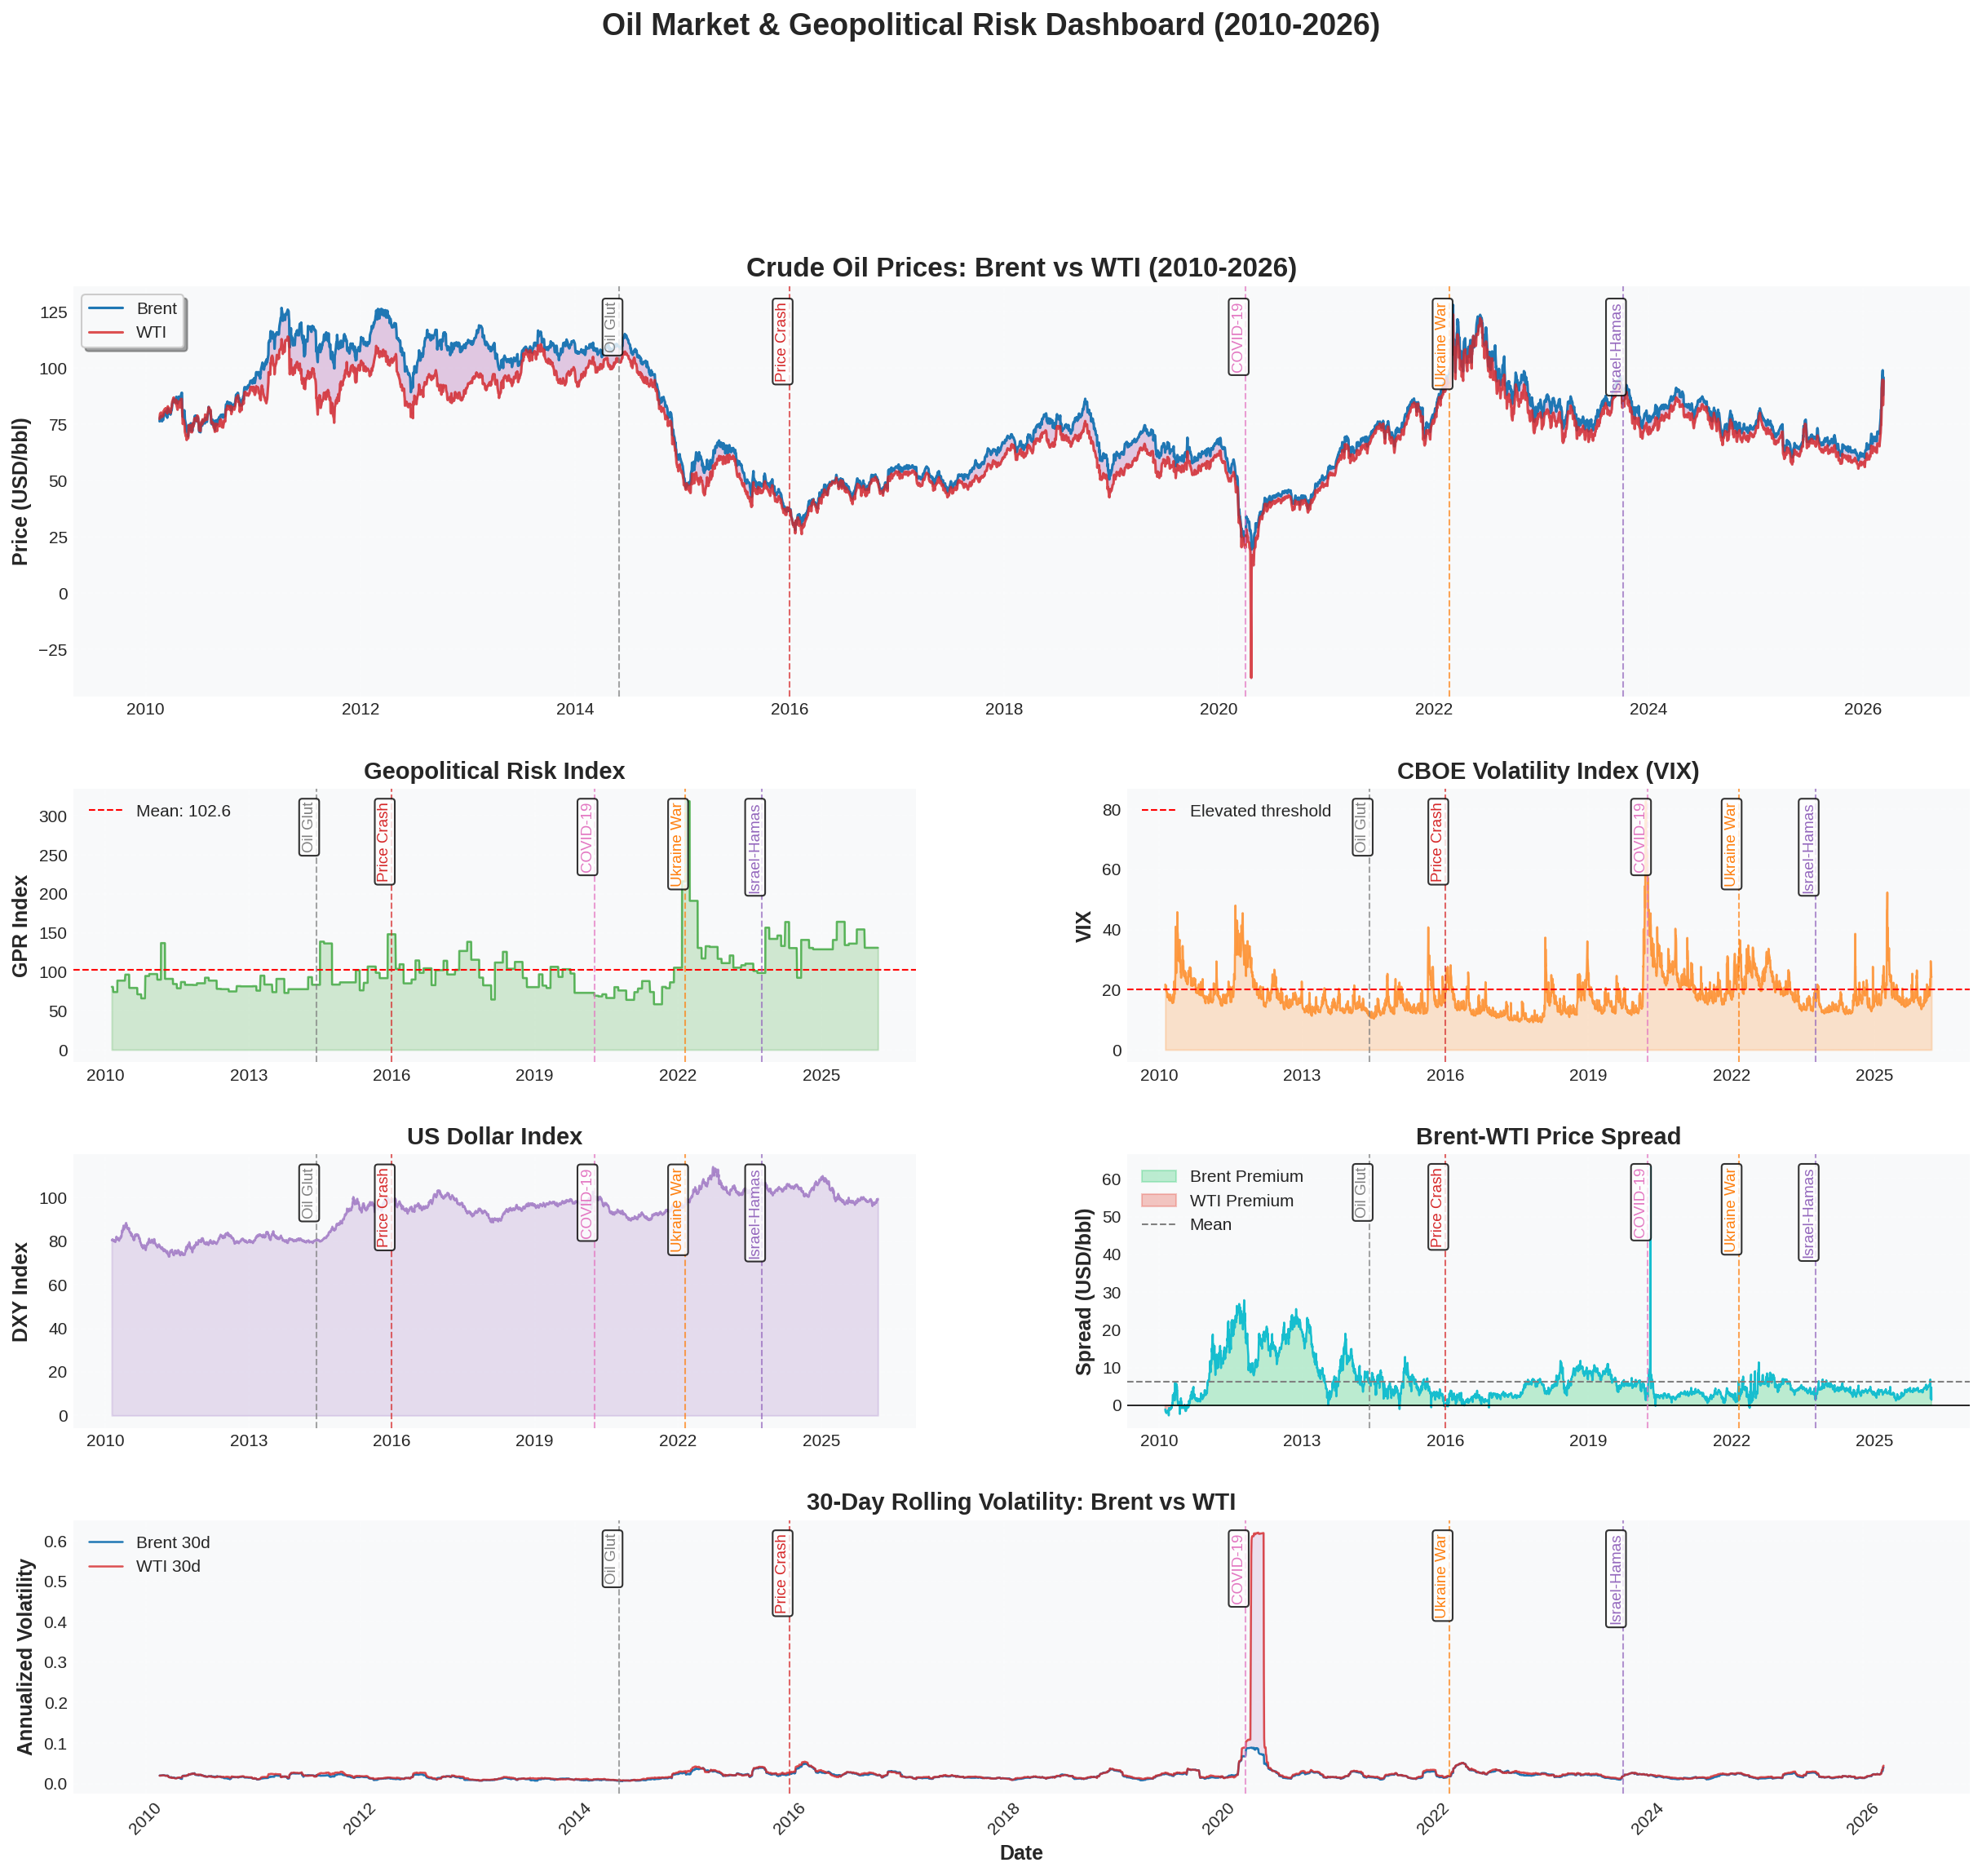

In [8]:
fig = plt.figure(figsize=(20, 16))
gs = gridspec.GridSpec(4, 2, height_ratios=[1.5, 1, 1, 1], hspace=0.3, wspace=0.25)

# Major events for annotation
major_events = {
    '2014-06-01': ('Oil Glut', 'gray'),
    '2016-01-01': ('Price Crash', '#d62728'),
    '2020-04-01': ('COVID-19', '#e377c2'),
    '2022-02-24': ('Ukraine War', '#ff7f0e'),
    '2023-10-07': ('Israel-Hamas', '#9467bd'),
}

def add_event_lines(ax):
    ylim = ax.get_ylim()
    for date_str, (label, color) in major_events.items():
        date = pd.Timestamp(date_str)
        ax.axvline(date, color=color, linestyle='--', alpha=0.7, linewidth=1)
        ax.text(date, ylim[1]*0.95, label, rotation=90, color=color, fontsize=9,
                ha='right', va='top', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

# Panel 1: Brent & WTI prices
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['date'], df['brent_price'], color=COLORS['brent'], linewidth=1.5, label='Brent')
ax1.plot(df['date'], df['wti_price'], color=COLORS['wti'], linewidth=1.5, label='WTI', alpha=0.8)
ax1.fill_between(df['date'], df['brent_price'], df['wti_price'], alpha=0.2, color='purple')
ax1.set_ylabel('Price (USD/bbl)', fontweight='bold')
ax1.set_title('Crude Oil Prices: Brent vs WTI (2010-2026)', fontweight='bold', fontsize=16)
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.grid(True, alpha=0.3)
add_event_lines(ax1)

# Panel 2: GPR Index
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(df['date'], df['gpr_index'], color=COLORS['gpr'], linewidth=1.2, alpha=0.7)
ax2.fill_between(df['date'], df['gpr_index'], alpha=0.2, color=COLORS['gpr'])
ax2.axhline(df['gpr_index'].mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {df["gpr_index"].mean():.1f}')
ax2.set_ylabel('GPR Index', fontweight='bold')
ax2.set_title('Geopolitical Risk Index', fontweight='bold')
ax2.legend(loc='upper left')
ax2.xaxis.set_major_locator(mdates.YearLocator(3))
add_event_lines(ax2)

# Panel 3: VIX (Fear Index)
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(df['date'], df['vix'], color=COLORS['vix'], linewidth=1.2, alpha=0.7)
ax3.fill_between(df['date'], df['vix'], alpha=0.2, color=COLORS['vix'])
ax3.axhline(20, color='red', linestyle='--', linewidth=1, label='Elevated threshold')
ax3.set_ylabel('VIX', fontweight='bold')
ax3.set_title('CBOE Volatility Index (VIX)', fontweight='bold')
ax3.legend(loc='upper left')
ax3.xaxis.set_major_locator(mdates.YearLocator(3))
add_event_lines(ax3)

# Panel 4: DXY (Dollar Index)
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(df['date'], df['dxy_index'], color=COLORS['dxy'], linewidth=1.2, alpha=0.7)
ax4.fill_between(df['date'], df['dxy_index'], alpha=0.2, color=COLORS['dxy'])
ax4.set_ylabel('DXY Index', fontweight='bold')
ax4.set_title('US Dollar Index', fontweight='bold')
ax4.xaxis.set_major_locator(mdates.YearLocator(3))
add_event_lines(ax4)

# Panel 5: Brent-WTI Spread
ax5 = fig.add_subplot(gs[2, 1])
ax5.plot(df['date'], df['brent_wti_spread'], color=COLORS['spread'], linewidth=1.2)
ax5.fill_between(df['date'], df['brent_wti_spread'], 0,
                 where=(df['brent_wti_spread'] > 0), alpha=0.3, color=COLORS['positive'], label='Brent Premium')
ax5.fill_between(df['date'], df['brent_wti_spread'], 0,
                 where=(df['brent_wti_spread'] < 0), alpha=0.3, color=COLORS['negative'], label='WTI Premium')
ax5.axhline(0, color='black', linewidth=0.8)
ax5.axhline(df['brent_wti_spread'].mean(), color='gray', linestyle='--', linewidth=1, label='Mean')
ax5.set_ylabel('Spread (USD/bbl)', fontweight='bold')
ax5.set_title('Brent-WTI Price Spread', fontweight='bold')
ax5.legend(loc='upper left')
ax5.xaxis.set_major_locator(mdates.YearLocator(3))
add_event_lines(ax5)

# Panel 6: Volatility
ax6 = fig.add_subplot(gs[3, :])
ax6.plot(df['date'], df['brent_volatility_30d'], color=COLORS['brent'], linewidth=1.2, label='Brent 30d')
ax6.plot(df['date'], df['wti_volatility_30d'], color=COLORS['wti'], linewidth=1.2, label='WTI 30d', alpha=0.8)
ax6.fill_between(df['date'], df['brent_volatility_30d'], df['wti_volatility_30d'], alpha=0.1, color='purple')
ax6.set_ylabel('Annualized Volatility', fontweight='bold')
ax6.set_xlabel('Date', fontweight='bold')
ax6.set_title('30-Day Rolling Volatility: Brent vs WTI', fontweight='bold')
ax6.legend(loc='upper left')
ax6.xaxis.set_major_locator(mdates.YearLocator(2))
ax6.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=45)
add_event_lines(ax6)

plt.suptitle('Oil Market & Geopolitical Risk Dashboard (2010-2026)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  CORRELATION ANALYSIS

Brent-WTI Correlation: 0.9784716762886517


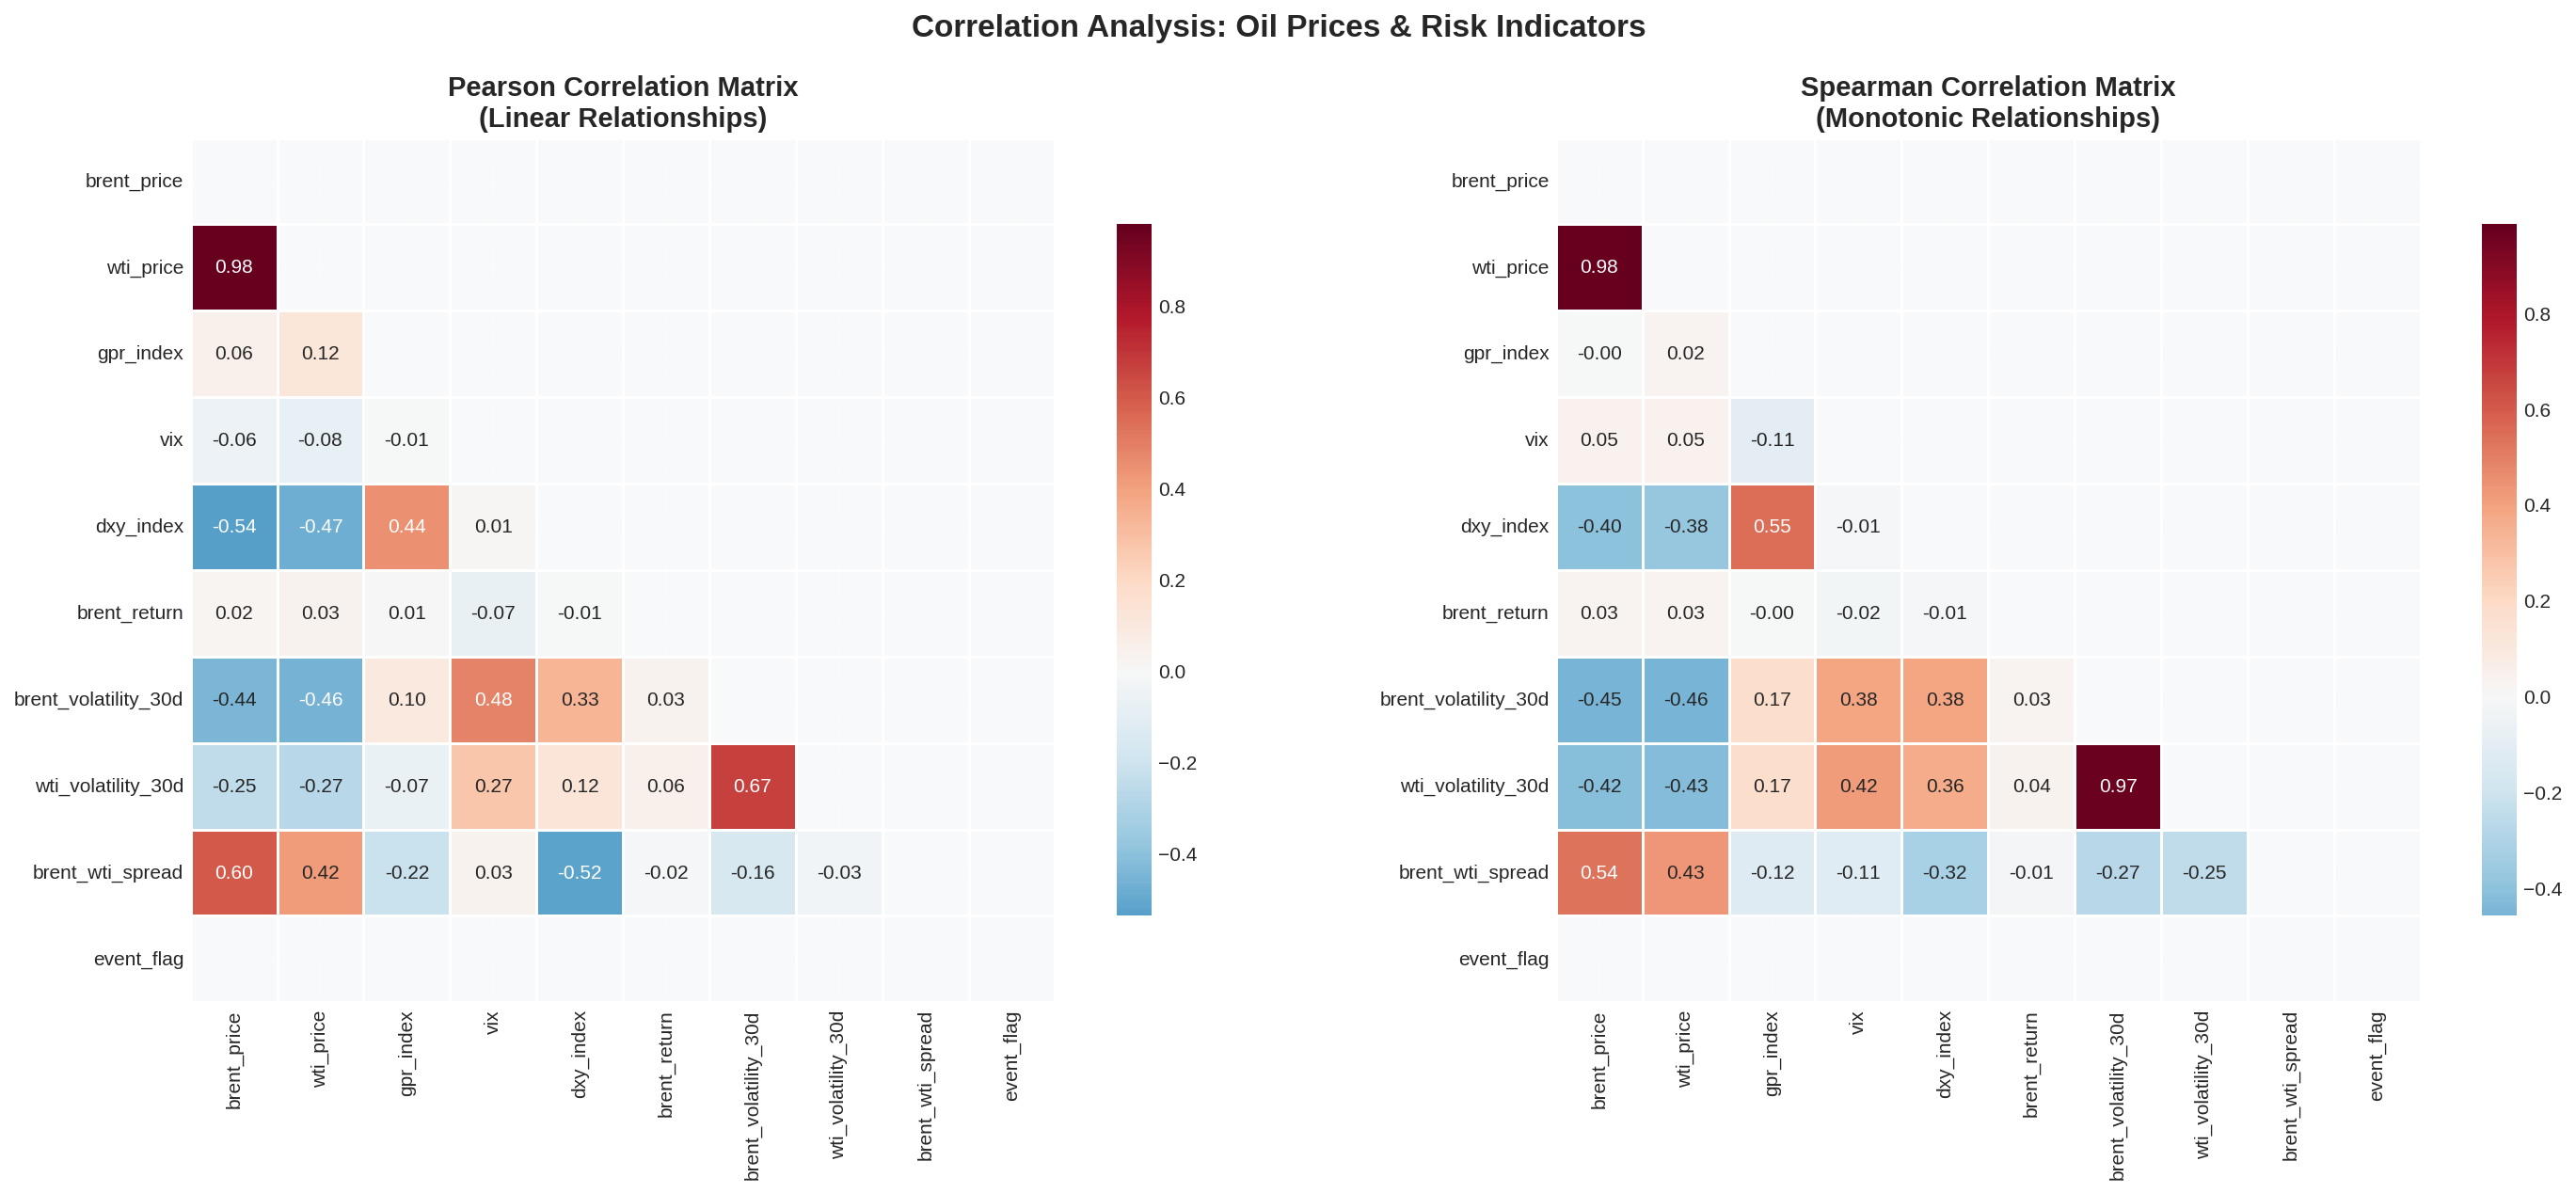

Price co-movement                  : Pearson r =  0.9785***, Spearman ρ =  0.9849
Oil price vs GPR                   : Pearson r =  0.0555***, Spearman ρ = -0.0036
Oil vs USD                         : Pearson r = -0.5361***, Spearman ρ = -0.3989
GPR vs Market Fear                 : Pearson r = -0.0094, Spearman ρ = -0.1076
GPR vs Oil Volatility              : Pearson r =  0.0954***, Spearman ρ =  0.1695
Return vs Volatility               : Pearson r =  0.0342*, Spearman ρ =  0.0317


In [9]:
# Select key variables for correlation
corr_vars = ['brent_price', 'wti_price', 'gpr_index', 'vix', 'dxy_index',
             'brent_return', 'brent_volatility_30d', 'wti_volatility_30d',
             'brent_wti_spread', 'event_flag']

corr_df = df[corr_vars].copy()

# Calculate correlation matrices
pearson_corr = corr_df.corr(method='pearson')
spearman_corr = corr_df.corr(method='spearman')

print("Brent-WTI Correlation:", df[["brent_price","wti_price"]].corr().iloc[0,1])

# Create correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Pearson correlation
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))
sns.heatmap(pearson_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10}, ax=axes[0])
axes[0].set_title('Pearson Correlation Matrix\n(Linear Relationships)', fontweight='bold', fontsize=14)

# Spearman correlation
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10}, ax=axes[1])
axes[1].set_title('Spearman Correlation Matrix\n(Monotonic Relationships)', fontweight='bold', fontsize=14)

plt.suptitle('Correlation Analysis: Oil Prices & Risk Indicators', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Key correlations with p-values


key_pairs = [
    ('brent_price', 'wti_price', 'Price co-movement'),
    ('brent_price', 'gpr_index', 'Oil price vs GPR'),
    ('brent_price', 'dxy_index', 'Oil vs USD'),
    ('gpr_index', 'vix', 'GPR vs Market Fear'),
    ('gpr_index', 'brent_volatility_30d', 'GPR vs Oil Volatility'),
    ('brent_return', 'brent_volatility_30d', 'Return vs Volatility')
]

for var1, var2, label in key_pairs:
    if var1 in df.columns and var2 in df.columns:
        clean_data = df[[var1, var2]].dropna()
        pearson_r, p_value = pearsonr(clean_data[var1], clean_data[var2])
        spearman_r, _ = spearmanr(clean_data[var1], clean_data[var2])
        sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        print(f"{label:35s}: Pearson r = {pearson_r:7.4f}{sig}, Spearman ρ = {spearman_r:7.4f}")

# DISTRIBUTION ANALYSIS

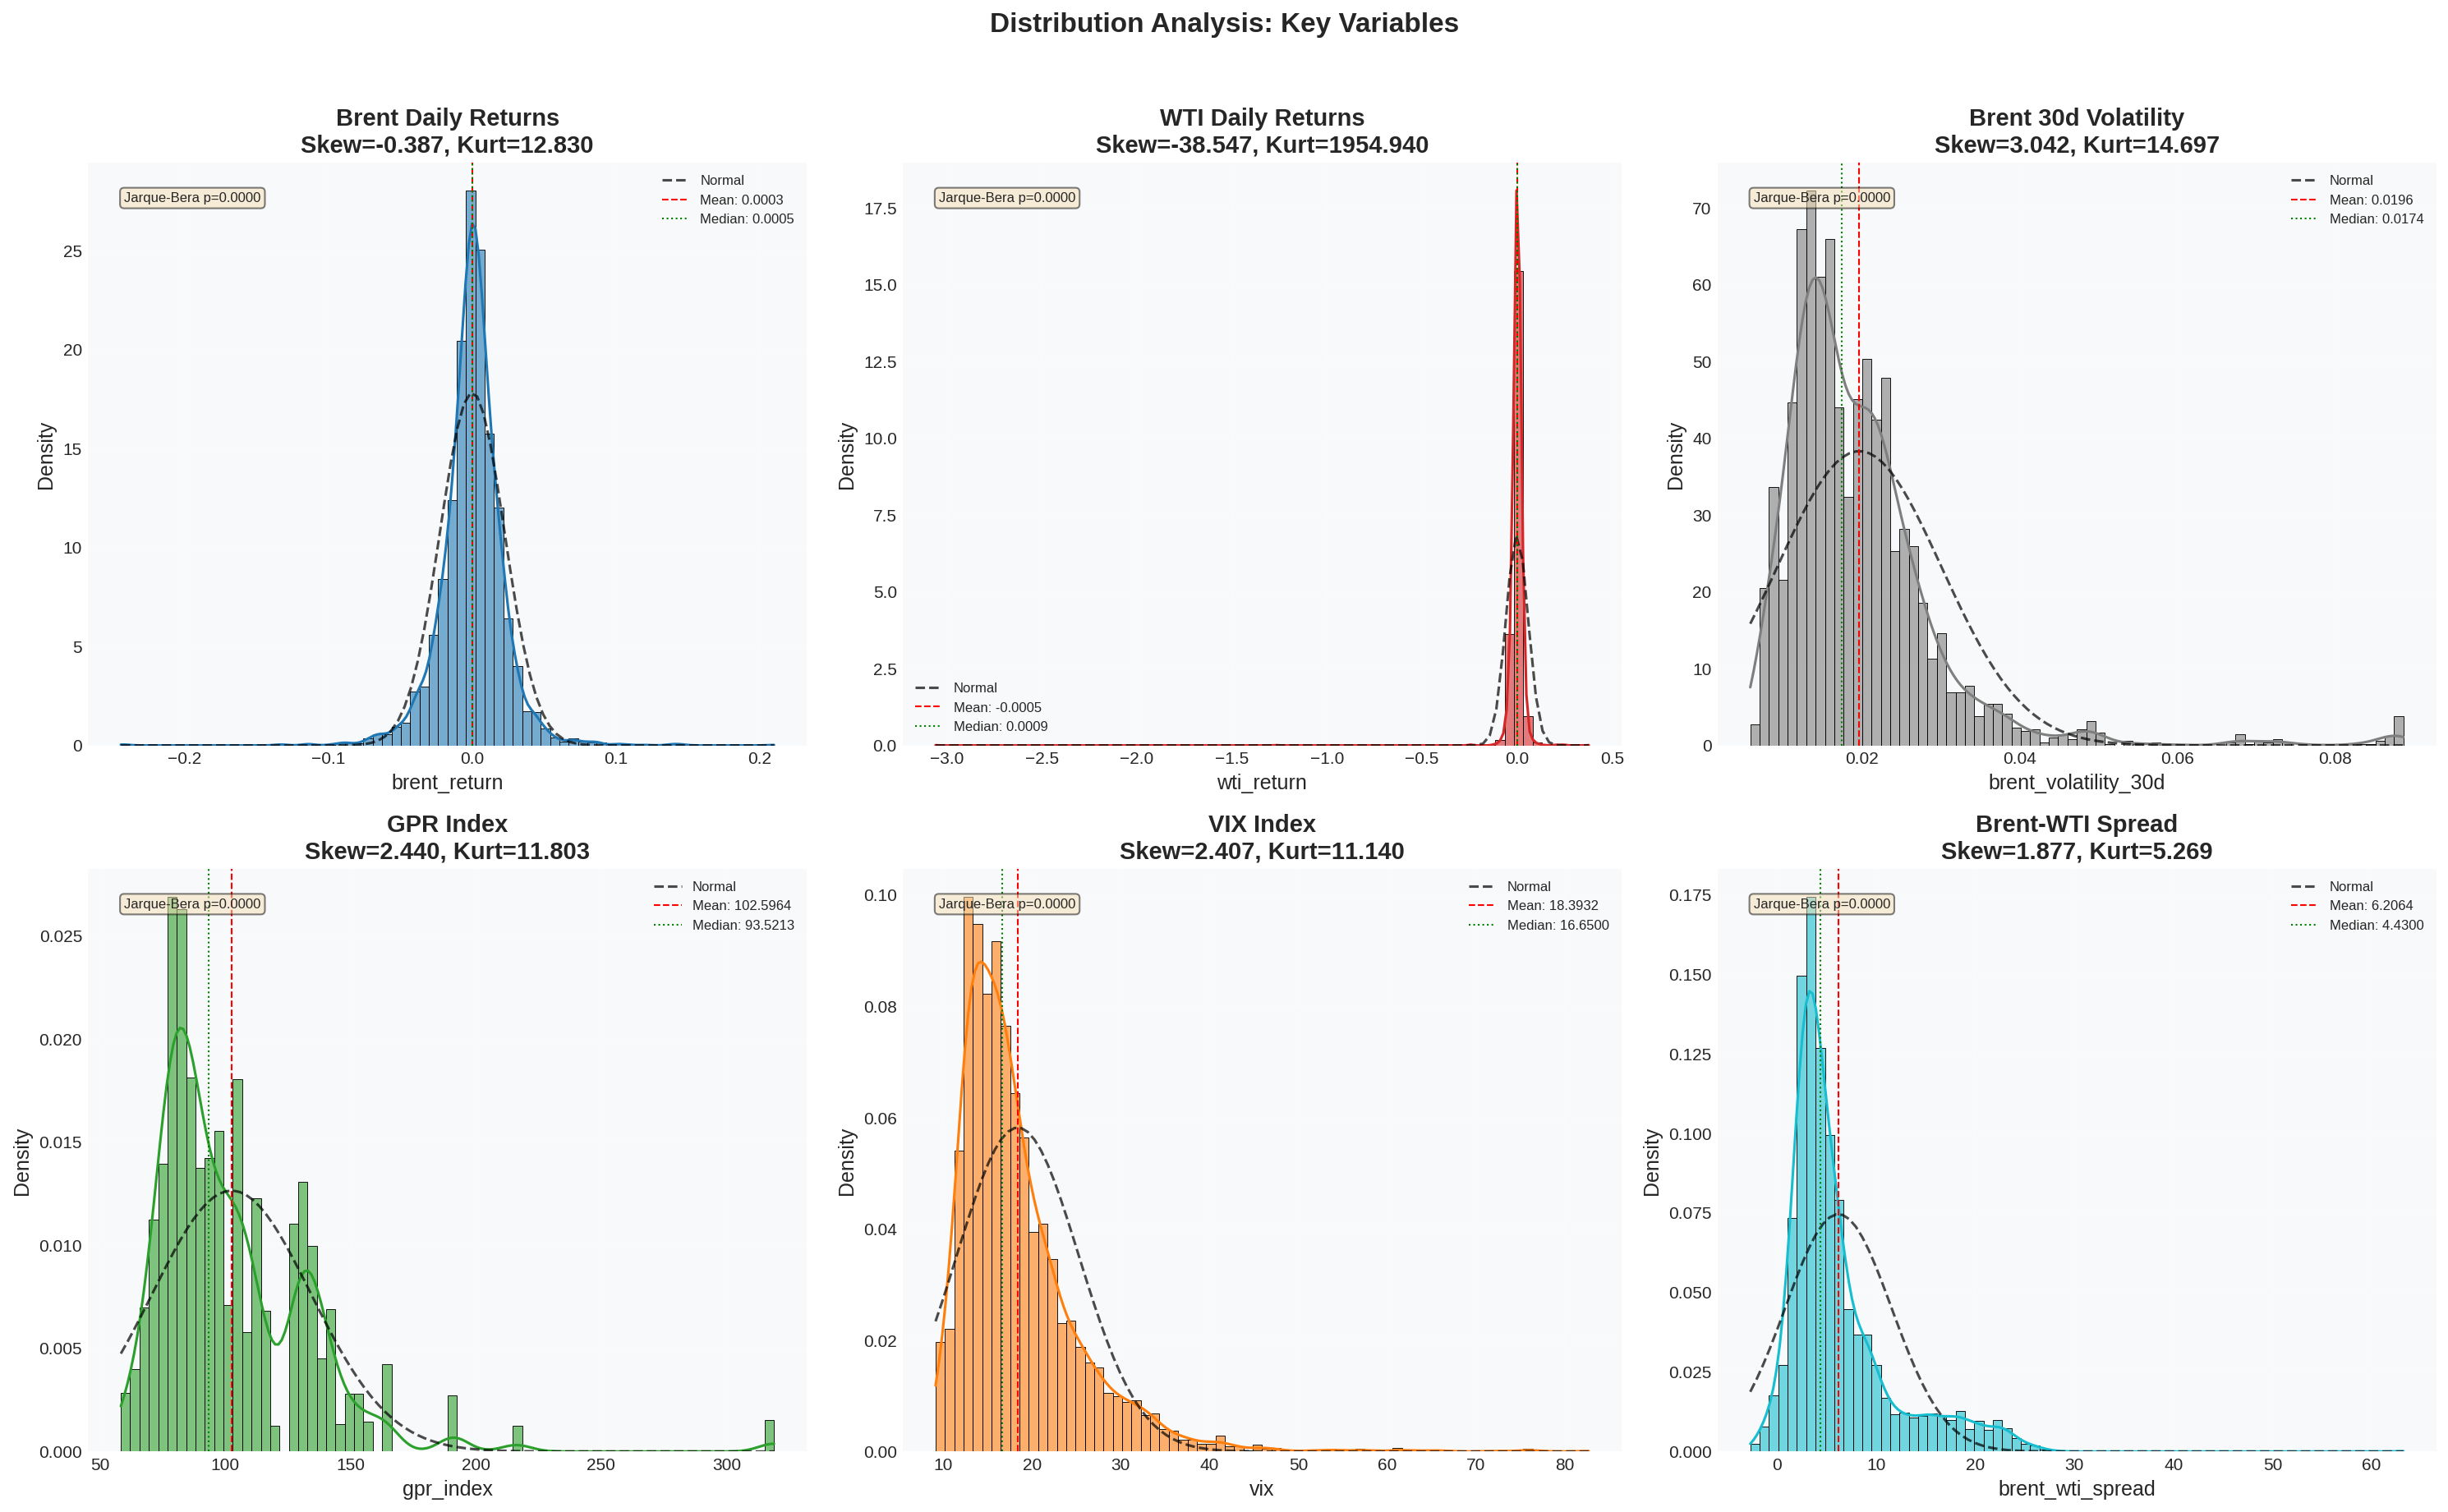

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

dist_vars = [
    ('brent_return', 'Brent Daily Returns', COLORS['brent']),
    ('wti_return', 'WTI Daily Returns', COLORS['wti']),
    ('brent_volatility_30d', 'Brent 30d Volatility', COLORS['volatility']),
    ('gpr_index', 'GPR Index', COLORS['gpr']),
    ('vix', 'VIX Index', COLORS['vix']),
    ('brent_wti_spread', 'Brent-WTI Spread', COLORS['spread'])
]

for idx, (col, title, color) in enumerate(dist_vars):
    ax = axes[idx]
    data = df[col].dropna()
    
    # Histogram with KDE
    sns.histplot(data, bins=70, kde=True, color=color, ax=ax, alpha=0.6, stat='density')
    
    # Add normal distribution for comparison
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'k--', linewidth=1.5, alpha=0.7, label='Normal')
    
    # Add statistics
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)
    jb_stat, jb_p = stats.jarque_bera(data)
    
    ax.axvline(mu, color='red', linestyle='--', linewidth=1, label=f'Mean: {mu:.4f}')
    ax.axvline(data.median(), color='green', linestyle=':', linewidth=1, label=f'Median: {data.median():.4f}')
    
    ax.set_title(f'{title}\nSkew={skew:.3f}, Kurt={kurt:.3f}', fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)
    
    # Add normality test result
    ax.text(0.05, 0.95, f'Jarque-Bera p={jb_p:.4f}', transform=ax.transAxes,
            fontsize=8, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Distribution Analysis: Key Variables', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## QQ plots for normality check

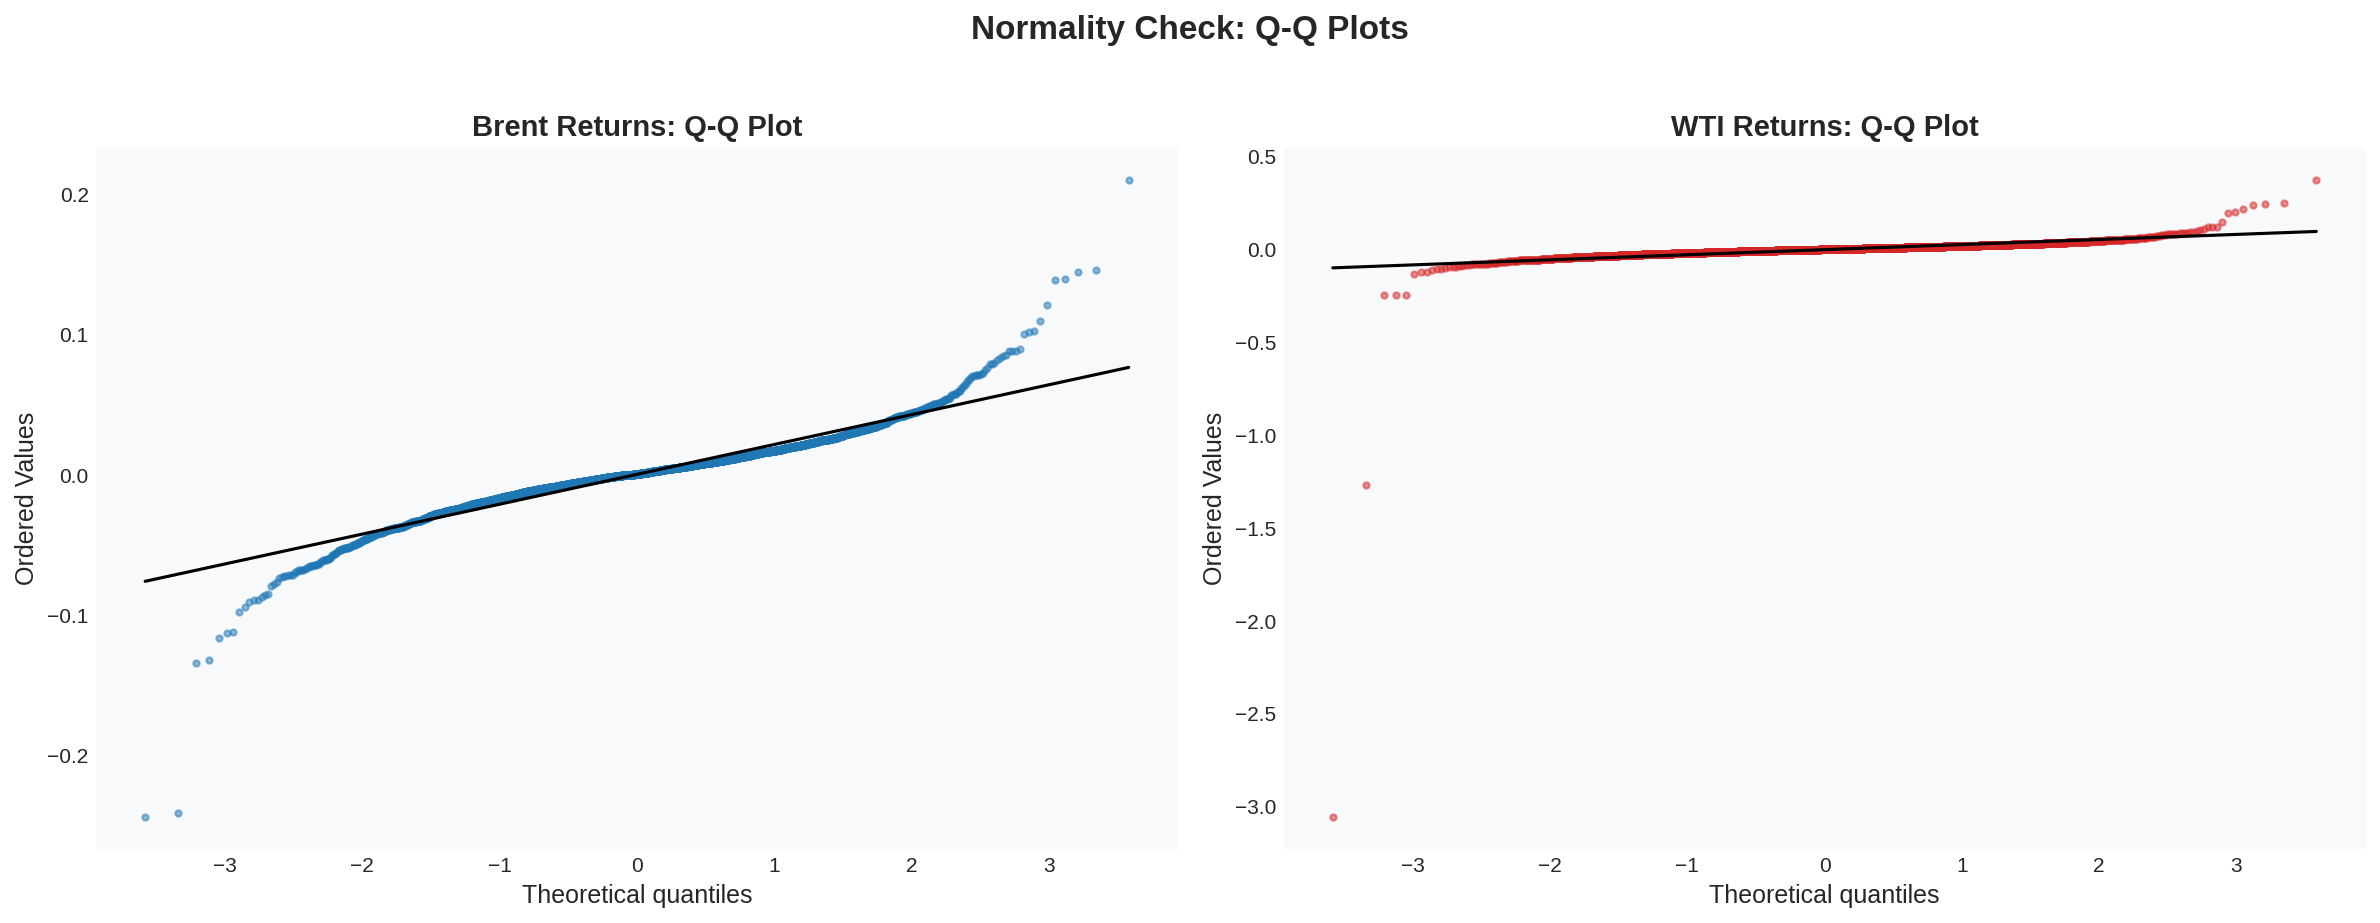

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, color, label in zip(axes, ['brent_return', 'wti_return'], 
                                  [COLORS['brent'], COLORS['wti']], ['Brent', 'WTI']):
    data = df[col].dropna()
    stats.probplot(data, dist="norm", plot=ax)
    ax.get_lines()[0].set_color(color)
    ax.get_lines()[0].set_alpha(0.5)
    ax.get_lines()[0].set_markersize(3)
    ax.get_lines()[1].set_color('black')
    ax.set_title(f'{label} Returns: Q-Q Plot', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.suptitle('Normality Check: Q-Q Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


#  TIME SERIES DECOMPOSITION & STATIONARITY


brent_price:
  ADF Statistic: -1.887281
  p-value: 0.338068
  Critical Values:
    1%: -3.432
    5%: -2.862
    10%: -2.567
  Stationary: No

brent_return:
  ADF Statistic: -12.942195
  p-value: 0.000000
  Critical Values:
    1%: -3.432
    5%: -2.862
    10%: -2.567
  Stationary: Yes


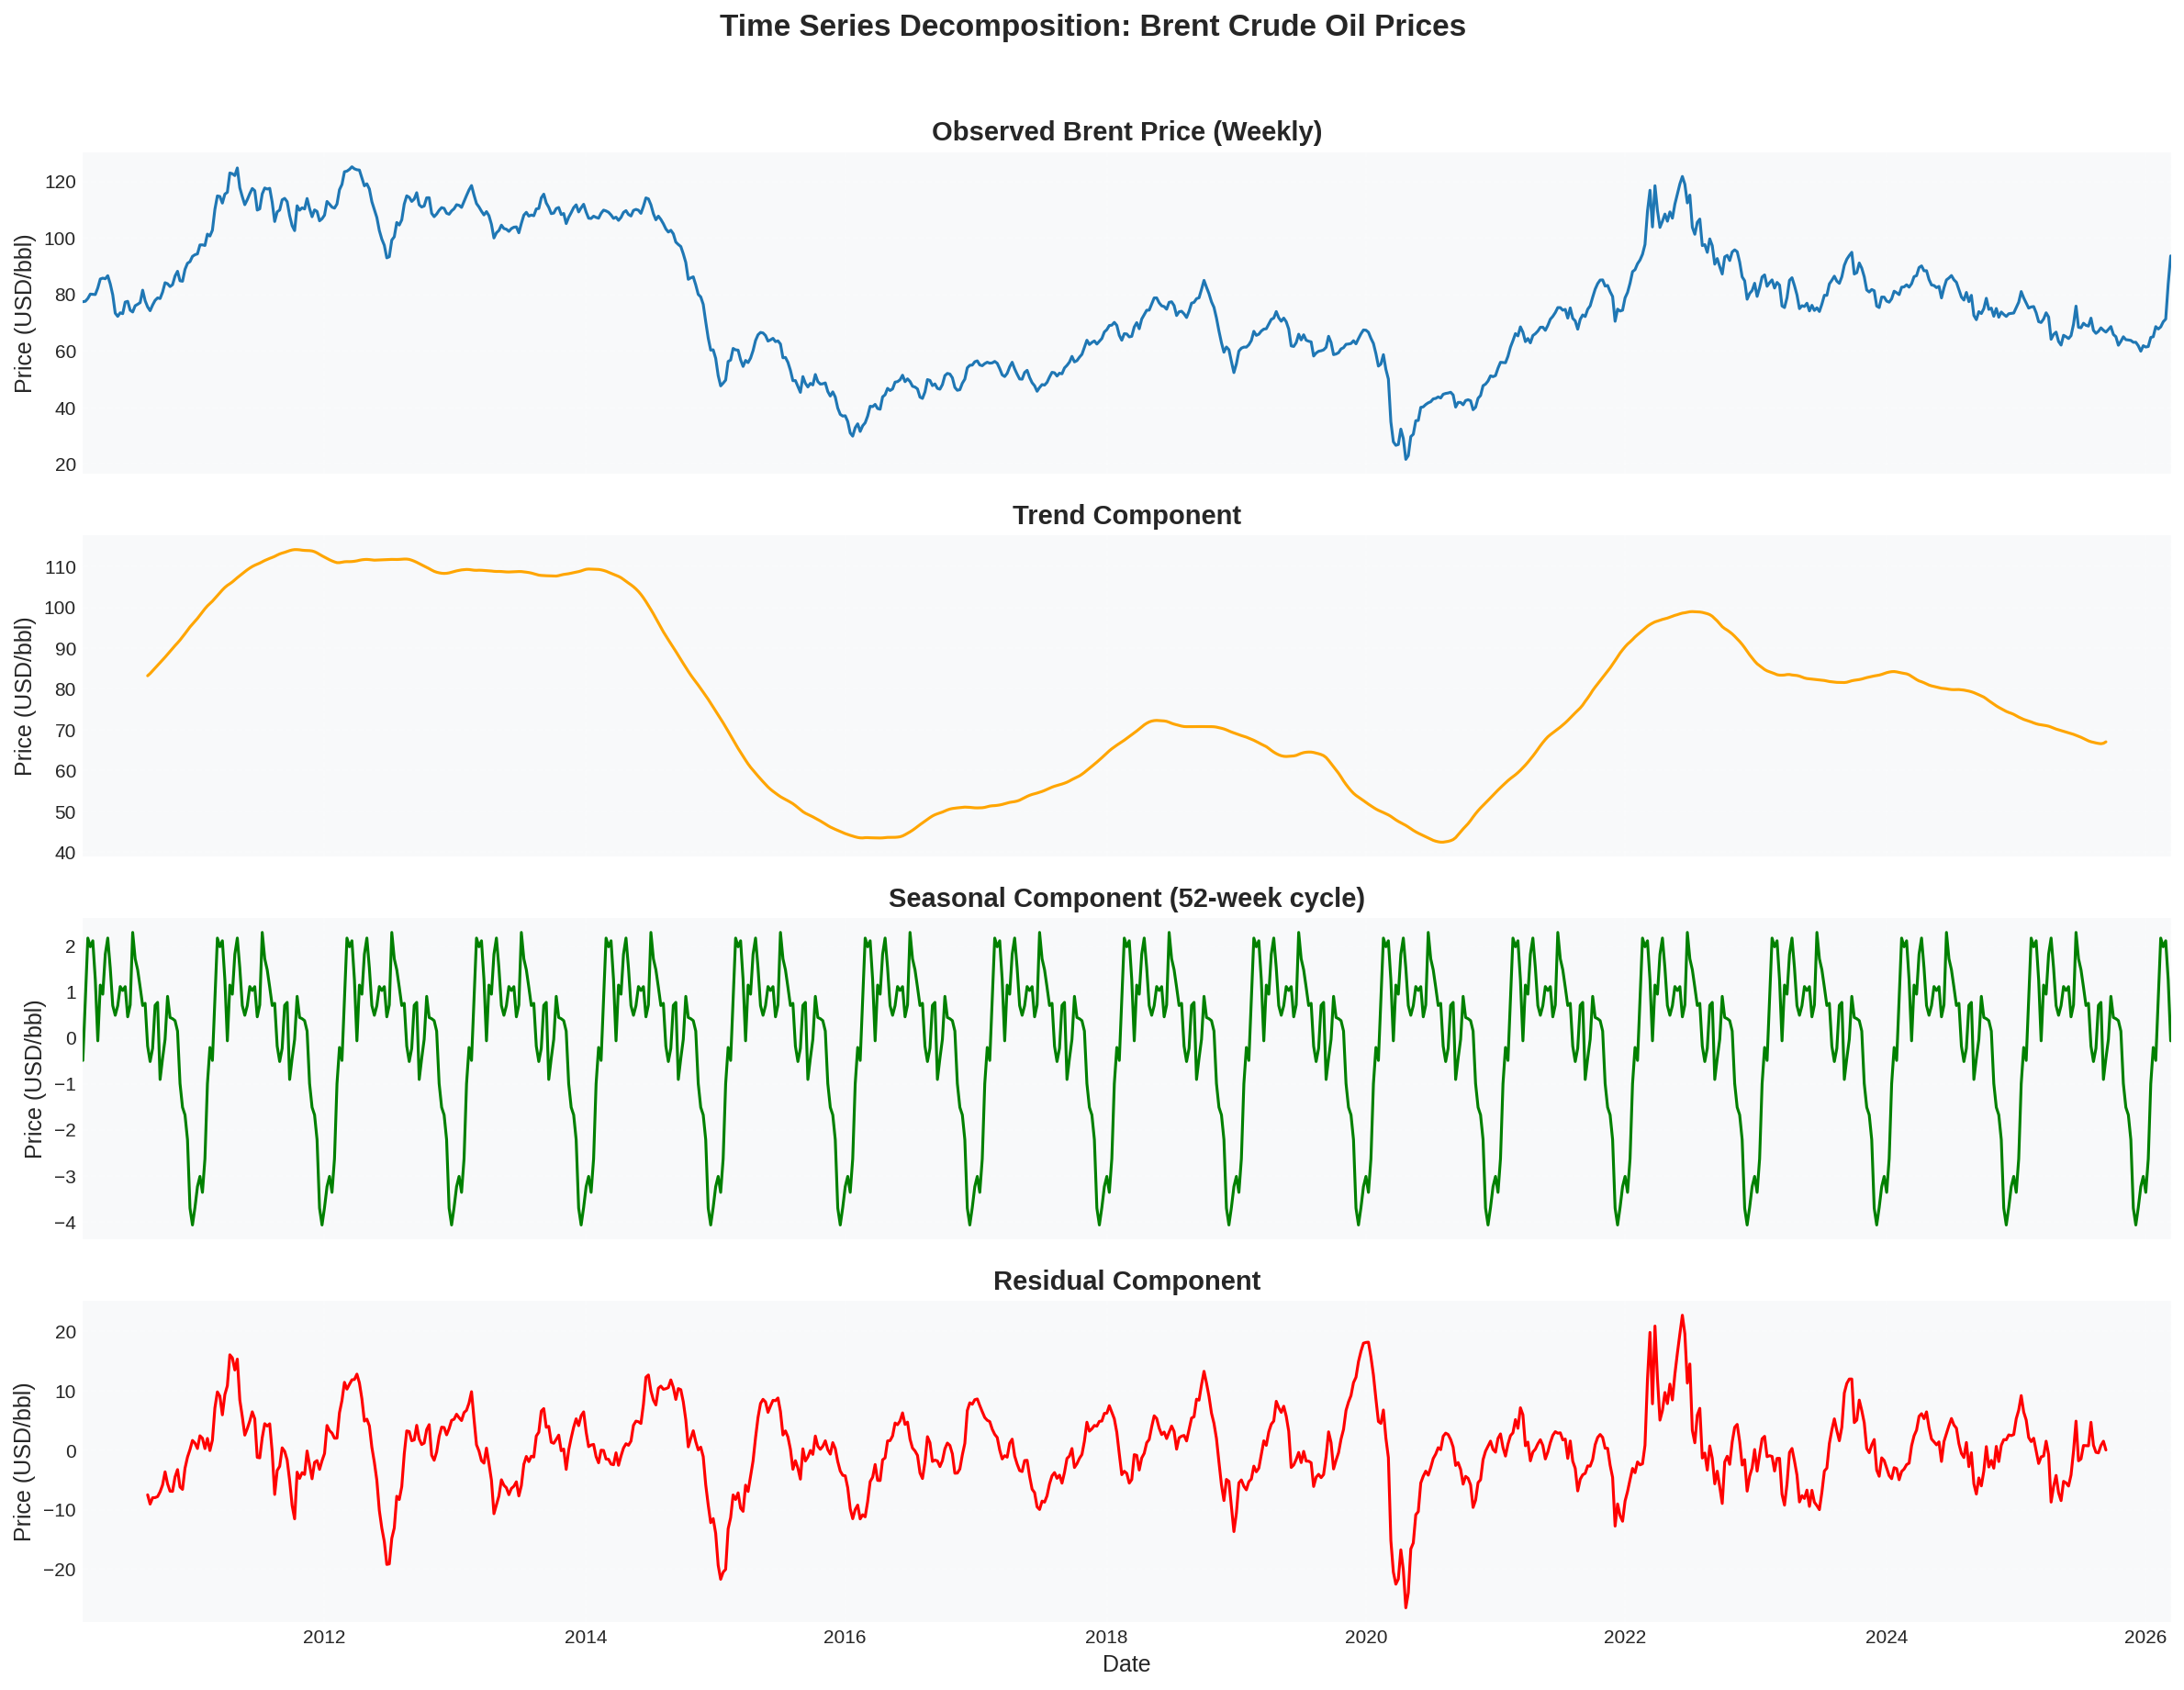

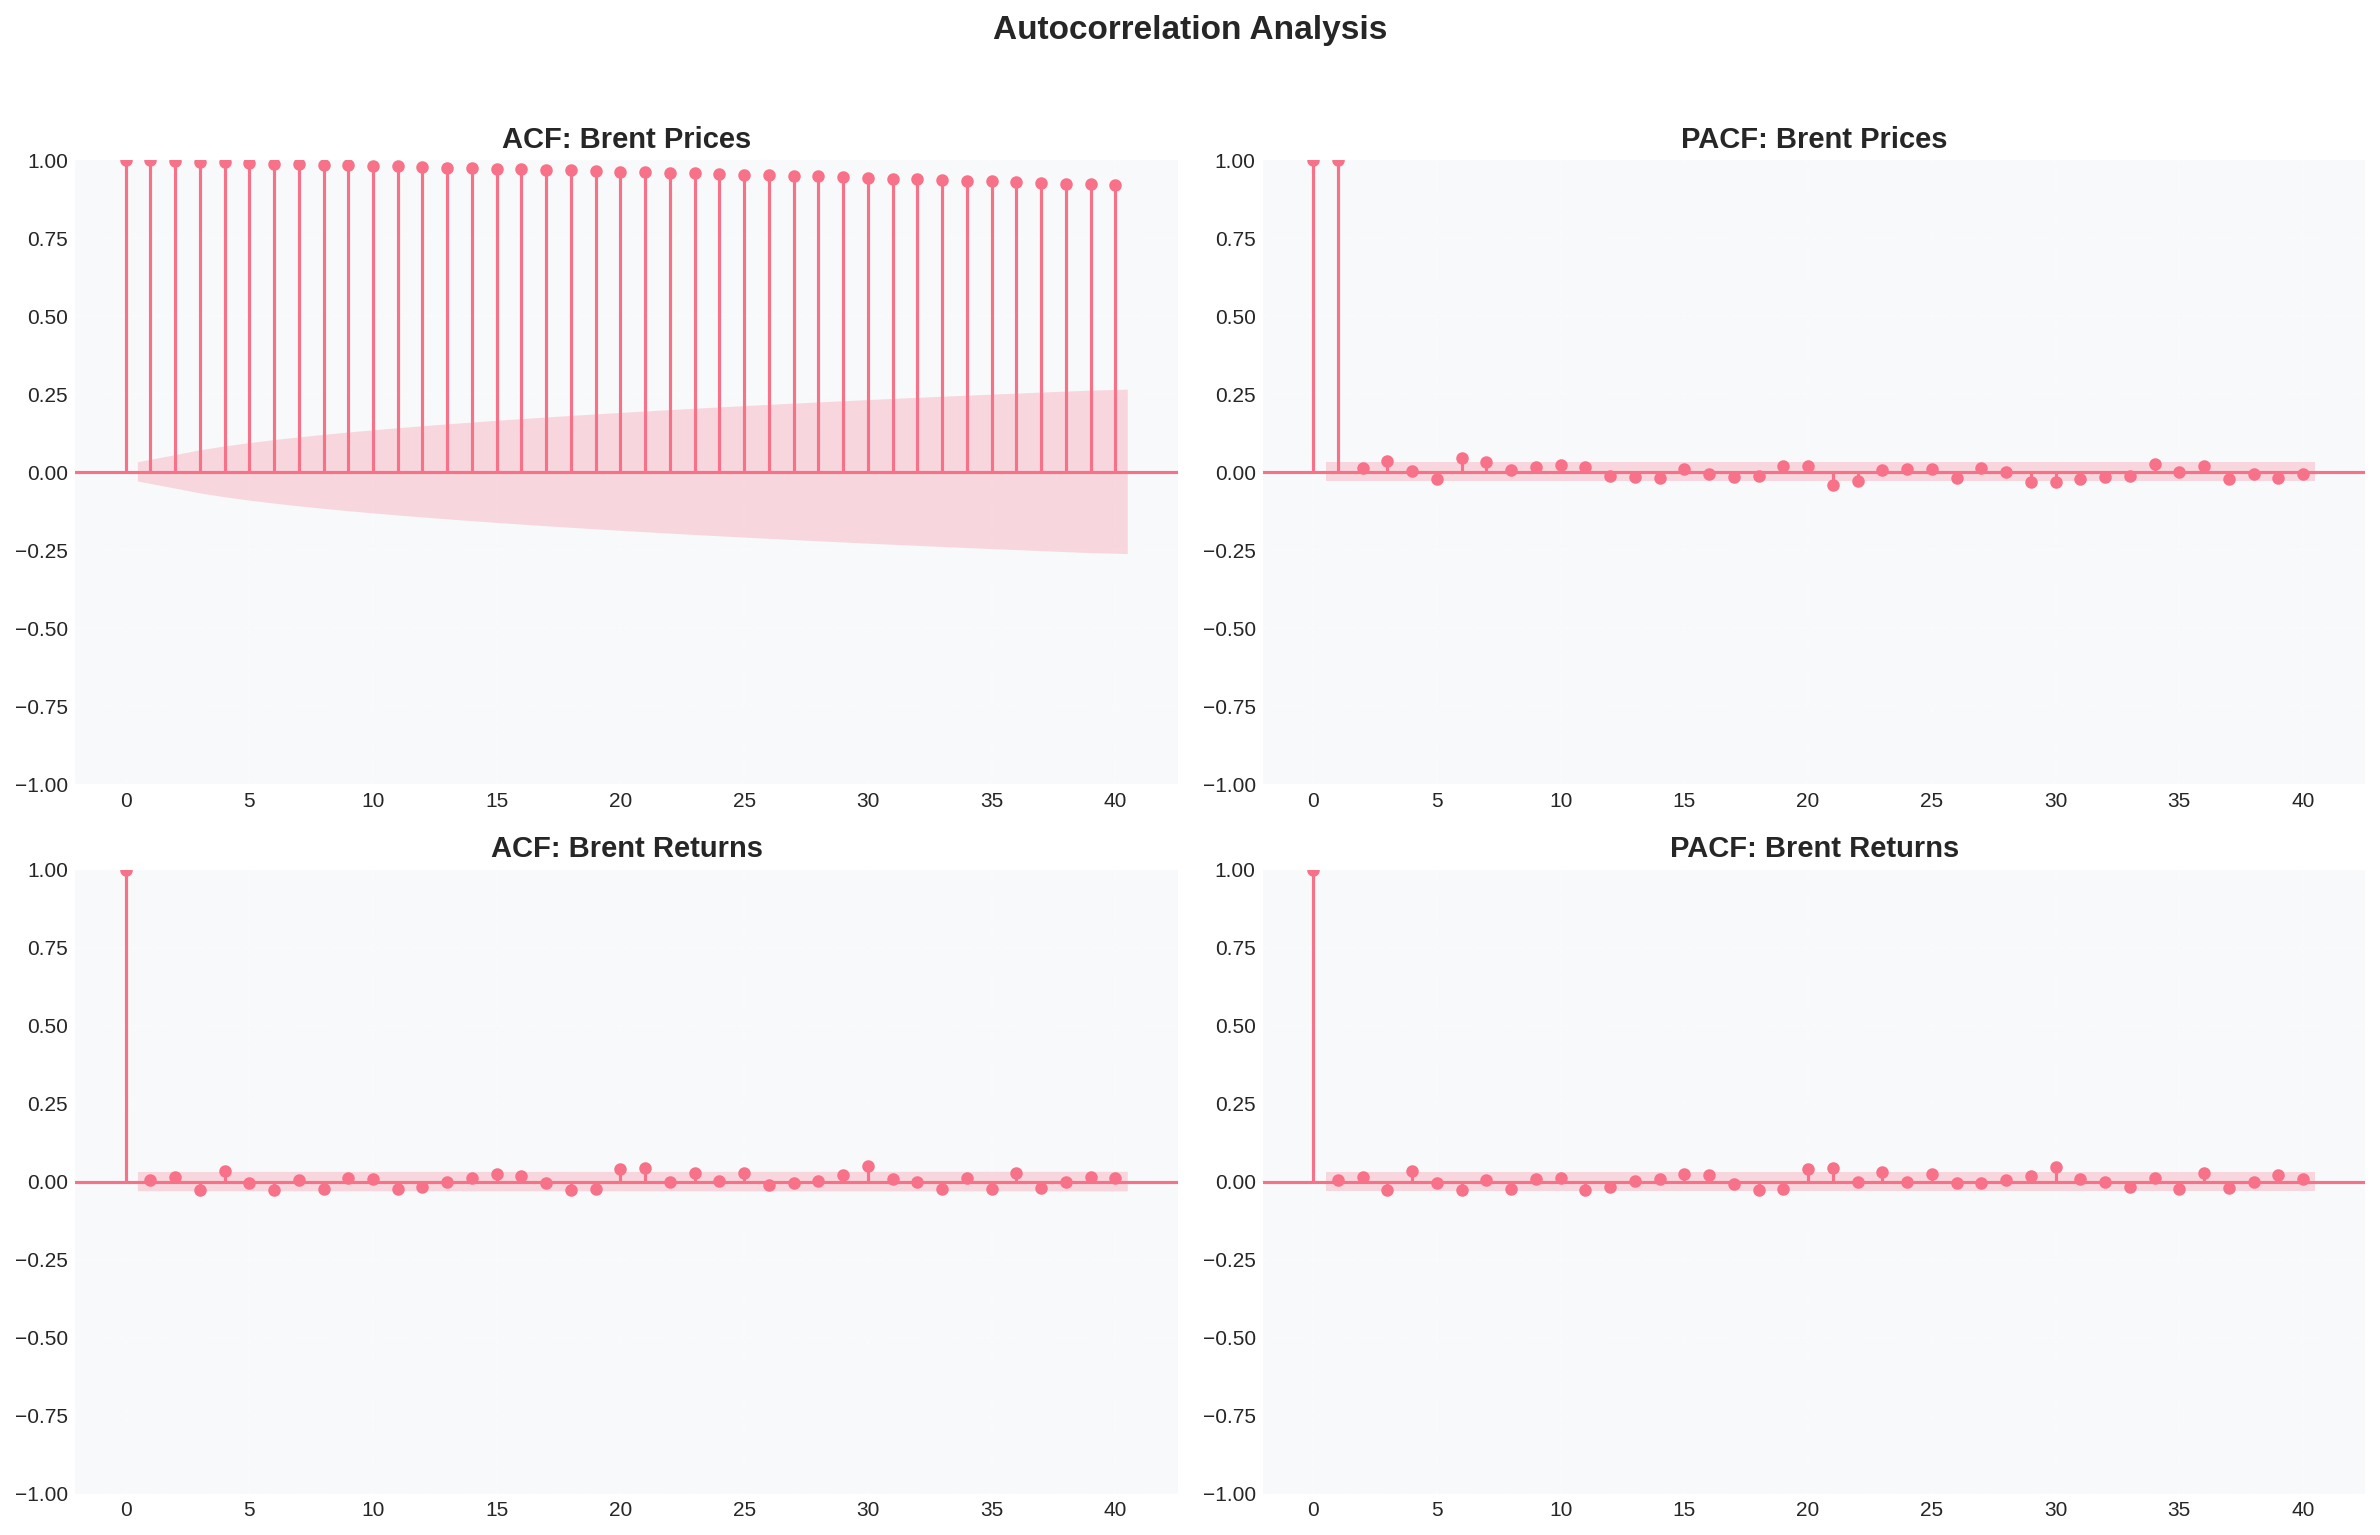

In [12]:


# Set date as index for time series analysis
ts_df = df.set_index('date')



for series_name in ['brent_price', 'brent_return']:
    series = ts_df[series_name].dropna()
    result = adfuller(series)
    print(f"\n{series_name}:")
    print(f"  ADF Statistic: {result[0]:.6f}")
    print(f"  p-value: {result[1]:.6f}")
    print(f"  Critical Values:")
    for key, value in result[4].items():
        print(f"    {key}: {value:.3f}")
    print(f"  Stationary: {'Yes' if result[1] < 0.05 else 'No'}")

# Seasonal decomposition (if we have enough data)
if len(ts_df) >= 365:
    from statsmodels.tsa.seasonal import seasonal_decompose
    
    # Resample to weekly for clearer pattern
    weekly_prices = ts_df['brent_price'].resample('W').mean().dropna()
    
    # Decompose (using additive model)
    decomposition = seasonal_decompose(weekly_prices, model='additive', period=52)
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    
    decomposition.observed.plot(ax=axes[0], color=COLORS['brent'])
    axes[0].set_title('Observed Brent Price (Weekly)', fontweight='bold')
    axes[0].set_ylabel('Price (USD/bbl)')
    
    decomposition.trend.plot(ax=axes[1], color='orange')
    axes[1].set_title('Trend Component', fontweight='bold')
    axes[1].set_ylabel('Price (USD/bbl)')
    
    decomposition.seasonal.plot(ax=axes[2], color='green')
    axes[2].set_title('Seasonal Component (52-week cycle)', fontweight='bold')
    axes[2].set_ylabel('Price (USD/bbl)')
    
    decomposition.resid.plot(ax=axes[3], color='red')
    axes[3].set_title('Residual Component', fontweight='bold')
    axes[3].set_ylabel('Price (USD/bbl)')
    axes[3].set_xlabel('Date')
    
    plt.suptitle('Time Series Decomposition: Brent Crude Oil Prices', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# ACF and PACF plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ACF/PACF for Brent prices
plot_acf(ts_df['brent_price'].dropna(), lags=40, ax=axes[0, 0])
axes[0, 0].set_title('ACF: Brent Prices', fontweight='bold')

plot_pacf(ts_df['brent_price'].dropna(), lags=40, ax=axes[0, 1])
axes[0, 1].set_title('PACF: Brent Prices', fontweight='bold')

# ACF/PACF for Brent returns
plot_acf(ts_df['brent_return'].dropna(), lags=40, ax=axes[1, 0])
axes[1, 0].set_title('ACF: Brent Returns', fontweight='bold')

plot_pacf(ts_df['brent_return'].dropna(), lags=40, ax=axes[1, 1])
axes[1, 1].set_title('PACF: Brent Returns', fontweight='bold')

plt.suptitle('Autocorrelation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

#  EVENT IMPACT ANALYSIS


Event Statistics:
  Total event days: 4,047
  Event frequency: 100.00%
  Unique event types: 13

Event Type Distribution:
event_type
none                 4022
sanctions               6
conflict                4
opec                    3
war                     3
blockade                2
disaster                1
annexation              1
diplomatic_crisis       1
market_crash            1
blockage                1
energy_crisis           1
market_shift            1

Return Comparison (Event vs Non-Event):
  Event days mean: +0.000311
  Non-event days mean: +nan
  T-test statistic: nan
  P-value: nan
  Significant at 95%: No


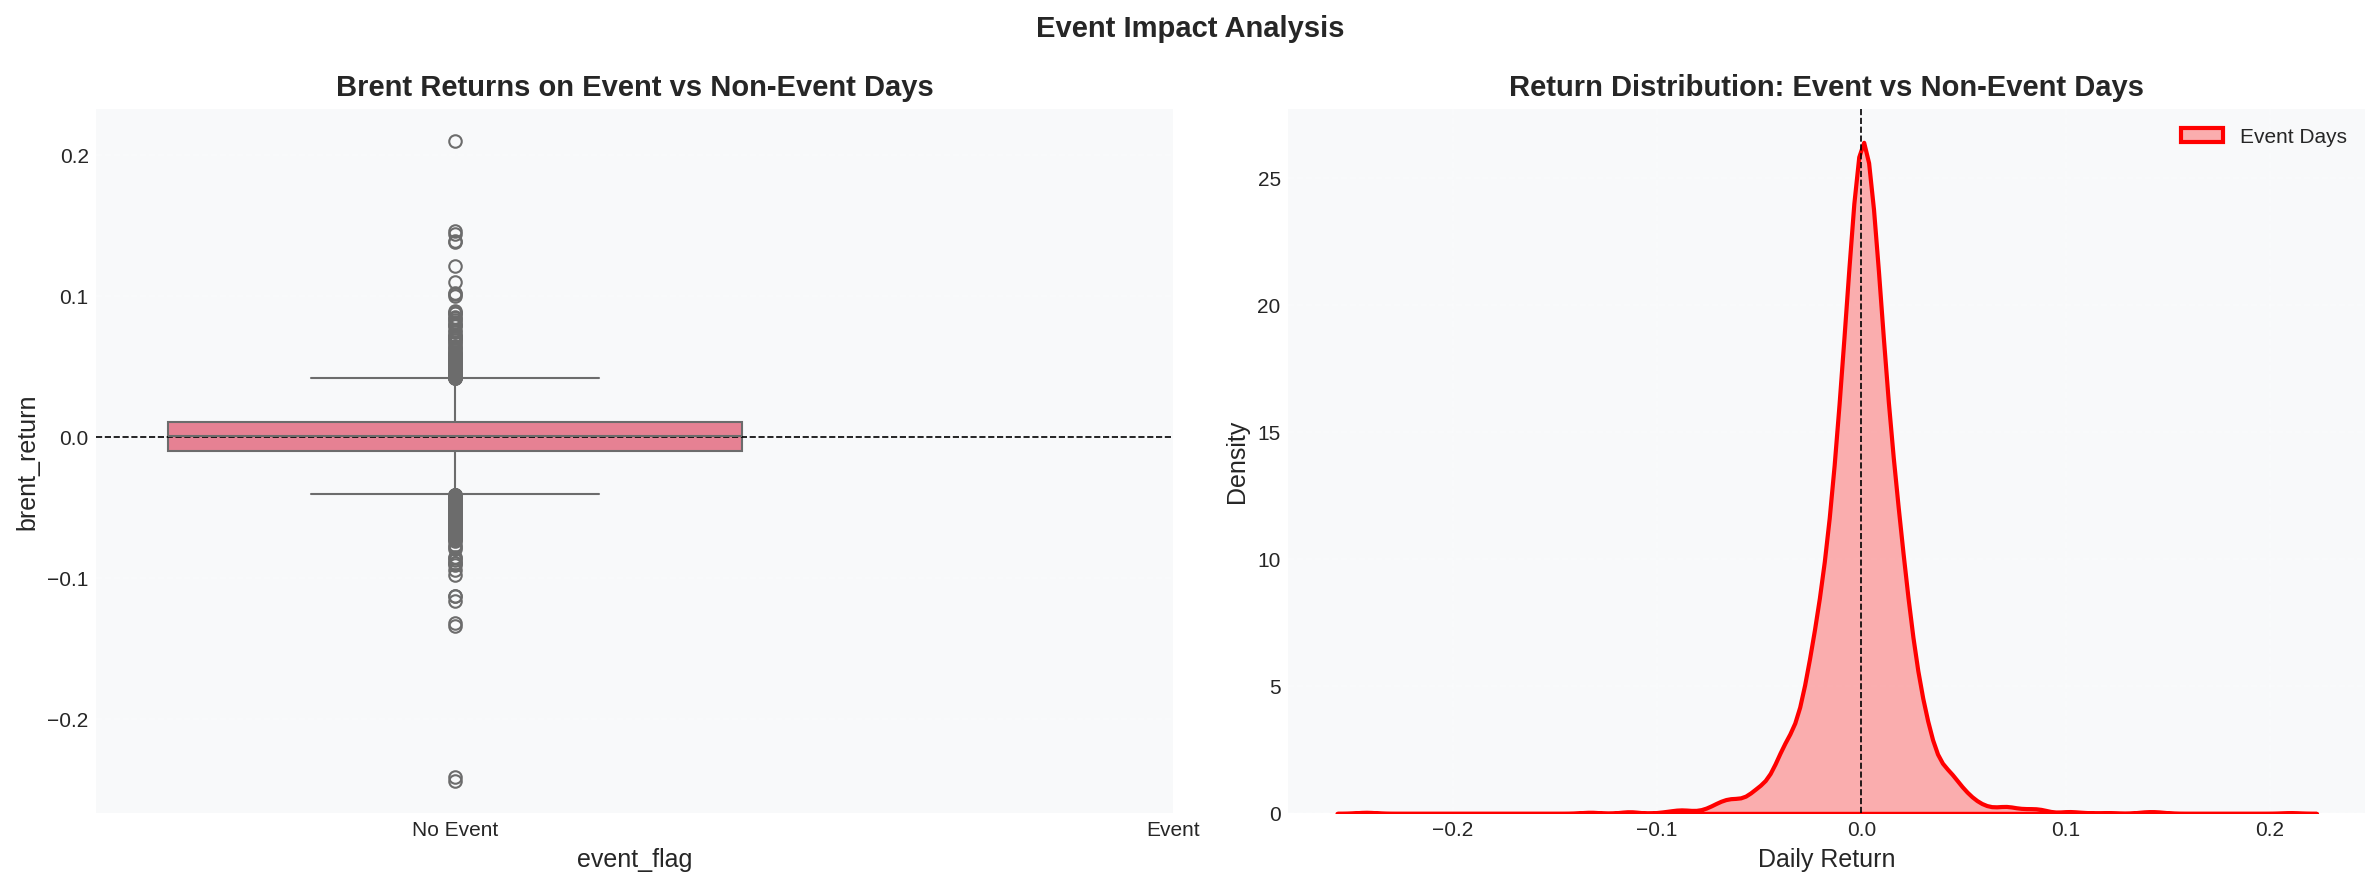

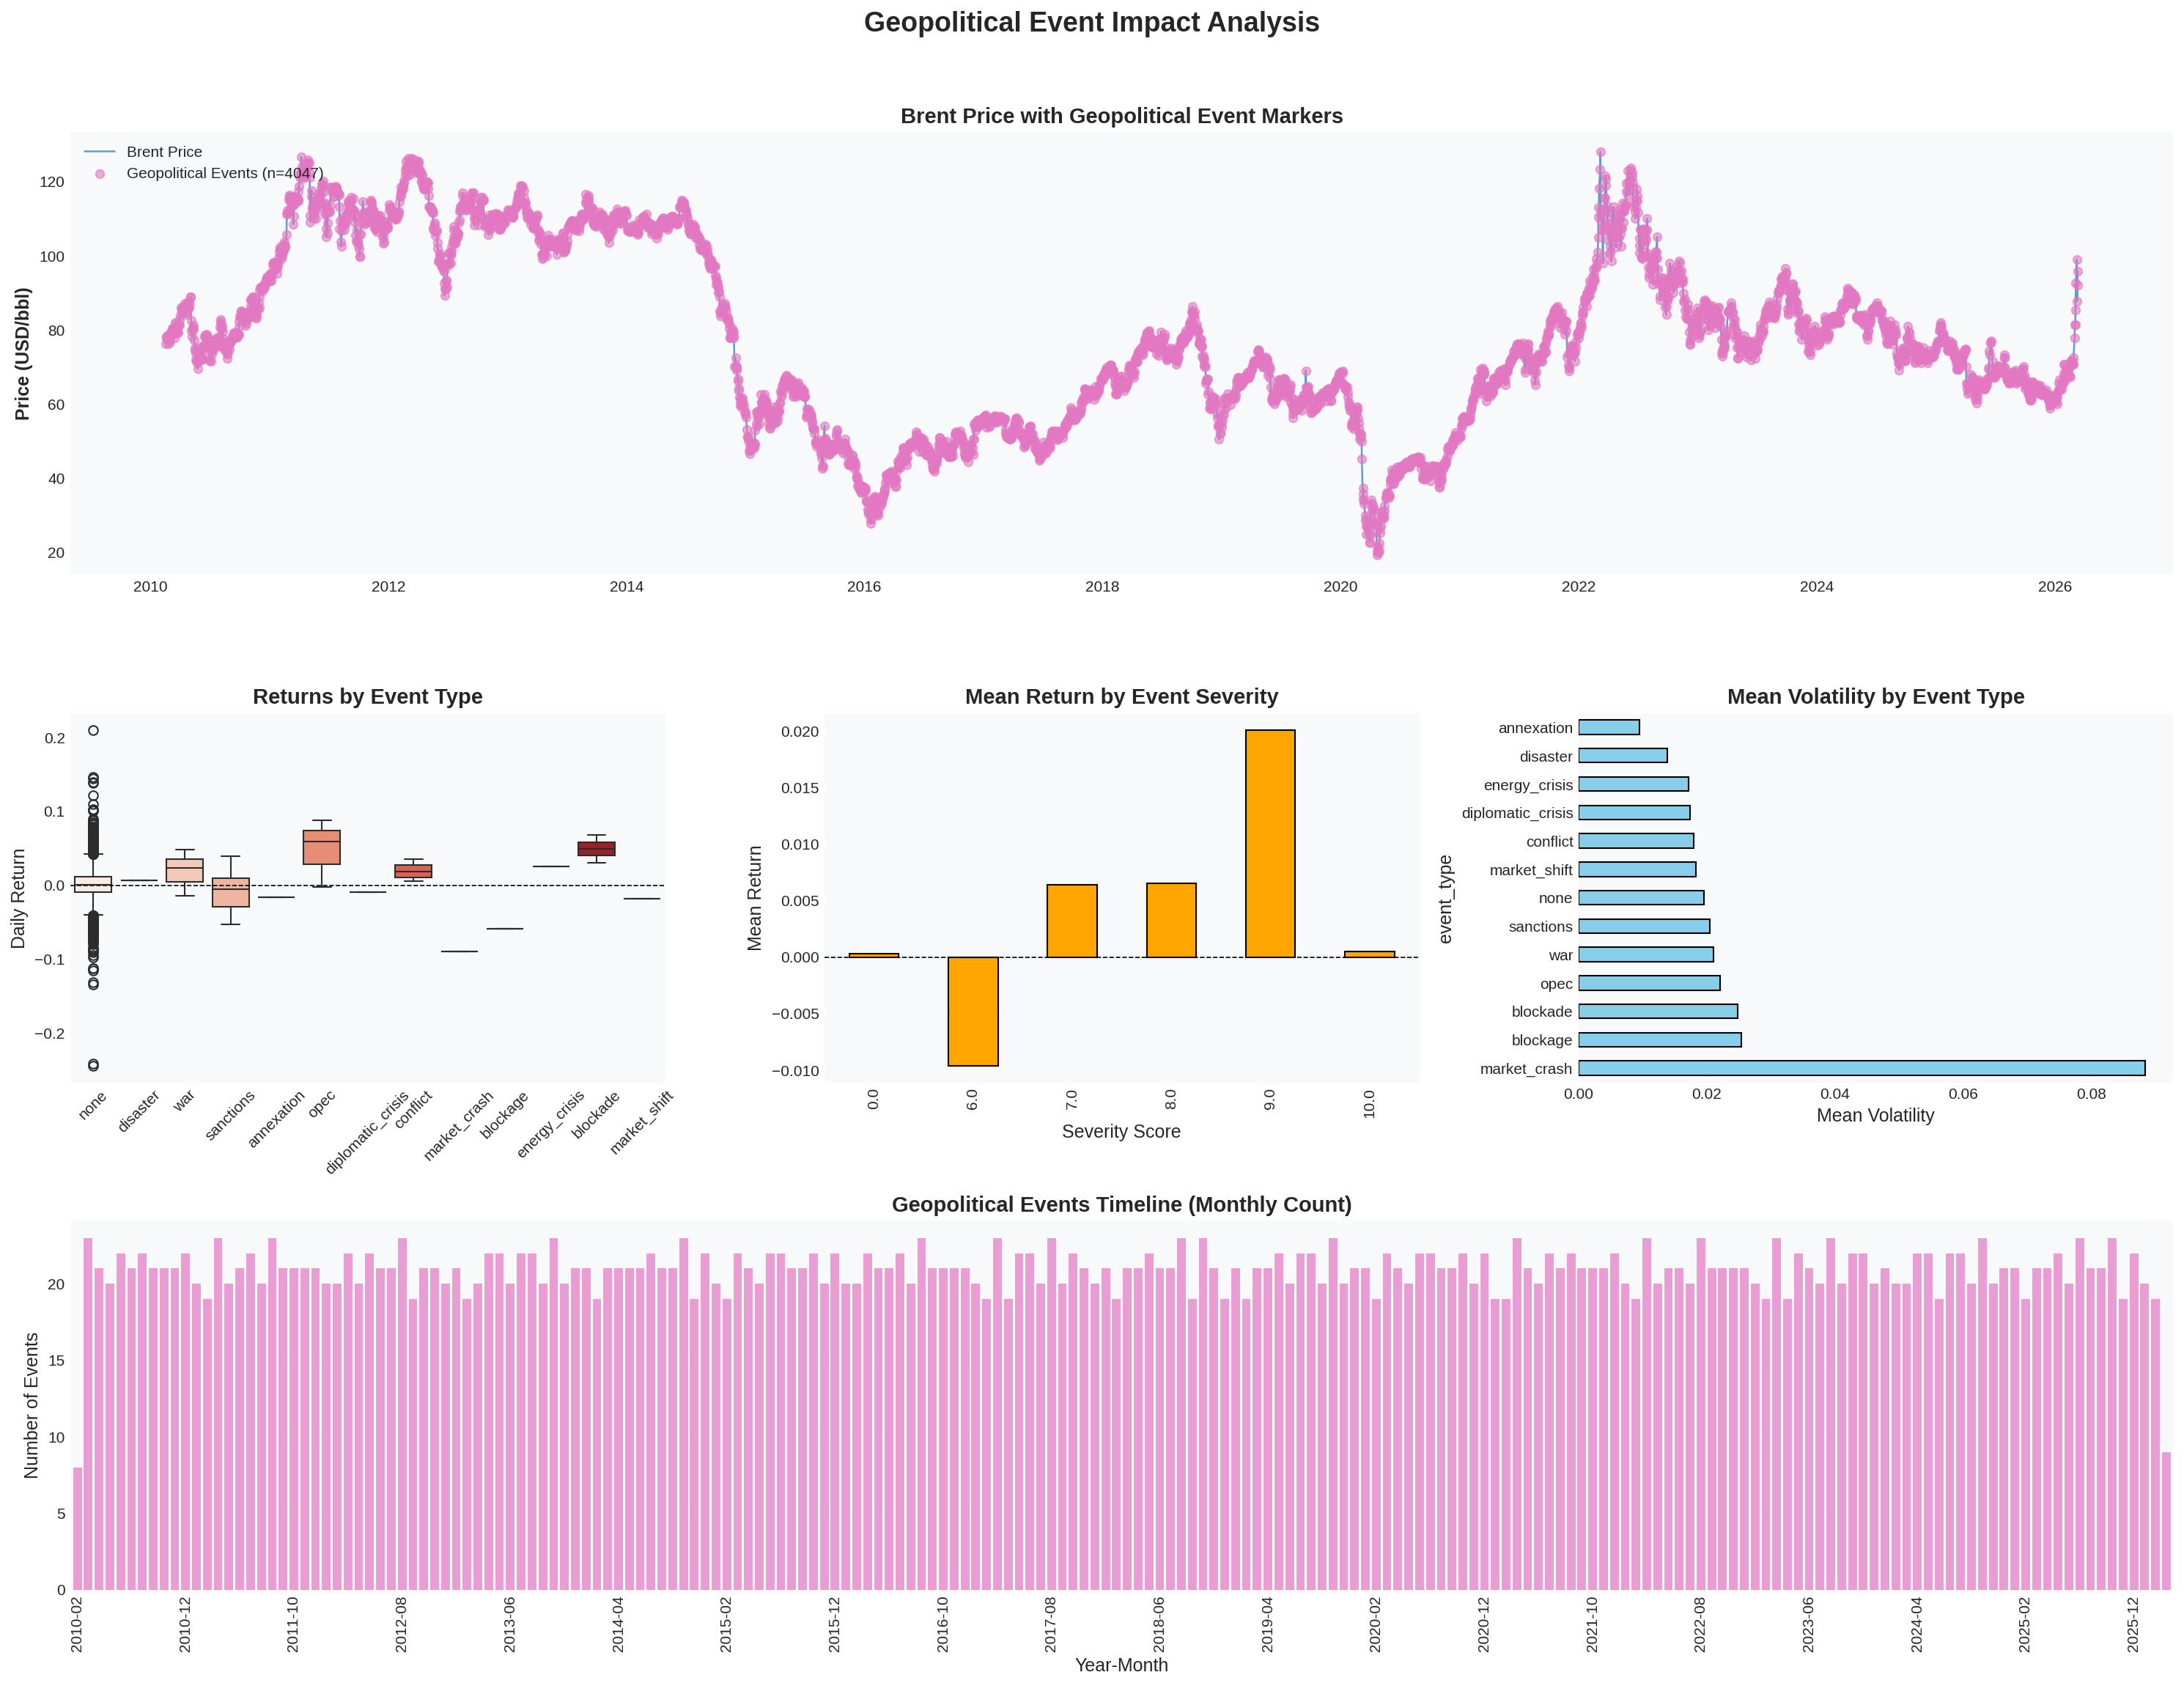

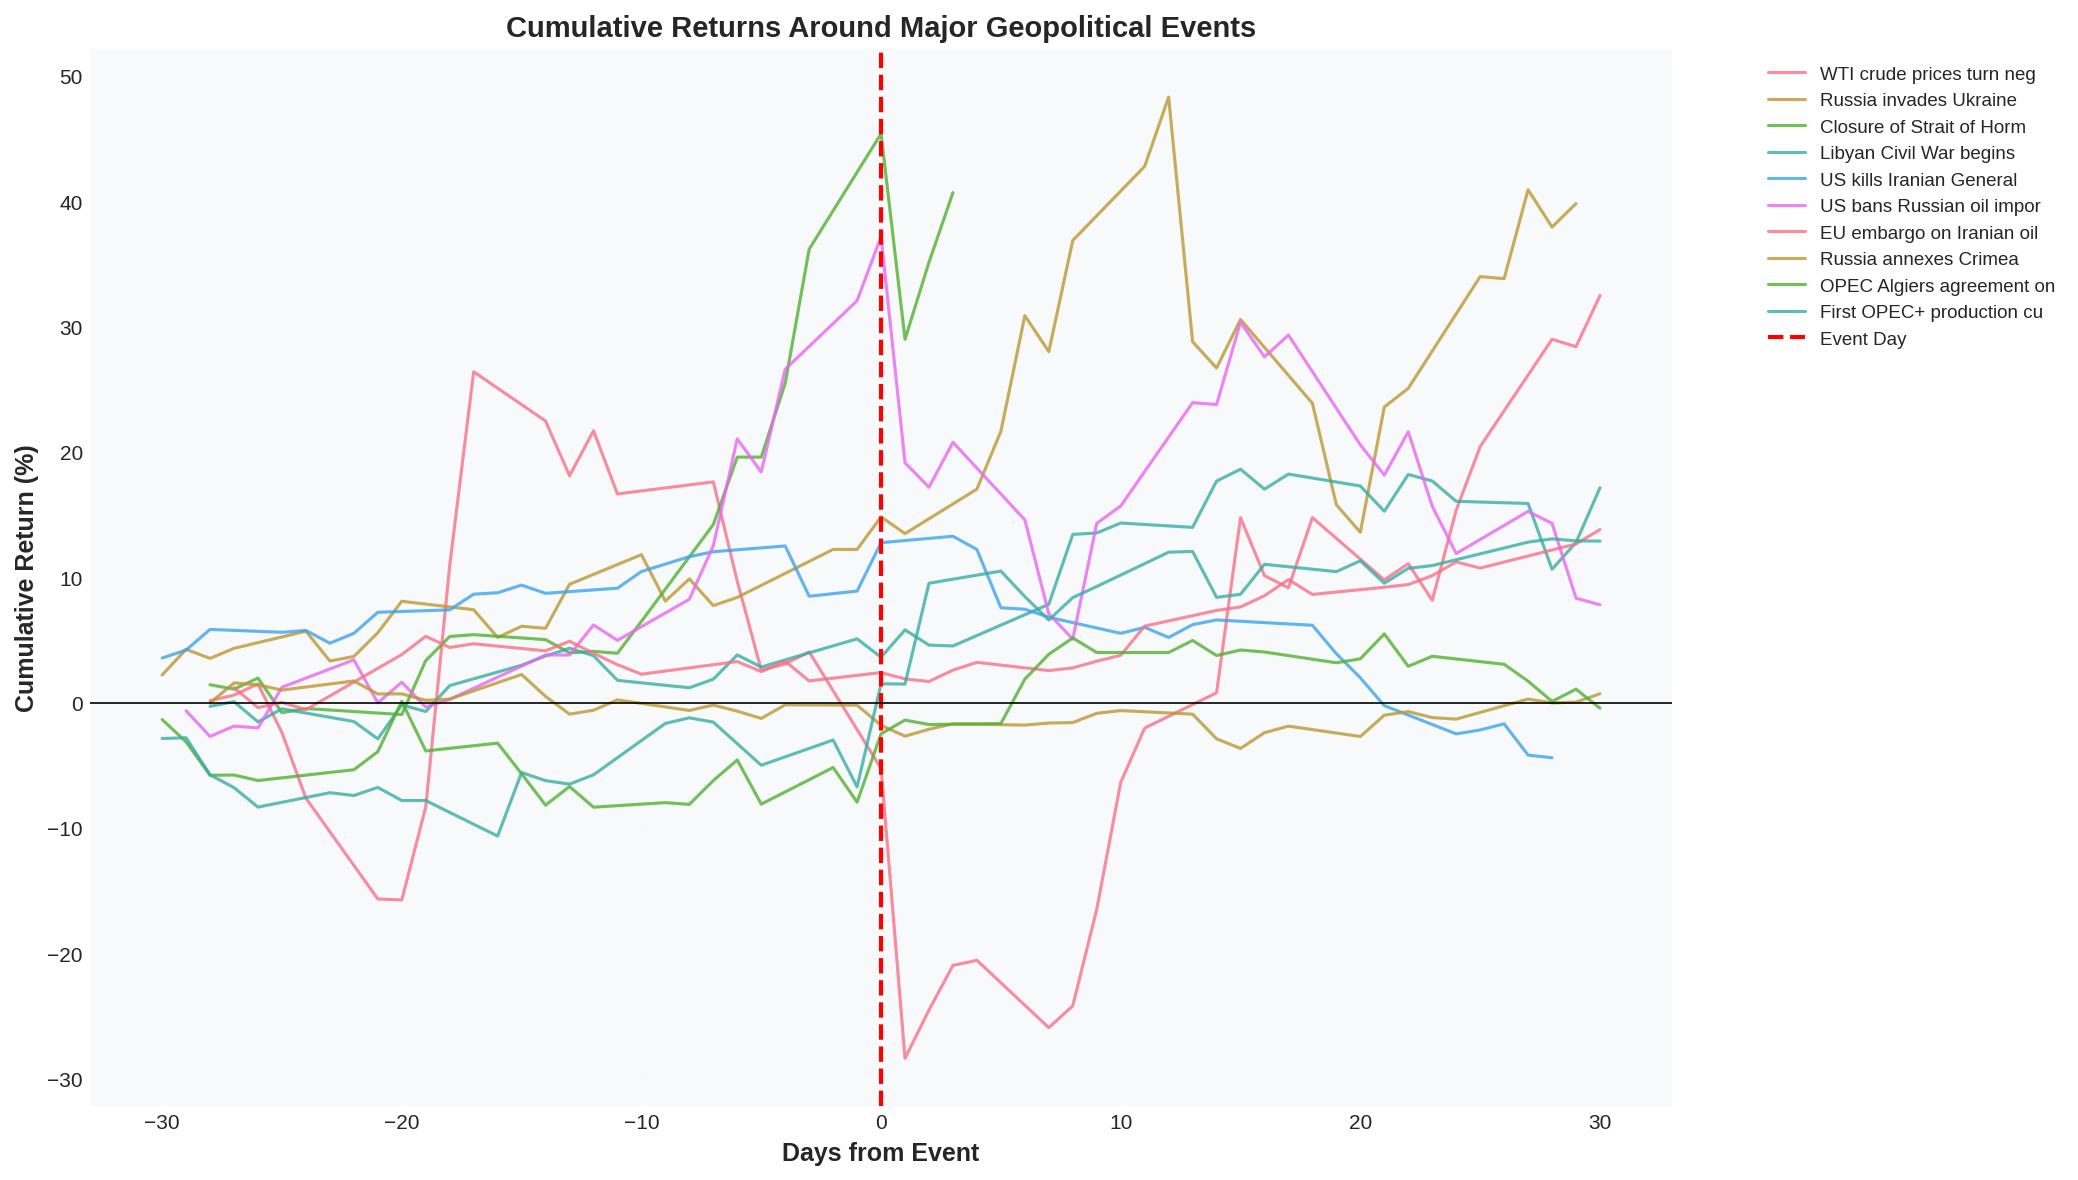


Average price change 5 days after events: $0.01


In [13]:

# Separate event and non-event days
events_df = df[df['event_flag'] == 1].copy()
non_events_df = df[df['event_flag'] == 0].copy()

print(f"\nEvent Statistics:")
print(f"  Total event days: {len(events_df):,}")
print(f"  Event frequency: {len(events_df)/len(df)*100:.2f}%")
print(f"  Unique event types: {events_df['event_type'].nunique()}")

print("\nEvent Type Distribution:")
print(events_df['event_type'].value_counts().to_string())

# Statistical comparison of returns
ev_returns = events_df['brent_return'].dropna()
nev_returns = non_events_df['brent_return'].dropna()

t_stat, p_val = stats.ttest_ind(ev_returns, nev_returns)
print(f"\nReturn Comparison (Event vs Non-Event):")
print(f"  Event days mean: {ev_returns.mean():+.6f}")
print(f"  Non-event days mean: {nev_returns.mean():+.6f}")
print(f"  T-test statistic: {t_stat:.4f}")
print(f"  P-value: {p_val:.6f}")
print(f"  Significant at 95%: {'Yes' if p_val < 0.05 else 'No'}")

# Box plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot
sns.boxplot(x="event_flag", y="brent_return", data=df, ax=axes[0])
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(["No Event","Event"])
axes[0].set_title('Brent Returns on Event vs Non-Event Days', fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# KDE plot
sns.kdeplot(nev_returns, ax=axes[1], color='blue', fill=True, alpha=0.3, label='Non-Event Days', linewidth=2)
sns.kdeplot(ev_returns, ax=axes[1], color='red', fill=True, alpha=0.3, label='Event Days', linewidth=2)
axes[1].set_title('Return Distribution: Event vs Non-Event Days', fontweight='bold')
axes[1].set_xlabel('Daily Return')
axes[1].legend()
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')

plt.suptitle('Event Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Advanced event impact visualization
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(3, 3, height_ratios=[1.2, 1, 1])

#  Price with event markers
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df['date'], df['brent_price'], color=COLORS['brent'], linewidth=1.2, alpha=0.7, label='Brent Price')
ax1.scatter(events_df['date'], events_df['brent_price'], 
           color=COLORS['event'], s=30, alpha=0.6, zorder=5, 
           label=f'Geopolitical Events (n={len(events_df)})')
ax1.set_ylabel('Price (USD/bbl)', fontweight='bold')
ax1.set_title('Brent Price with Geopolitical Event Markers', fontweight='bold', fontsize=14)
ax1.legend(loc='upper left')
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.grid(True, alpha=0.3)

#  Box plot: Returns by event type
ax2 = fig.add_subplot(gs[1, 0])
event_returns = events_df[['event_type', 'brent_return']].dropna()
sns.boxplot(data=event_returns, x='event_type', y='brent_return', ax=ax2, palette='Reds')
ax2.set_title('Returns by Event Type', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Daily Return')
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')

#  Severity impact
ax3 = fig.add_subplot(gs[1, 1])
severity_impact = events_df.groupby('event_severity').agg({
    'brent_return': ['mean', 'std'],
    'brent_volatility_30d': 'mean'
}).round(4)

severity_impact[('brent_return', 'mean')].plot(kind='bar', ax=ax3, color='orange', edgecolor='black')
ax3.set_title('Mean Return by Event Severity', fontweight='bold')
ax3.set_xlabel('Severity Score')
ax3.set_ylabel('Mean Return')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')

#  Volatility by event type
ax4 = fig.add_subplot(gs[1, 2])
type_vol = events_df.groupby('event_type')['brent_volatility_30d'].mean().sort_values(ascending=False)
type_vol.plot(kind='barh', ax=ax4, color='skyblue', edgecolor='black')
ax4.set_title('Mean Volatility by Event Type', fontweight='bold')
ax4.set_xlabel('Mean Volatility')

#  Event timeline
ax5 = fig.add_subplot(gs[2, :])
event_timeline = events_df.groupby(events_df['date'].dt.to_period('M')).size()
event_timeline.plot(kind='bar', ax=ax5, color=COLORS['event'], alpha=0.7, width=0.8)
ax5.set_title('Geopolitical Events Timeline (Monthly Count)', fontweight='bold')
ax5.set_xlabel('Year-Month')
ax5.set_ylabel('Number of Events')
ax5.tick_params(axis='x', rotation=90)
ax5.xaxis.set_major_locator(plt.MaxNLocator(20))

plt.suptitle('Geopolitical Event Impact Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Event study: Cumulative returns around events
def event_study_analysis(df, events_df, window=30):
    """Analyze cumulative returns around major events"""
    
    # Get top events by severity for analysis
    top_events = events_df.nlargest(10, 'event_severity')
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    for idx, event in top_events.iterrows():
        event_date = event['date']
        event_desc = event['event_description'][:30] + '...' if len(event['event_description']) > 30 else event['event_description']
        
        # Get window around event
        mask = (df['date'] >= event_date - timedelta(days=window)) & \
               (df['date'] <= event_date + timedelta(days=window))
        window_df = df.loc[mask].copy()
        
        if len(window_df) > 0:
            window_df['days_from_event'] = (window_df['date'] - event_date).dt.days
            window_df['cum_return'] = (1 + window_df['brent_return']).cumprod() - 1
            
            # Plot cumulative return
            ax.plot(window_df['days_from_event'], window_df['cum_return'] * 100,
                   linewidth=1.5, alpha=0.8, label=f"{event_desc[:25]}")
    
    ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Event Day')
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    ax.set_xlabel('Days from Event', fontweight='bold')
    ax.set_ylabel('Cumulative Return (%)', fontweight='bold')
    ax.set_title('Cumulative Returns Around Major Geopolitical Events', fontweight='bold', fontsize=14)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

event_study_analysis(df, events_df, window=30)

# Event window analysis
window = 5
moves = []

for i,row in events_df.iterrows():
    idx = df[df['date'] == row['date']].index[0]
    if idx>window and idx < len(df)-window:
        before = df.loc[idx-window:idx-1,"brent_price"].mean()
        after = df.loc[idx+1:idx+window,"brent_price"].mean()
        moves.append(after-before)

print(f"\nAverage price change {window} days after events: ${np.mean(moves):.2f}")

#  VOLATILITY ANALYSIS

###   Volatility over time

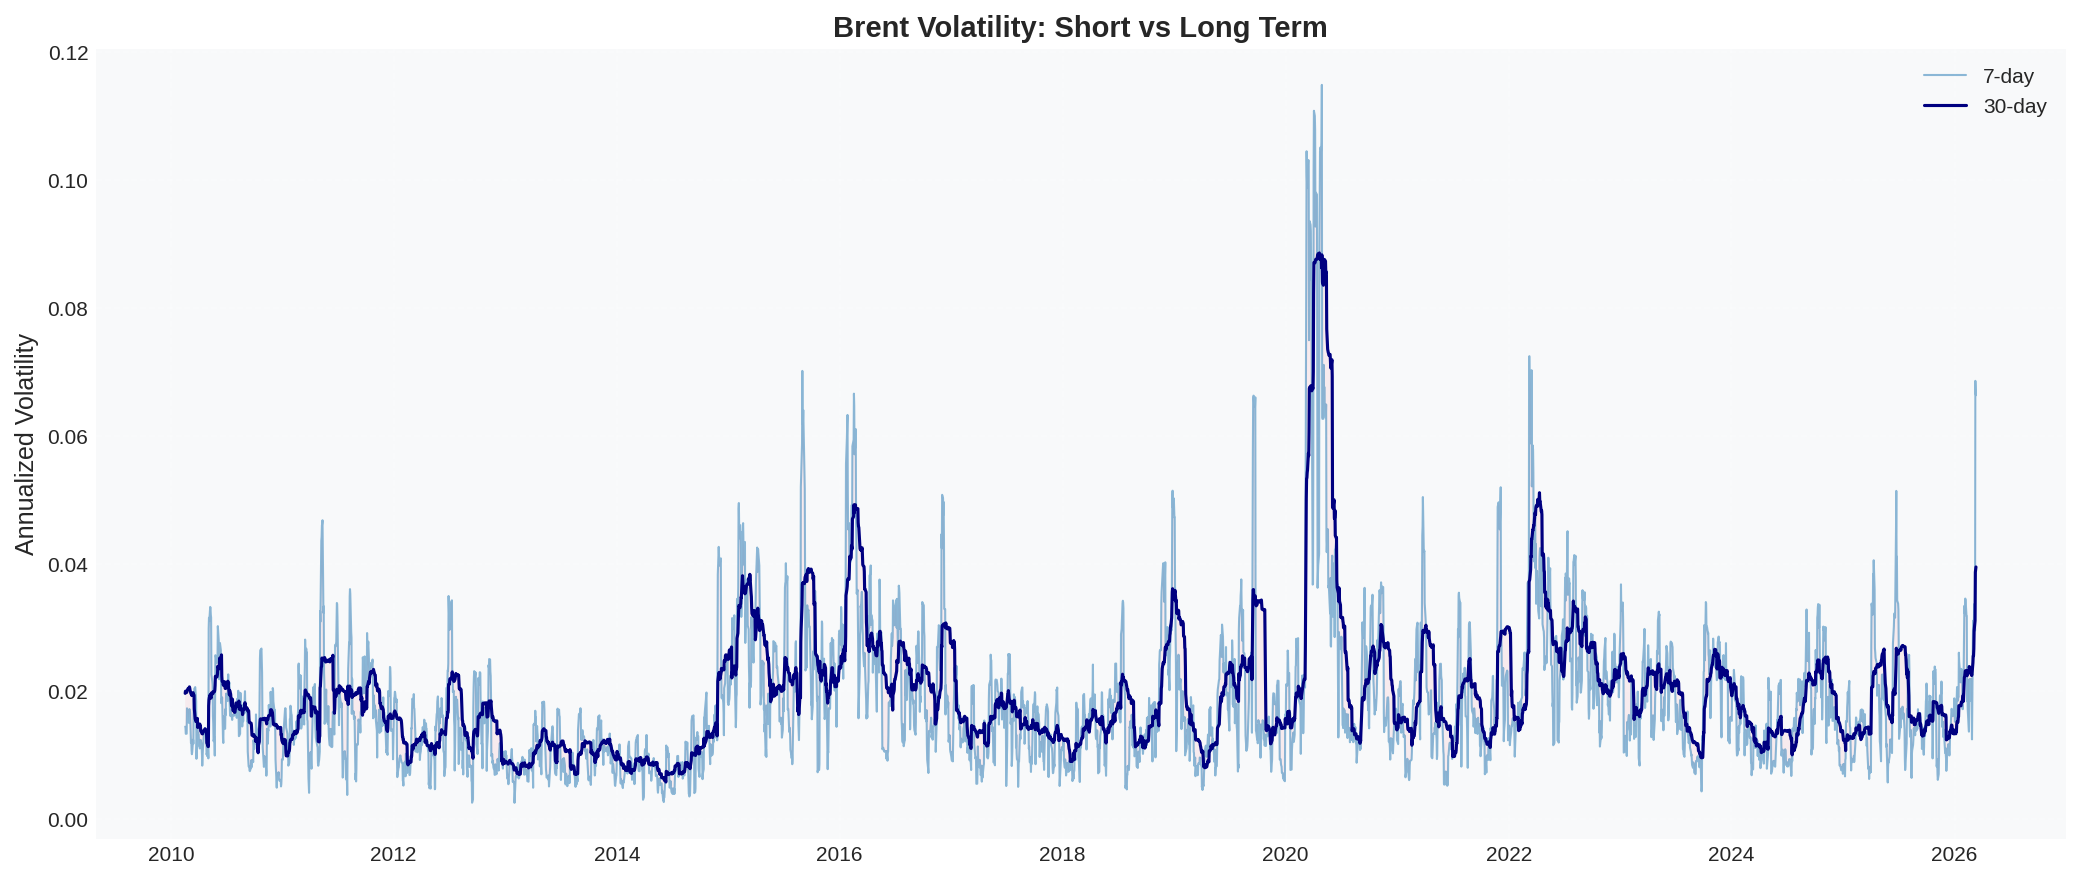

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(df['date'], df['brent_volatility_7d'], color=COLORS['brent'], linewidth=1, alpha=0.5, label='7-day')
plt.plot(df['date'], df['brent_volatility_30d'], color='navy', linewidth=1.5, label='30-day')
plt.fill_between(df['date'], df['brent_volatility_7d'], df['brent_volatility_30d'], alpha=0.1)
plt.title('Brent Volatility: Short vs Long Term', fontweight='bold')
plt.ylabel('Annualized Volatility')
plt.legend()
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.tight_layout()
plt.show()

### Volatility distribution

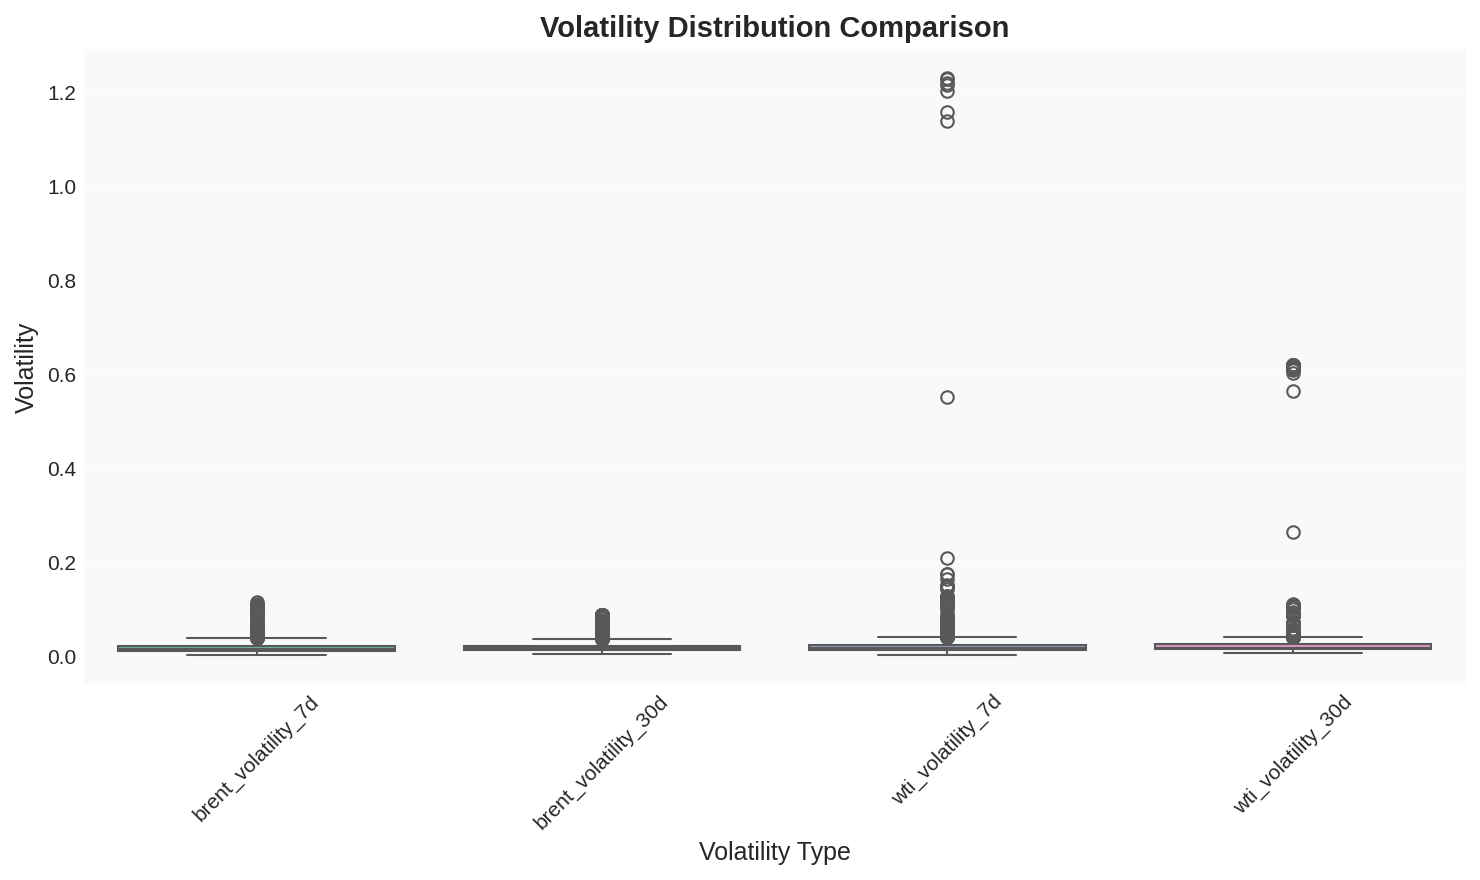

In [15]:
vol_cols = ['brent_volatility_7d', 'brent_volatility_30d', 'wti_volatility_7d', 'wti_volatility_30d']
vol_data = df[vol_cols].melt(var_name='Volatility Type', value_name='Value')

plt.figure(figsize=(10, 6))
sns.boxplot(data=vol_data, x='Volatility Type', y='Value', palette='Set2')
plt.title('Volatility Distribution Comparison', fontweight='bold')
plt.ylabel('Volatility')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Volatility vs GPR

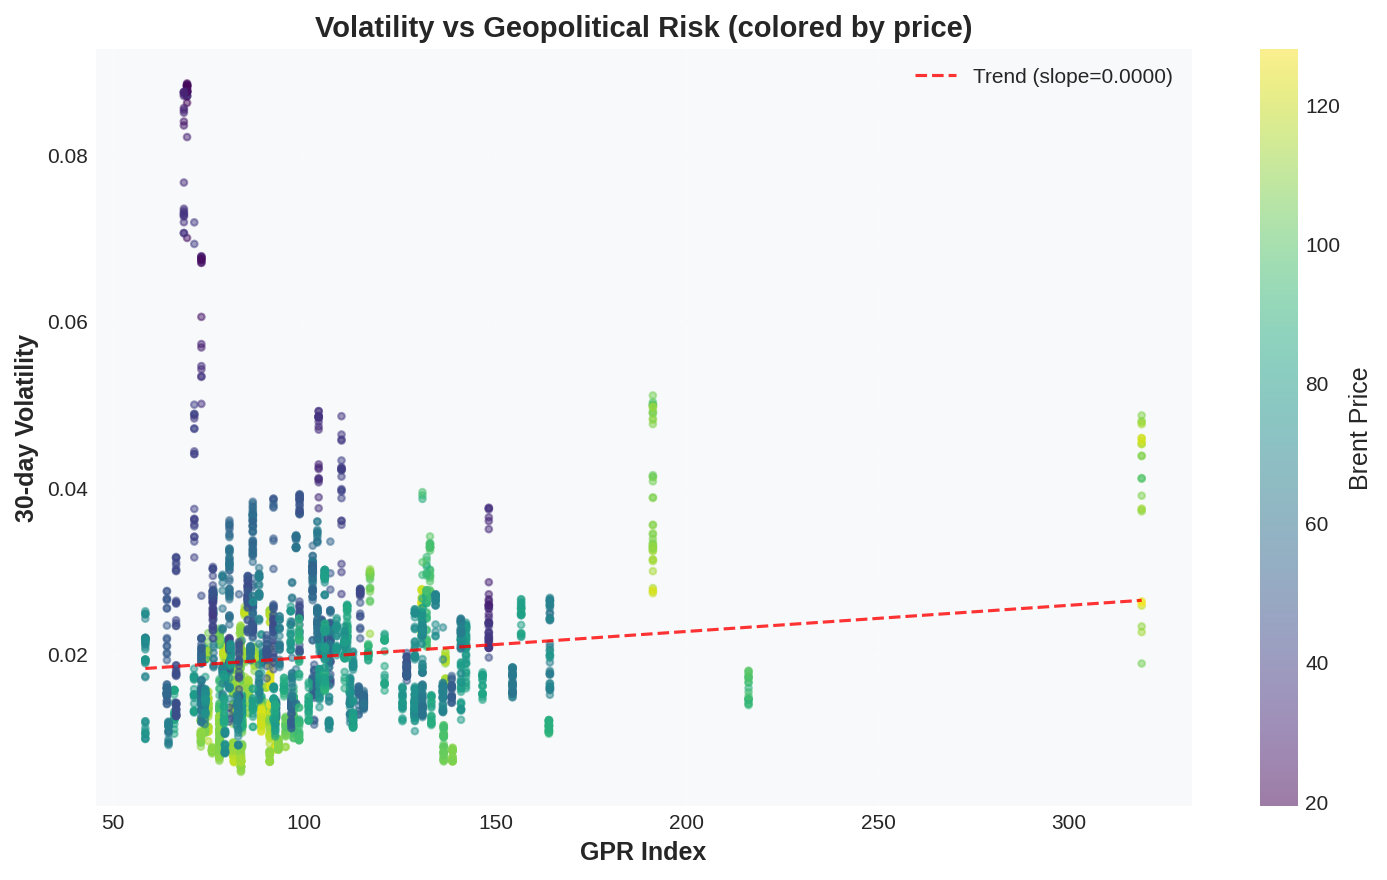

In [16]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['gpr_index'], df['brent_volatility_30d'], 
                      c=df['brent_price'], cmap='viridis', alpha=0.5, s=10)
plt.xlabel('GPR Index', fontweight='bold')
plt.ylabel('30-day Volatility', fontweight='bold')
plt.title('Volatility vs Geopolitical Risk (colored by price)', fontweight='bold')
plt.colorbar(scatter, label='Brent Price')

# Add trend line
z = np.polyfit(df['gpr_index'].dropna(), df['brent_volatility_30d'].dropna(), 1)
p = np.poly1d(z)
plt.plot(df['gpr_index'].sort_values(), p(df['gpr_index'].sort_values()), "r--", alpha=0.8, label=f'Trend (slope={z[0]:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

### Volatility regimes

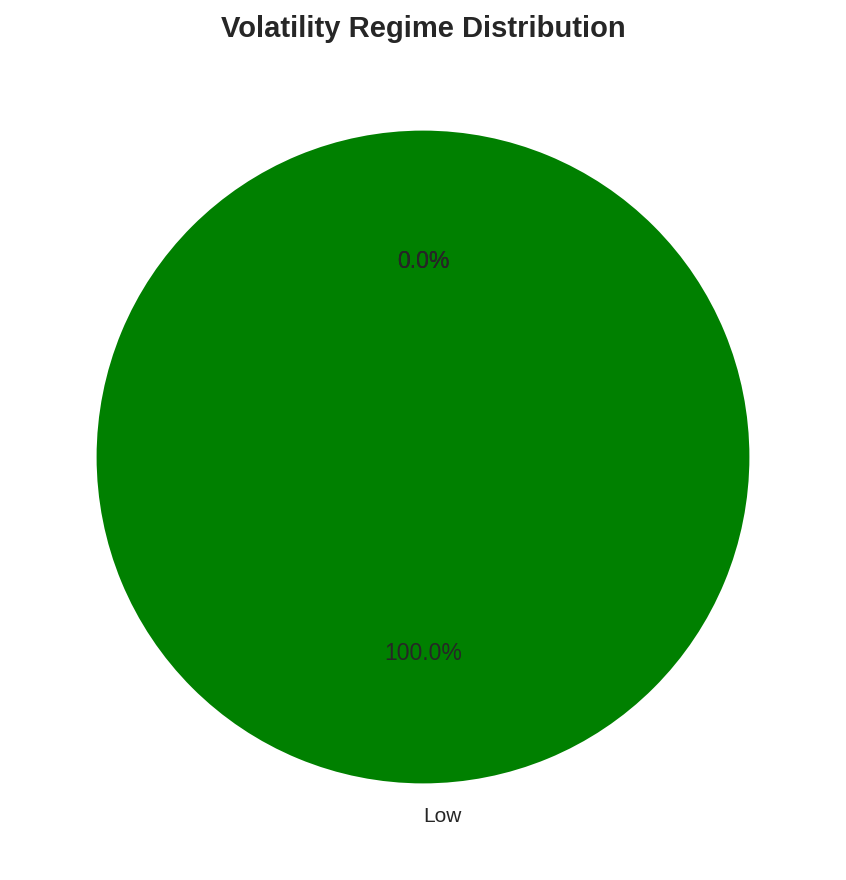

In [17]:
df['volatility_regime'] = pd.cut(df['brent_volatility_30d'], 
                                  bins=[0, 0.2, 0.4, 0.6, np.inf],
                                  labels=['Low', 'Medium', 'High', 'Extreme'])
regime_counts = df['volatility_regime'].value_counts().reindex(['Low', 'Medium', 'High', 'Extreme'])
colors_regime = ['green', 'yellow', 'orange', 'red']

plt.figure(figsize=(8, 6))
regime_counts.plot(kind='pie', colors=colors_regime, autopct='%1.1f%%', startangle=90)
plt.title('Volatility Regime Distribution', fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [18]:

# Volatility clustering analysis
print("\nVolatility Persistence:")

print(f"  Correlation between today's and yesterday's volatility: "
      f"{df['brent_volatility_30d'].corr(df['brent_volatility_30d'].shift(1)):.4f}")
print(f"  Correlation between today's and 5-day lagged volatility: "
      f"{df['brent_volatility_30d'].corr(df['brent_volatility_30d'].shift(5)):.4f}")



Volatility Persistence:
  Correlation between today's and yesterday's volatility: 0.9940
  Correlation between today's and 5-day lagged volatility: 0.9586


#  VOLATILITY REGIME CLUSTERING

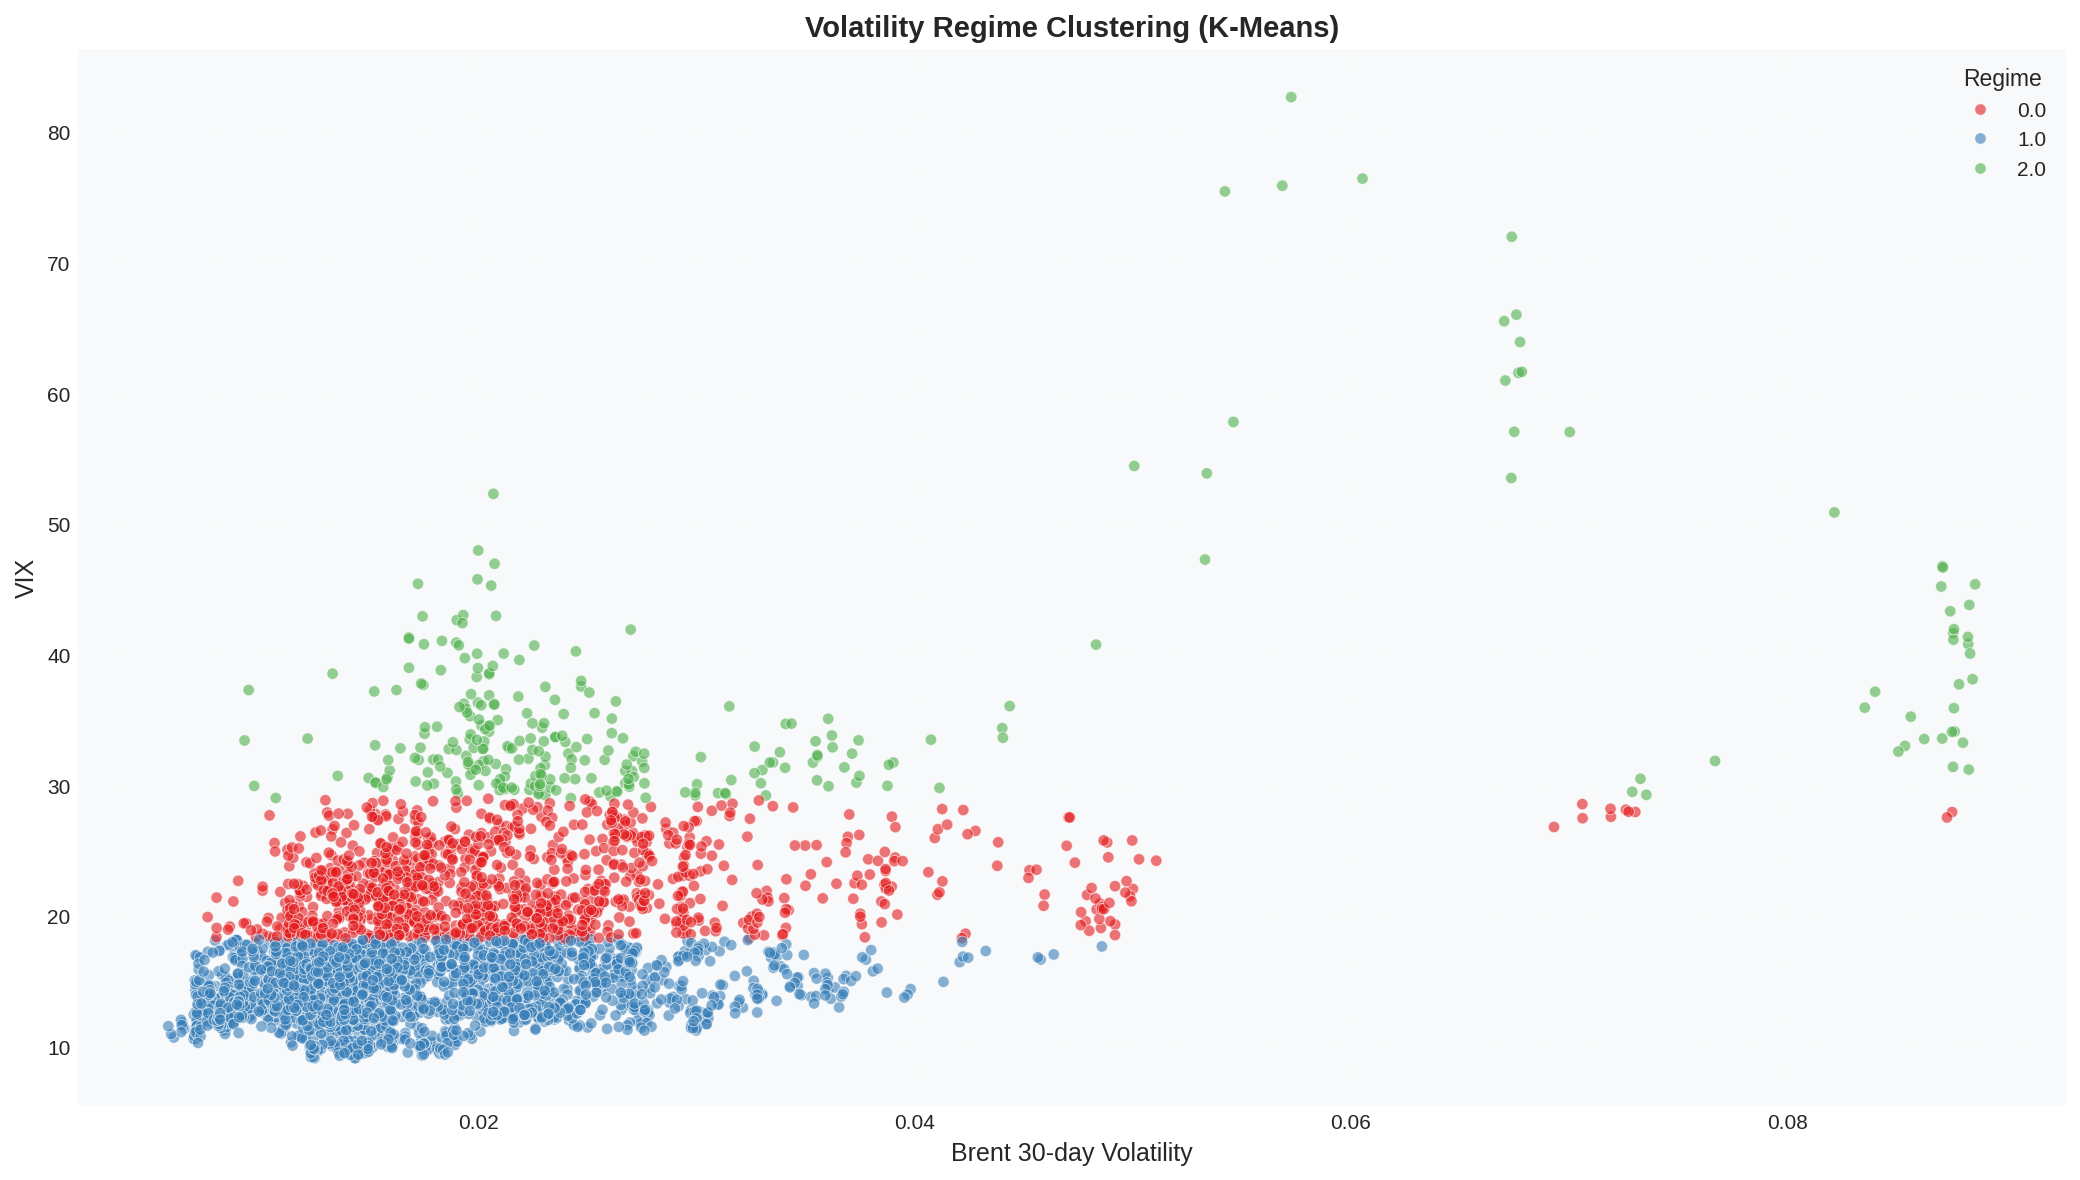


Regime Distribution:
vol_regime_kmeans
0.0    1256
1.0    2499
2.0     292
Name: count, dtype: int64


In [19]:

# K-means clustering on volatility
vol_data = df[["brent_volatility_30d","vix"]].dropna()

kmeans = KMeans(n_clusters=3, random_state=42)
df.loc[vol_data.index,"vol_regime_kmeans"] = kmeans.fit_predict(vol_data)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=df,
    x="brent_volatility_30d",
    y="vix",
    hue="vol_regime_kmeans",
    palette="Set1",
    alpha=0.6,
    s=30
)
plt.title('Volatility Regime Clustering (K-Means)', fontweight='bold', fontsize=14)
plt.xlabel('Brent 30-day Volatility')
plt.ylabel('VIX')
plt.legend(title='Regime')
plt.tight_layout()
plt.show()

print("\nRegime Distribution:")
print(df['vol_regime_kmeans'].value_counts().sort_index())

#  OIL SHOCK DETECTION

Total Oil Shocks Detected: 64
Percentage of days with shocks: 1.58%


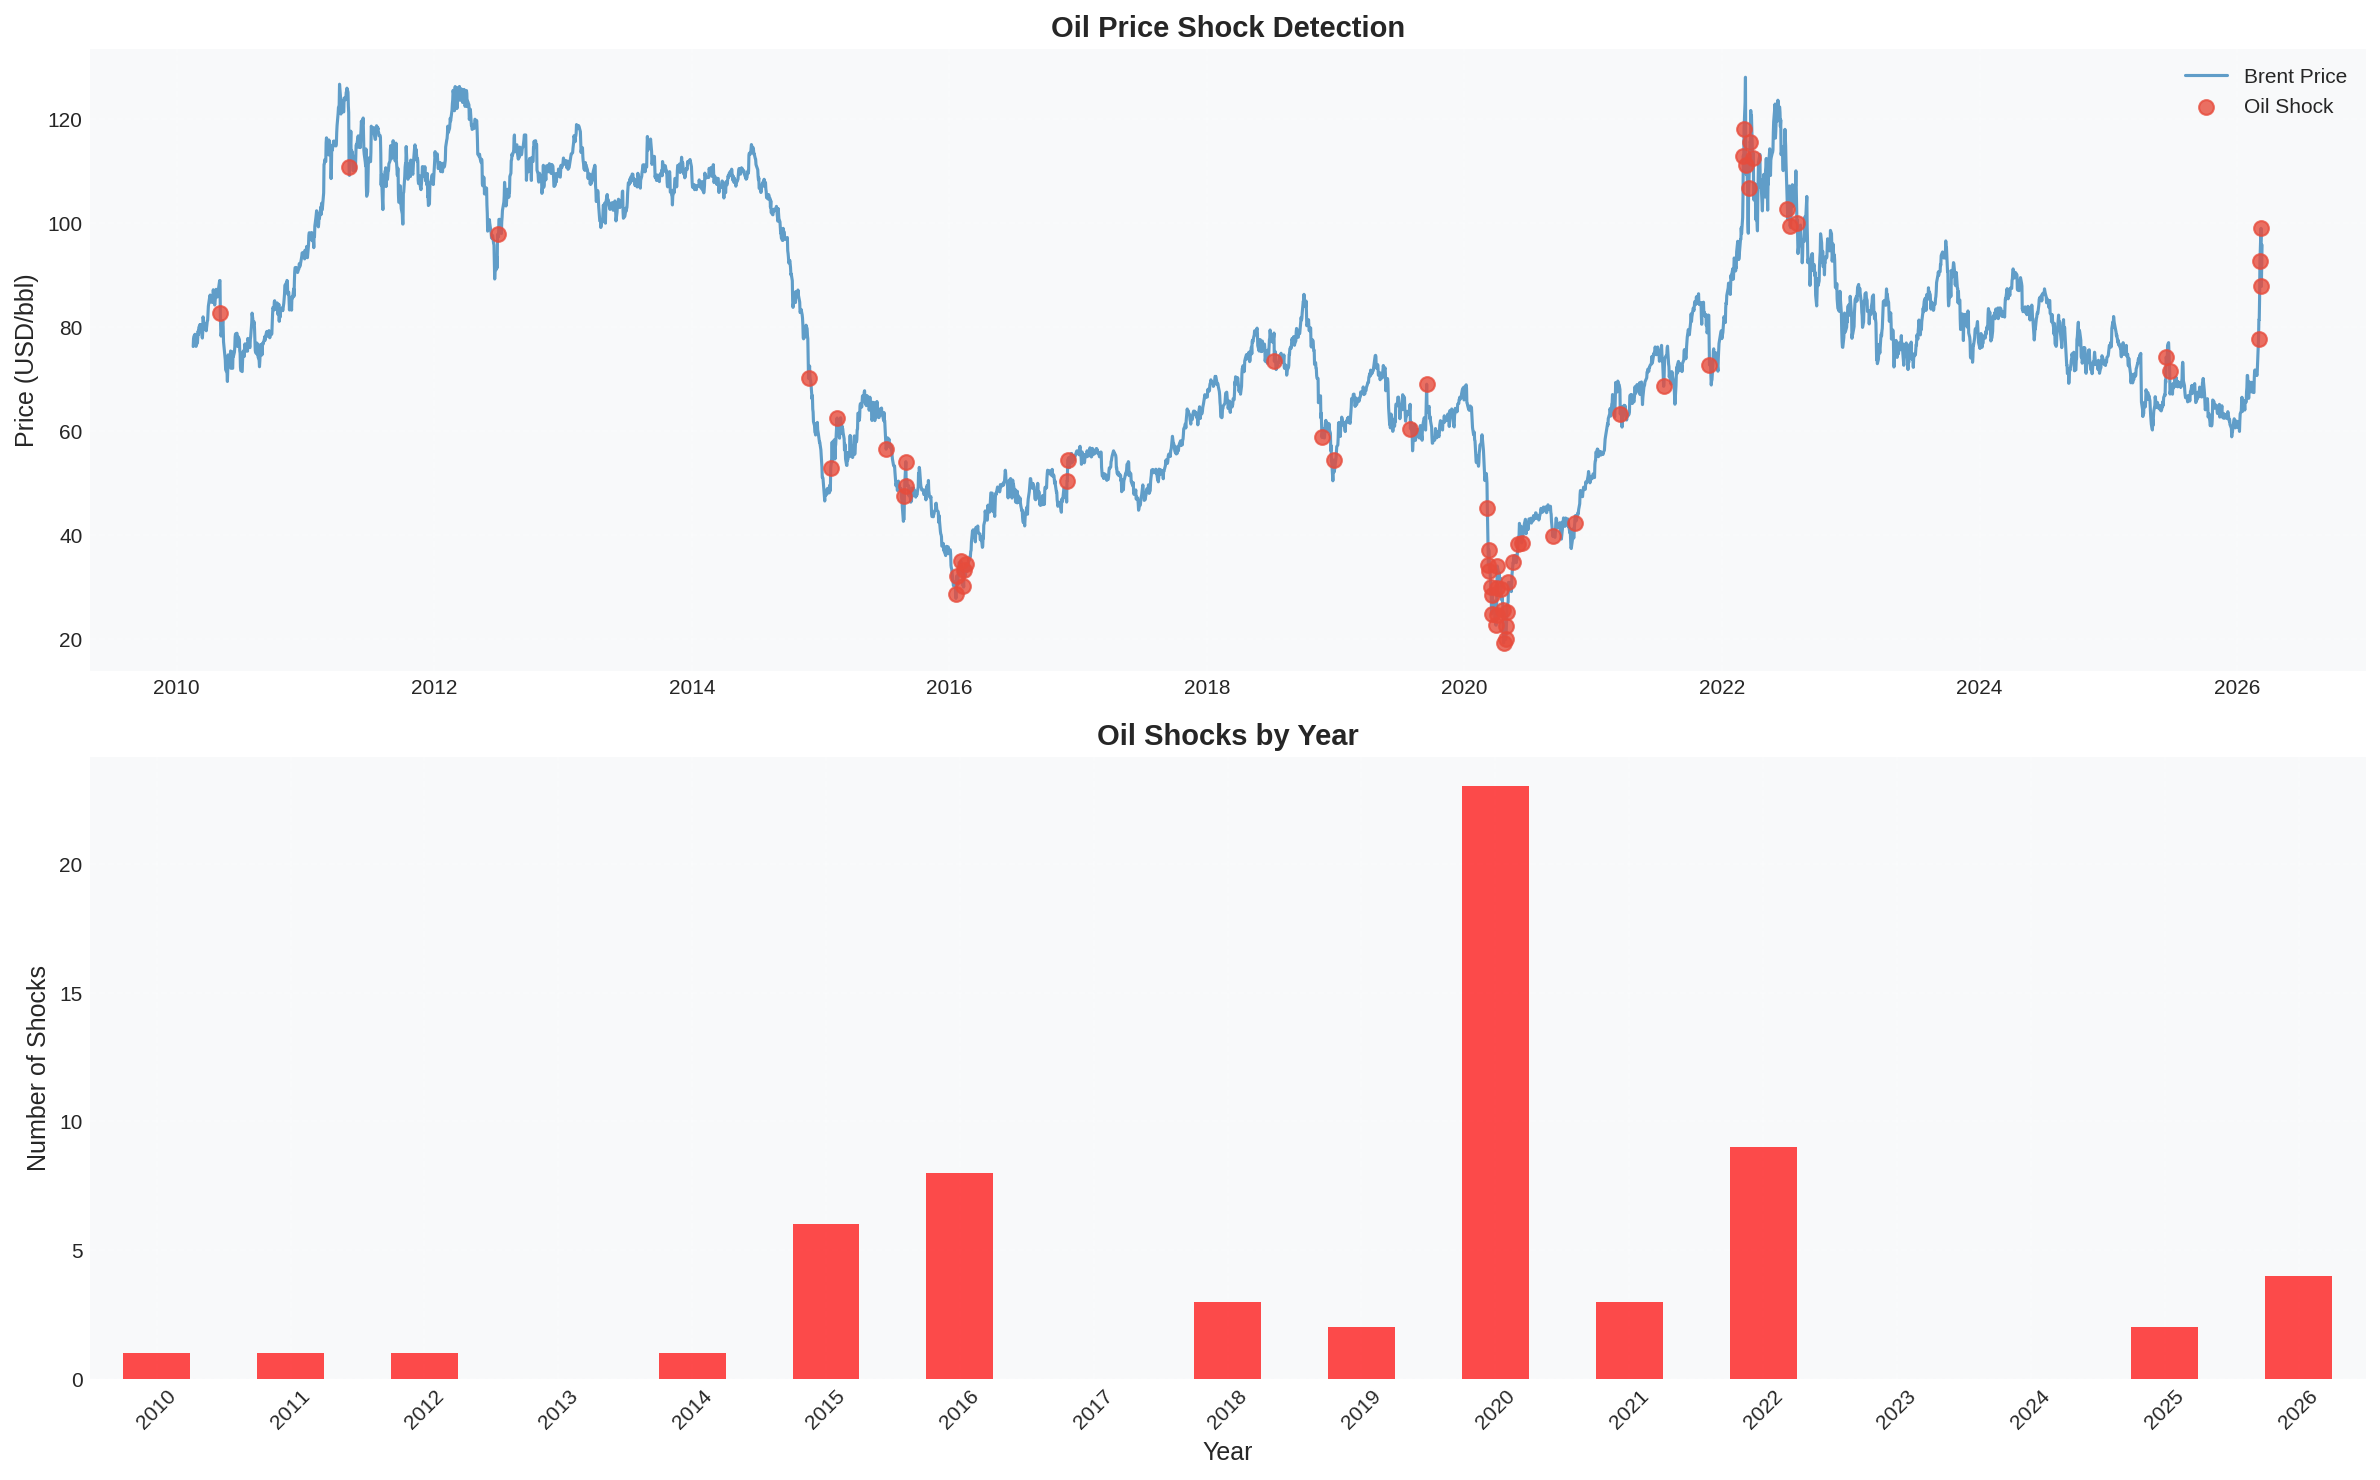


Characteristics of Shock vs Non-Shock Days:
       gpr_index      vix  event_flag  brent_volatility_30d
shock                                                      
False   102.4115  18.1825         1.0                0.0192
True    114.1064  31.5066         1.0                0.0436


In [20]:
# Define shocks as returns > 3 standard deviations
df["shock"] = df["brent_return"].abs() > 3 * df["brent_return"].std()

print(f"Total Oil Shocks Detected: {df['shock'].sum():,}")
print(f"Percentage of days with shocks: {df['shock'].mean()*100:.2f}%")

# Visualize shocks
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Price with shocks
ax = axes[0]
ax.plot(df['date'], df['brent_price'], color=COLORS['brent'], alpha=0.7, label='Brent Price')
shock_points = df[df['shock']]
ax.scatter(shock_points['date'], shock_points['brent_price'], 
           color=COLORS['shock'], s=50, alpha=0.8, zorder=5, label='Oil Shock')
ax.set_title('Oil Price Shock Detection', fontweight='bold', fontsize=14)
ax.set_ylabel('Price (USD/bbl)')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator(2))

# Shock frequency by year
ax = axes[1]
yearly_shocks = df.groupby(df['date'].dt.year)['shock'].sum()
yearly_shocks.plot(kind='bar', ax=ax, color='red', alpha=0.7)
ax.set_title('Oil Shocks by Year', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Shocks')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Characteristics of shock days
shock_analysis = df.groupby('shock').agg({
    'gpr_index': 'mean',
    'vix': 'mean',
    'event_flag': 'mean',
    'brent_volatility_30d': 'mean'
}).round(4)

print("\nCharacteristics of Shock vs Non-Shock Days:")
print(shock_analysis)


#  ANNUAL & SEASONAL PATTERNS

In [21]:

# Add time features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week

# Annual summary
annual_summary = df.groupby('year').agg({
    'brent_price': ['mean', 'std', 'min', 'max'],
    'wti_price': 'mean',
    'gpr_index': 'mean',
    'vix': 'mean',
    'brent_volatility_30d': 'mean',
    'event_flag': 'sum',
    'brent_return': ['mean', 'std'],
    'shock': 'sum'
}).round(2)

print("\nAnnual Summary Statistics:")

print(annual_summary.to_string())

# Monthly patterns
monthly_patterns = df.groupby('month').agg({
    'brent_price': 'mean',
    'brent_volatility_30d': 'mean',
    'brent_return': 'mean',
    'event_flag': 'mean'
}).round(4)

print("\nMonthly Patterns (Averages):")

print(monthly_patterns.to_string())

# Day of week patterns
dow_patterns = df.groupby('day_of_week').agg({
    'brent_return': ['mean', 'std'],
    'brent_volatility_30d': 'mean',
    'event_flag': 'mean'
}).round(4)

print("\nDay of Week Patterns:")

dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
for i, name in enumerate(dow_names):
    if i in dow_patterns.index:
        print(f"{name:10s}: Mean Return={dow_patterns.loc[i, ('brent_return', 'mean')]:+.6f}, "
              f"Std={dow_patterns.loc[i, ('brent_return', 'std')]:.6f}, "
              f"Event Prob={dow_patterns.loc[i, ('event_flag', 'mean')]:.3f}")




Annual Summary Statistics:
     brent_price                       wti_price gpr_index    vix brent_volatility_30d event_flag brent_return       shock
            mean    std    min     max      mean      mean   mean                 mean        sum         mean   std   sum
year                                                                                                                      
2010       81.04   5.74  69.55   94.75     79.97     83.48  22.64                 0.02        222         0.00  0.02     1
2011      110.95   6.97  93.33  126.65     95.11     91.30  24.20                 0.02        252         0.00  0.02     1
2012      111.76   7.83  89.23  126.22     94.21     81.88  17.80                 0.01        250         0.00  0.01     1
2013      108.72   4.25  99.13  118.90     98.05     82.14  14.23                 0.01        252         0.00  0.01     0
2014       99.35  14.62  57.33  115.06     92.91     96.85  14.17                 0.01        252        -0.00 

## Visualization

###  Annual price bars

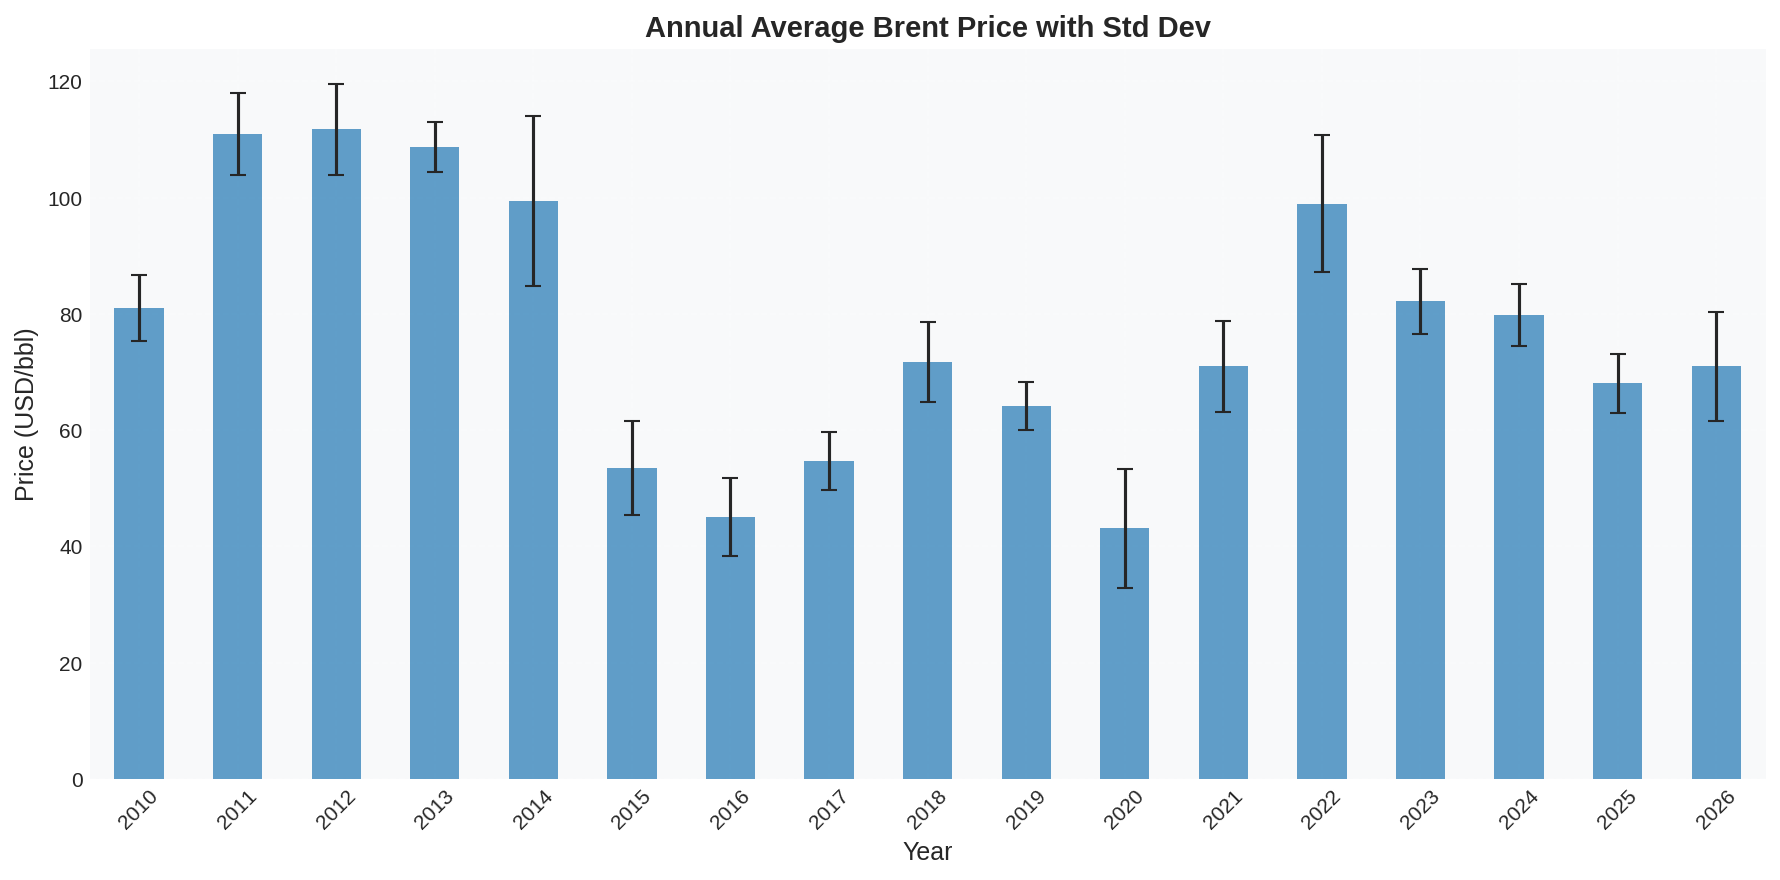

In [22]:



annual_means = df.groupby('year')['brent_price'].mean()
annual_stds = df.groupby('year')['brent_price'].std()


annual_means.plot(
    kind='bar',
    color=COLORS['brent'],
    alpha=0.7,
    yerr=annual_stds,
    capsize=4,
    figsize=(12, 6)  
)

plt.title('Annual Average Brent Price with Std Dev', fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Price (USD/bbl)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



###  Monthly heatmap

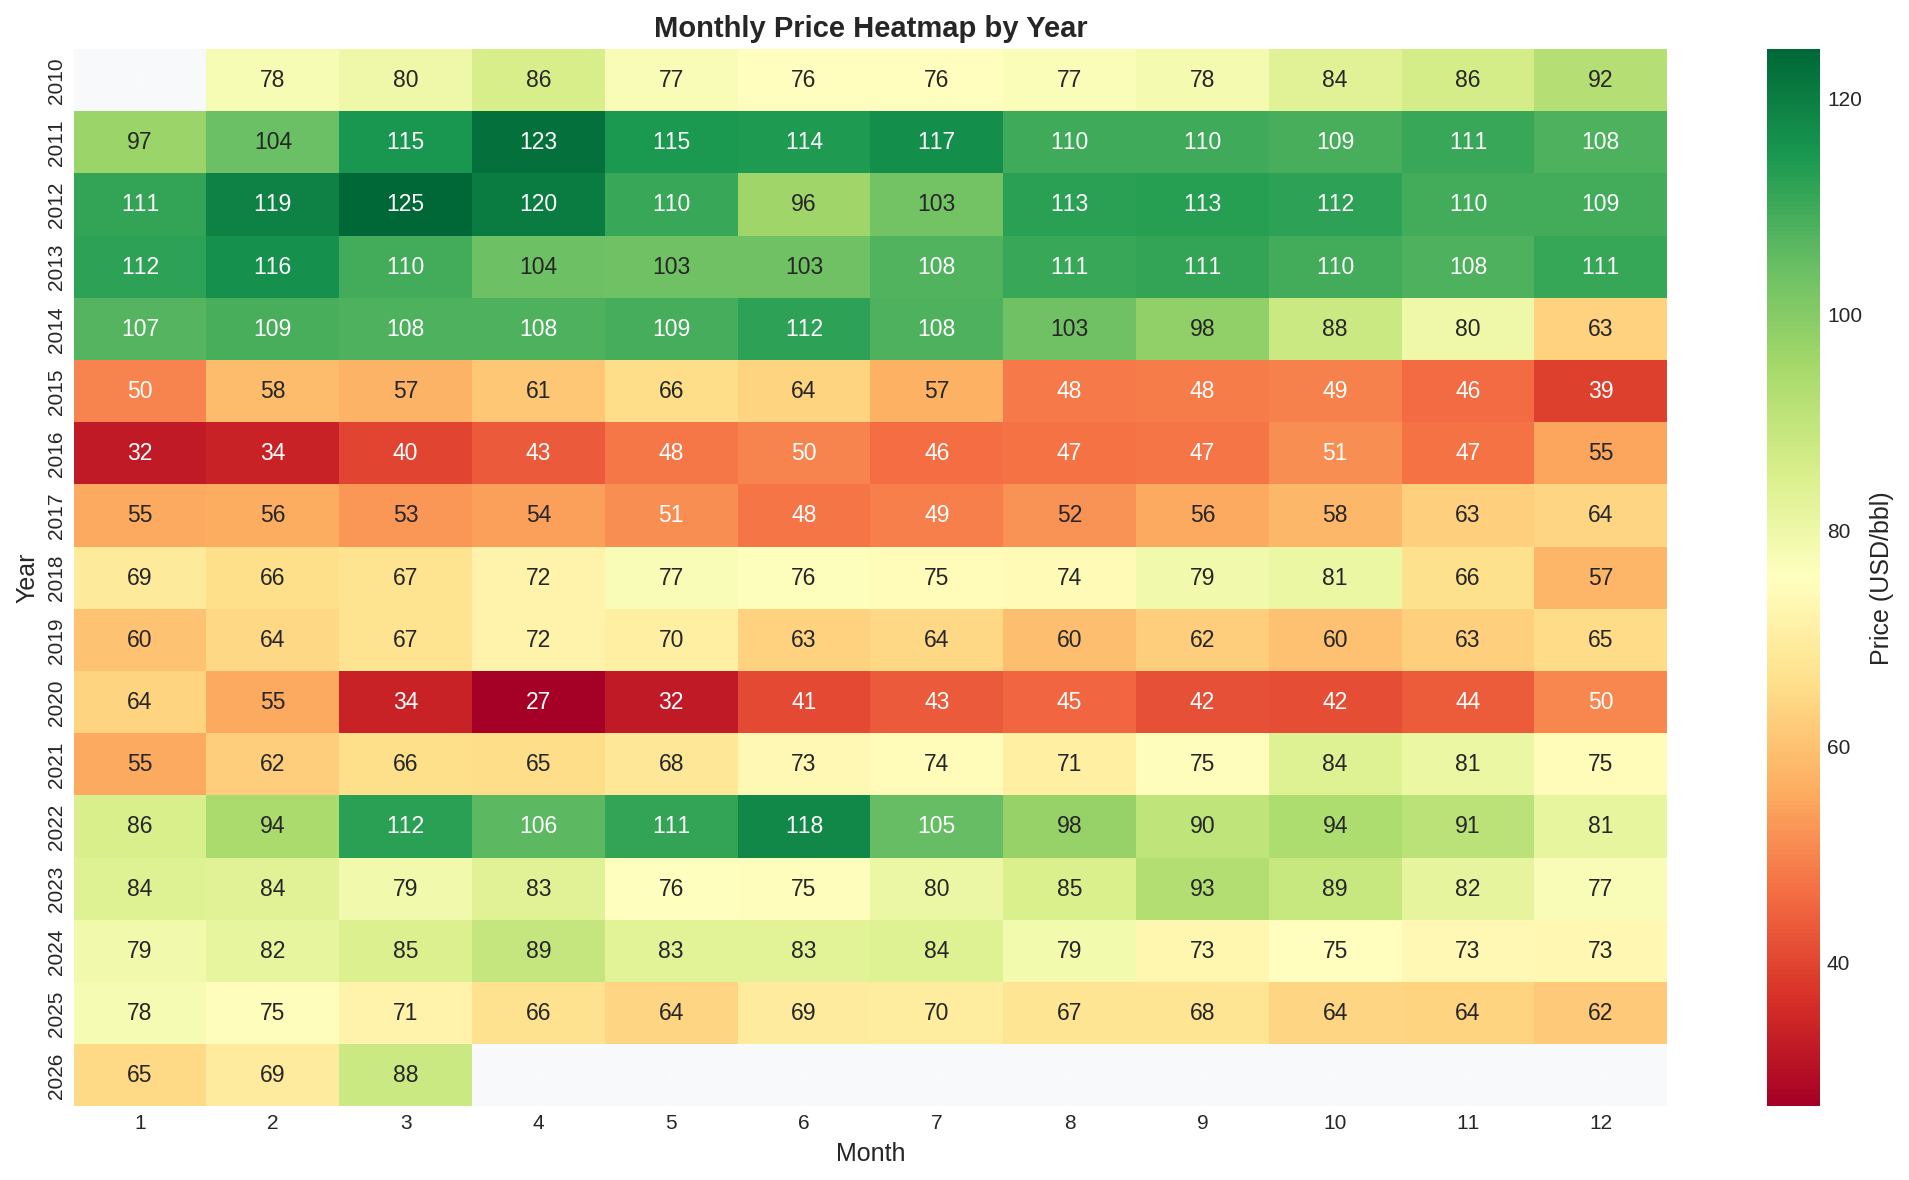

In [23]:

monthly_pivot = df.pivot_table(
    values='brent_price', 
    index='year', 
    columns='month', 
    aggfunc='mean'
)


plt.figure(figsize=(14, 8))
sns.heatmap(
    monthly_pivot, 
    cmap='RdYlGn', 
    annot=True, 
    fmt='.0f', 
    cbar_kws={'label': 'Price (USD/bbl)'}
)

plt.title('Monthly Price Heatmap by Year', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

###  Event frequency by month

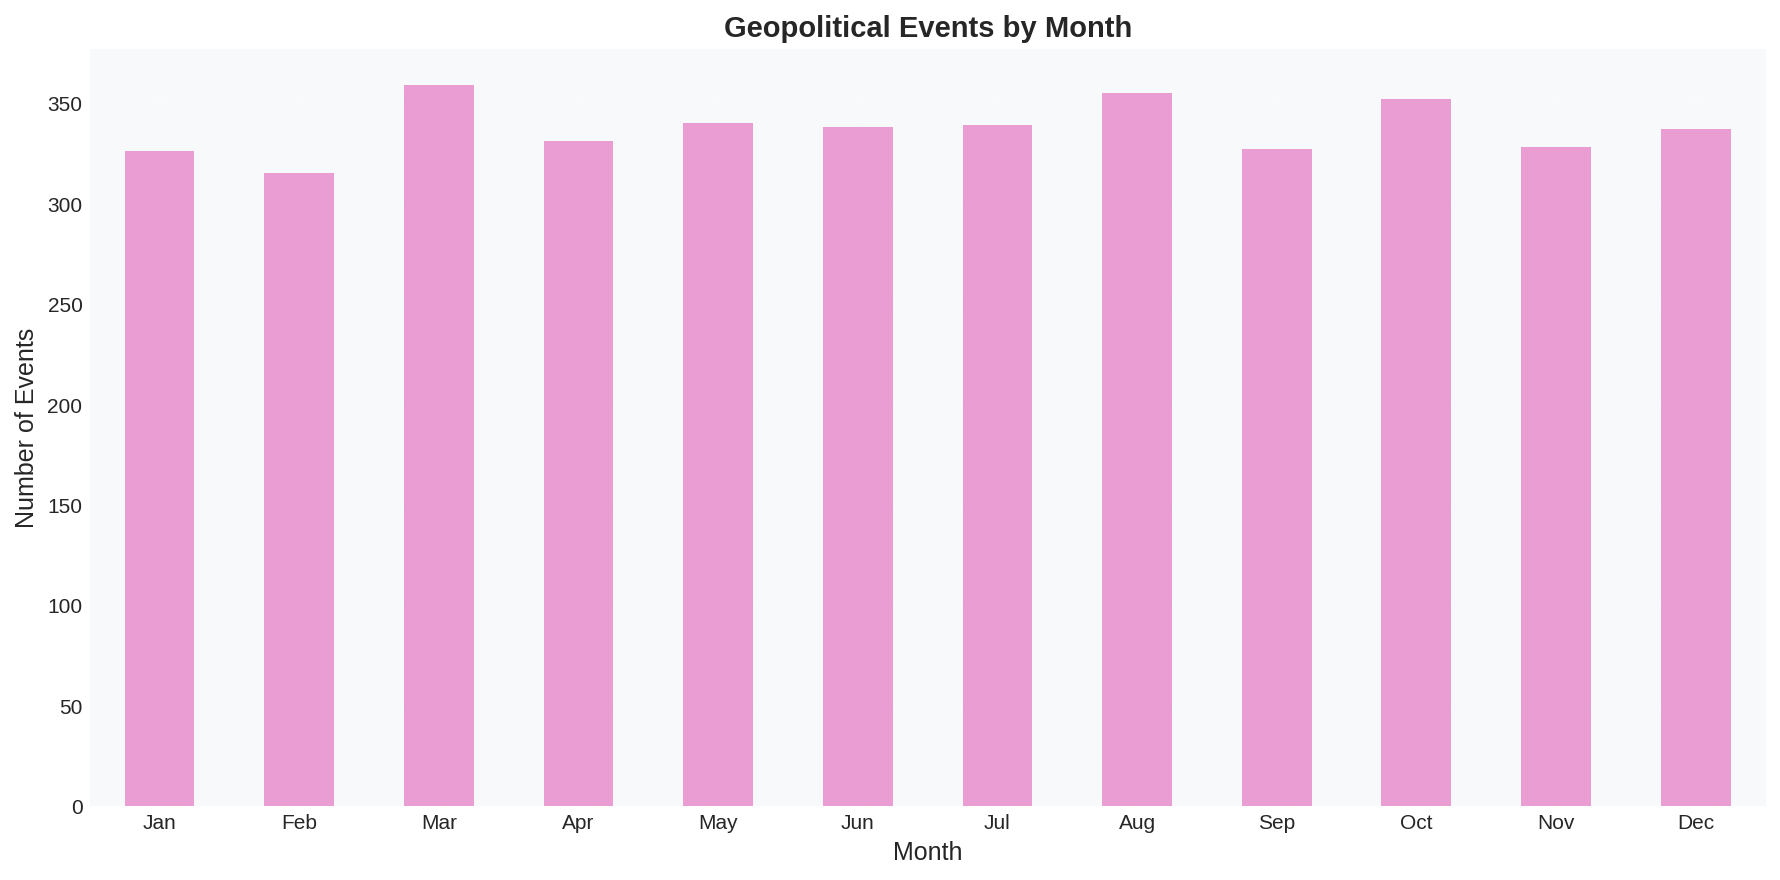

In [24]:


monthly_events = df[df['event_flag'] == 1].groupby('month').size()


plt.figure(figsize=(12, 6))
monthly_events.plot(
    kind='bar',
    color=COLORS['event'],
    alpha=0.7
)

plt.title('Geopolitical Events by Month', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Events')
plt.xticks(
    ticks=range(12), 
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], 
    rotation=0
)
plt.tight_layout()
plt.show()


###  Day of week returns

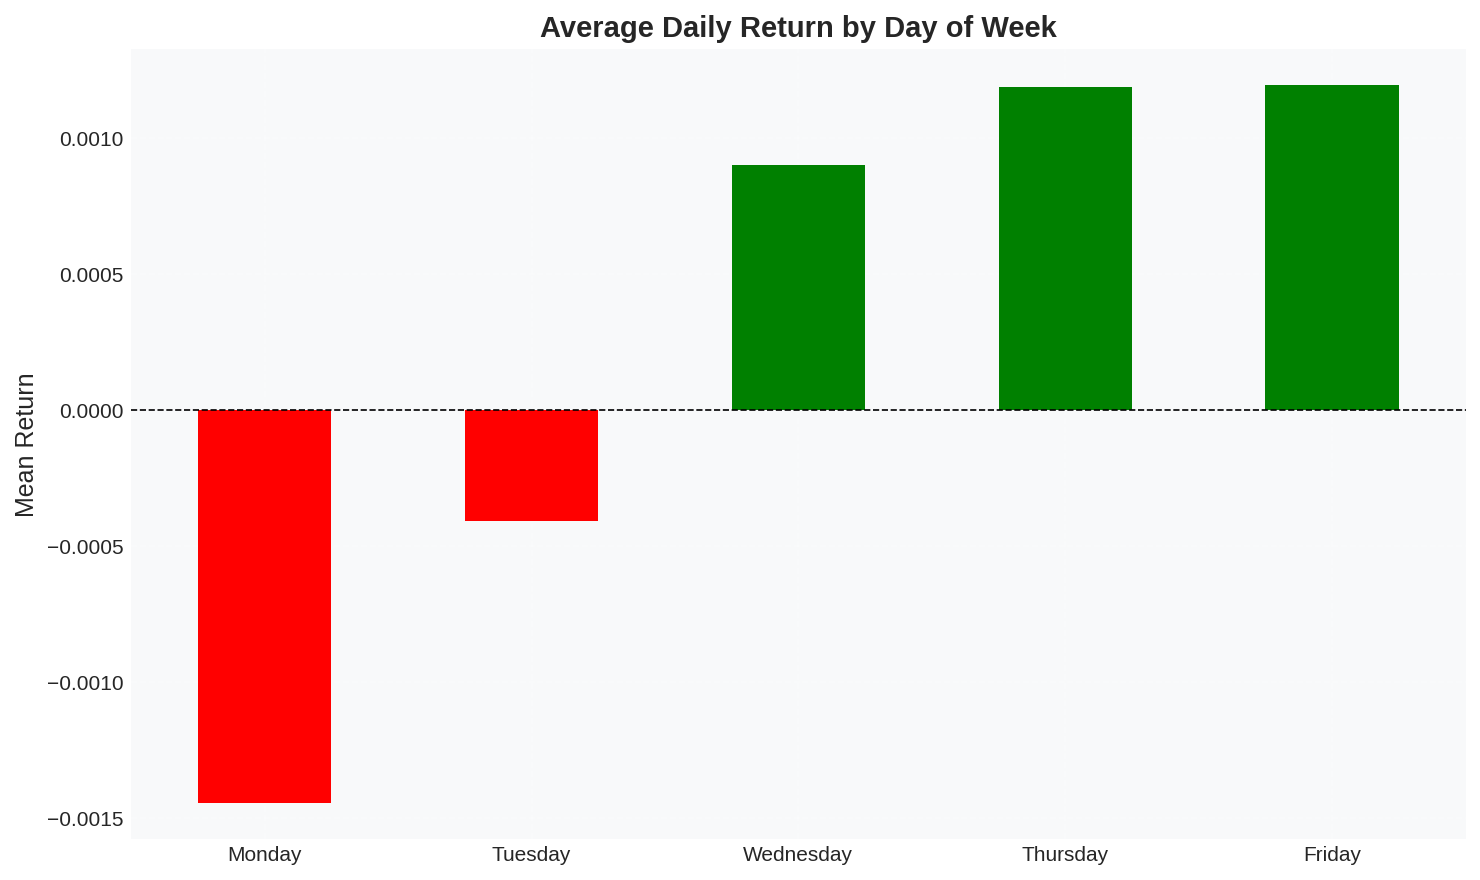

In [25]:



dow_returns = df.groupby('day_of_week')['brent_return'].mean()
dow_returns.index = dow_names[:len(dow_returns)]

# Assign colors: green for positive, red for negative
colors_dow = ['green' if x > 0 else 'red' for x in dow_returns]


plt.figure(figsize=(10, 6))
dow_returns.plot(kind='bar', color=colors_dow)

plt.title('Average Daily Return by Day of Week', fontweight='bold')
plt.ylabel('Mean Return')
plt.xlabel('')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#  MACHINE LEARNING FEATURE ANALYSIS

In [26]:

# Prepare features for ML
print("\nPreparing features for ML analysis...")

# Create additional features
df_ml = df.copy()

# Lag features
for lag in [1, 2, 3, 5, 10]:
    df_ml[f'brent_lag_{lag}'] = df_ml['brent_price'].shift(lag)
    df_ml[f'gpr_lag_{lag}'] = df_ml['gpr_index'].shift(lag)

# Rolling statistics
for window in [5, 10, 20]:
    df_ml[f'brent_ma_{window}'] = df_ml['brent_price'].rolling(window).mean()
    df_ml[f'brent_std_{window}'] = df_ml['brent_price'].rolling(window).std()
    df_ml[f'gpr_ma_{window}'] = df_ml['gpr_index'].rolling(window).mean()

# Price differences
df_ml['brent_mom_1'] = df_ml['brent_price'].diff(1)
df_ml['brent_mom_5'] = df_ml['brent_price'].diff(5)
df_ml['brent_pct_change_5'] = df_ml['brent_price'].pct_change(5)

# Interaction features
df_ml['gpr_vix_ratio'] = df_ml['gpr_index'] / (df_ml['vix'] + 1)  # Avoid division by zero
df_ml['price_vol_ratio'] = df_ml['brent_price'] / (df_ml['brent_volatility_30d'] + 1)

# Target: next day price
df_ml['target'] = df_ml['brent_price'].shift(-1)

# Base features for modeling
base_features = [
    "wti_price",
    "gpr_index",
    "vix",
    "dxy_index",
    "brent_volatility_30d",
    "wti_volatility_30d",
    "brent_wti_spread",
    "event_flag"
]

# All features for importance analysis
feature_cols = base_features + ['brent_lag_1', 'brent_lag_2', 'brent_ma_5', 
                                 'brent_ma_20', 'gpr_lag_1', 'gpr_lag_2', 
                                 'gpr_ma_5', 'gpr_vix_ratio']

# Drop NaN values
ml_data = df_ml[base_features + ['target']].dropna()
ml_data_full = df_ml[feature_cols + ['target']].dropna()

print(f"ML dataset size: {len(ml_data):,} rows")


Preparing features for ML analysis...
ML dataset size: 4,046 rows


##  RANDOM FOREST MODEL


Random Forest Performance:
MAE: $1.42
R² Score: 0.9517

Feature Importance:
             Feature  Importance
           wti_price    0.969047
    brent_wti_spread    0.027612
           dxy_index    0.001045
                 vix    0.000638
  wti_volatility_30d    0.000582
           gpr_index    0.000575
brent_volatility_30d    0.000501
          event_flag    0.000000


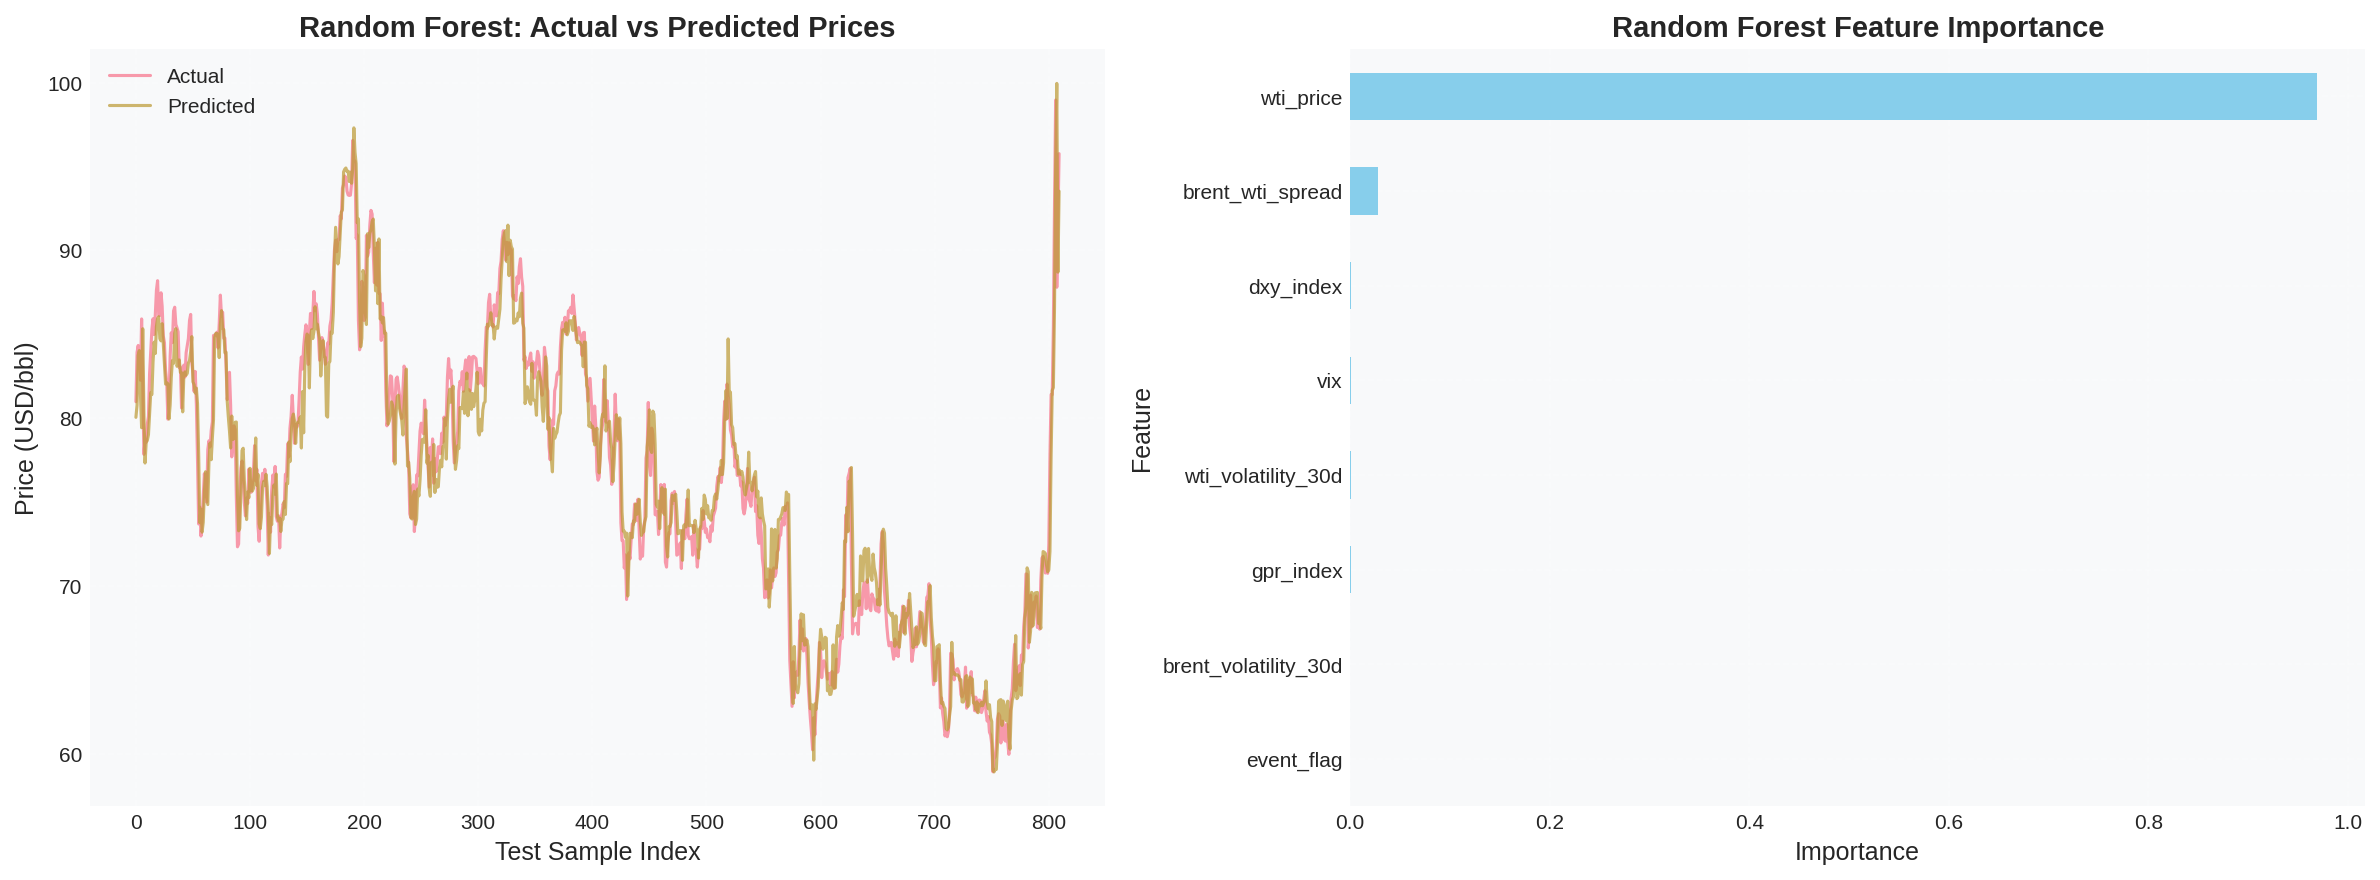

In [27]:

# Prepare data
X = ml_data[base_features]
y = ml_data['target']

# Train-test split (time series - no shuffle)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("\nRandom Forest Performance:")

print(f"MAE: ${mean_absolute_error(y_test, rf_pred):.2f}")
print(f"R² Score: {r2_score(y_test, rf_pred):.4f}")

# Feature importance
rf_importance = pd.DataFrame({
    'Feature': base_features,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature Importance:")
print(rf_importance.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Predictions vs Actual
ax = axes[0]
ax.plot(y_test.values, label='Actual', alpha=0.7)
ax.plot(rf_pred, label='Predicted', alpha=0.7)
ax.set_title('Random Forest: Actual vs Predicted Prices', fontweight='bold')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('Price (USD/bbl)')
ax.legend()

# Feature importance
ax = axes[1]
rf_importance.set_index('Feature')['Importance'].sort_values().plot(kind='barh', ax=ax, color='skyblue')
ax.set_title('Random Forest Feature Importance', fontweight='bold')
ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

##  XGBOOST MODEL

In [28]:
# Prepare data
X = ml_data[base_features]
y = ml_data['target']

# Train-test split
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluation
print("\nXGBoost Performance:")

print(f"MAE: ${mean_absolute_error(y_test, xgb_pred):.2f}")
print(f"R² Score: {r2_score(y_test, xgb_pred):.4f}")



XGBoost Performance:
MAE: $3.53
R² Score: 0.6953


## LIGHTGBM MODEL


LightGBM Performance:
MAE: $1.29
R² Score: 0.9583
MODEL COMPARISON
        Model      MAE       R²
Random Forest 1.418629 0.951717
      XGBoost 3.534617 0.695308
     LightGBM 1.292587 0.958330


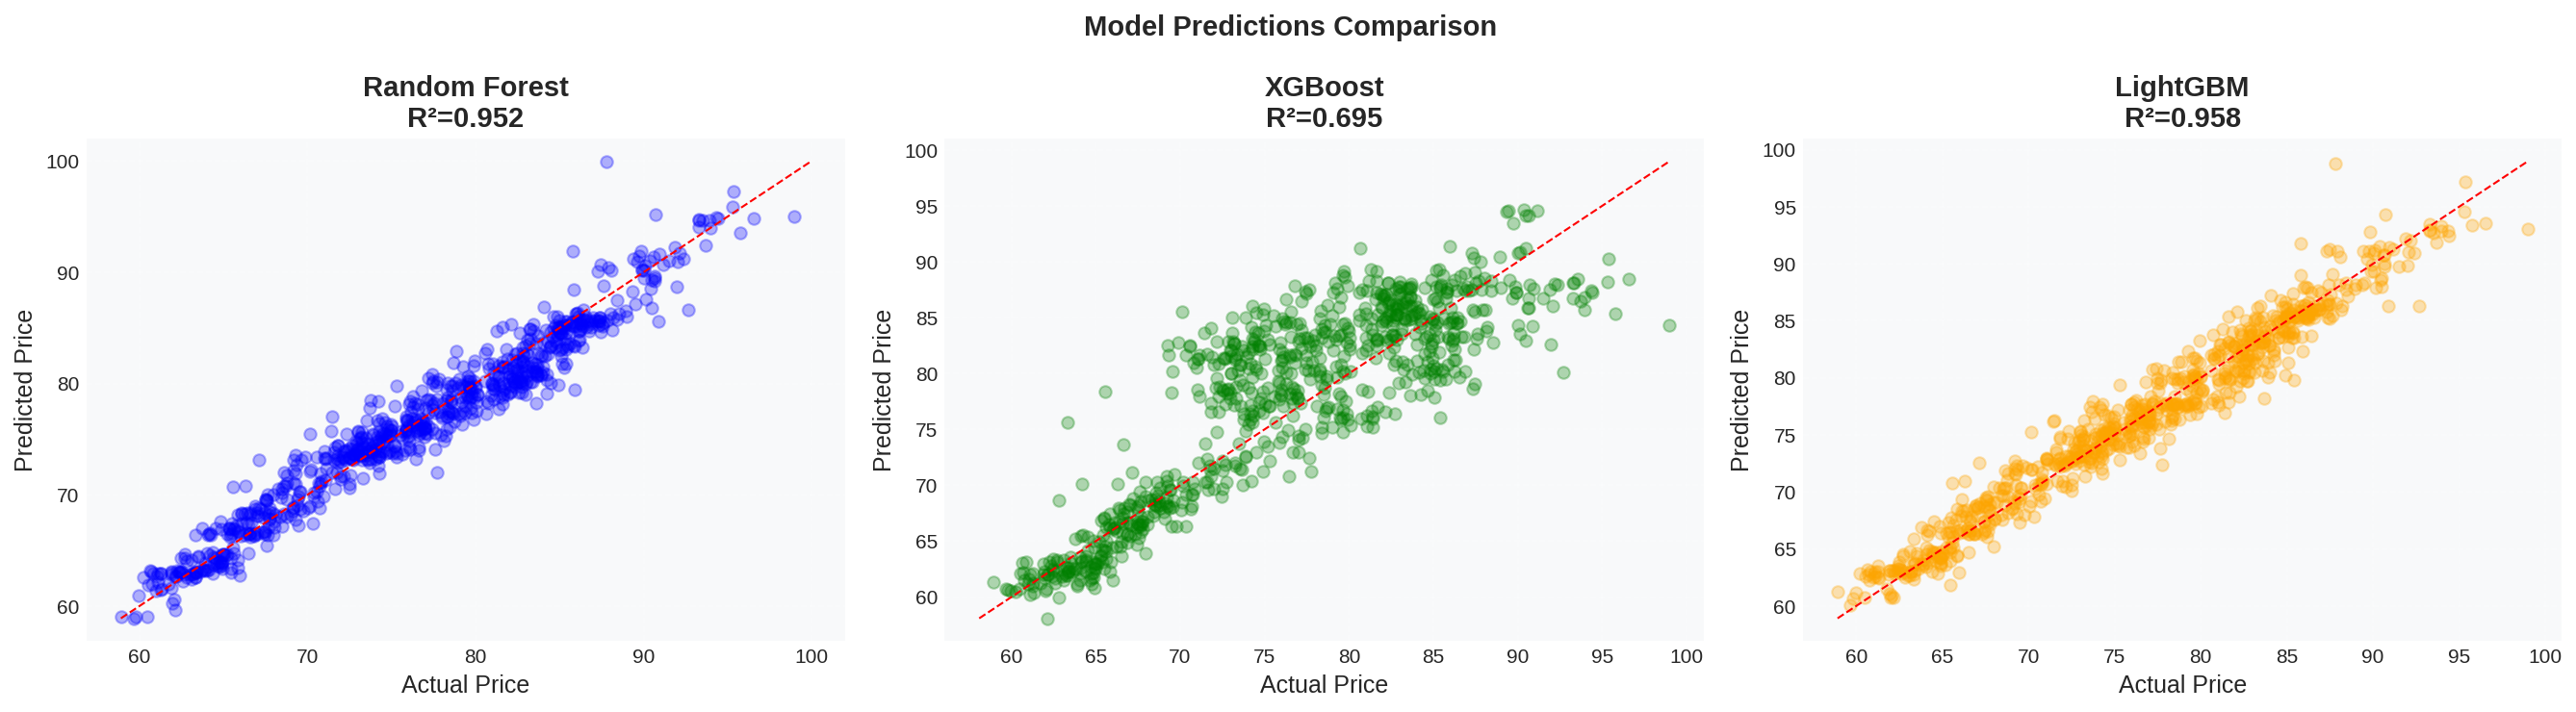

In [29]:
# Train LightGBM
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    random_state=42,
    verbosity=-1
)

lgb_model.fit(X_train, y_train)

# Predictions
lgb_pred = lgb_model.predict(X_test)

# Evaluation
print("\nLightGBM Performance:")

print(f"MAE: ${mean_absolute_error(y_test, lgb_pred):.2f}")
print(f"R² Score: {r2_score(y_test, lgb_pred):.4f}")

# Model comparison

print("MODEL COMPARISON")


comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'MAE': [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred),
        mean_absolute_error(y_test, lgb_pred)
    ],
    'R²': [
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred),
        r2_score(y_test, lgb_pred)
    ]
})

print(comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [('Random Forest', rf_pred), ('XGBoost', xgb_pred), ('LightGBM', lgb_pred)]
colors = ['blue', 'green', 'orange']

for idx, (name, pred) in enumerate(models):
    ax = axes[idx]
    ax.scatter(y_test, pred, alpha=0.3, color=colors[idx])
    
    # Perfect prediction line
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
    
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name}\nR²={r2_score(y_test, pred):.3f}')

plt.suptitle('Model Predictions Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

#  FEATURE IMPORTANCE WITH SHAP

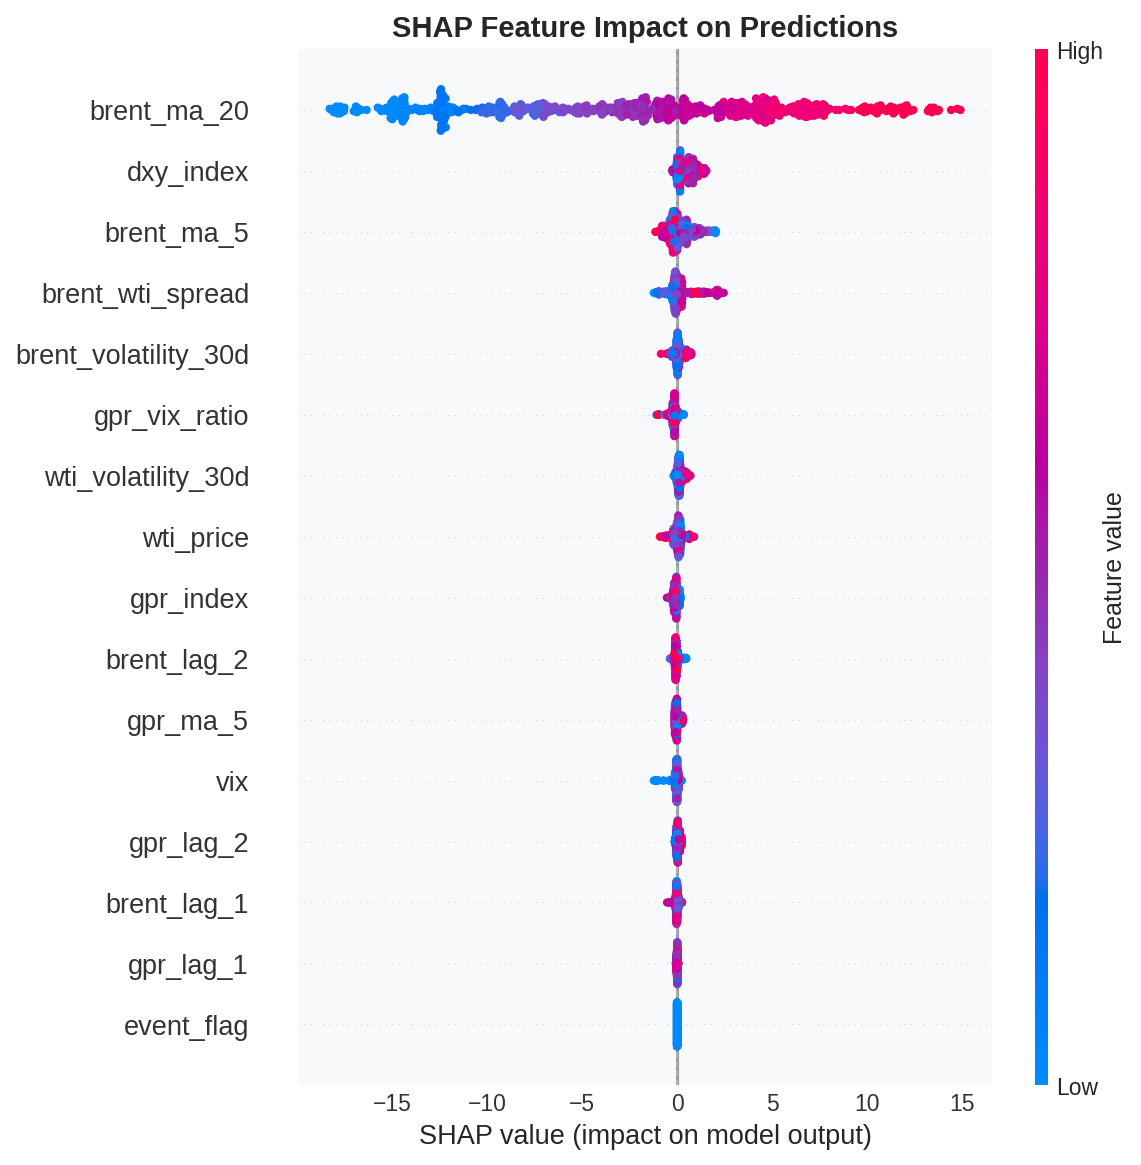

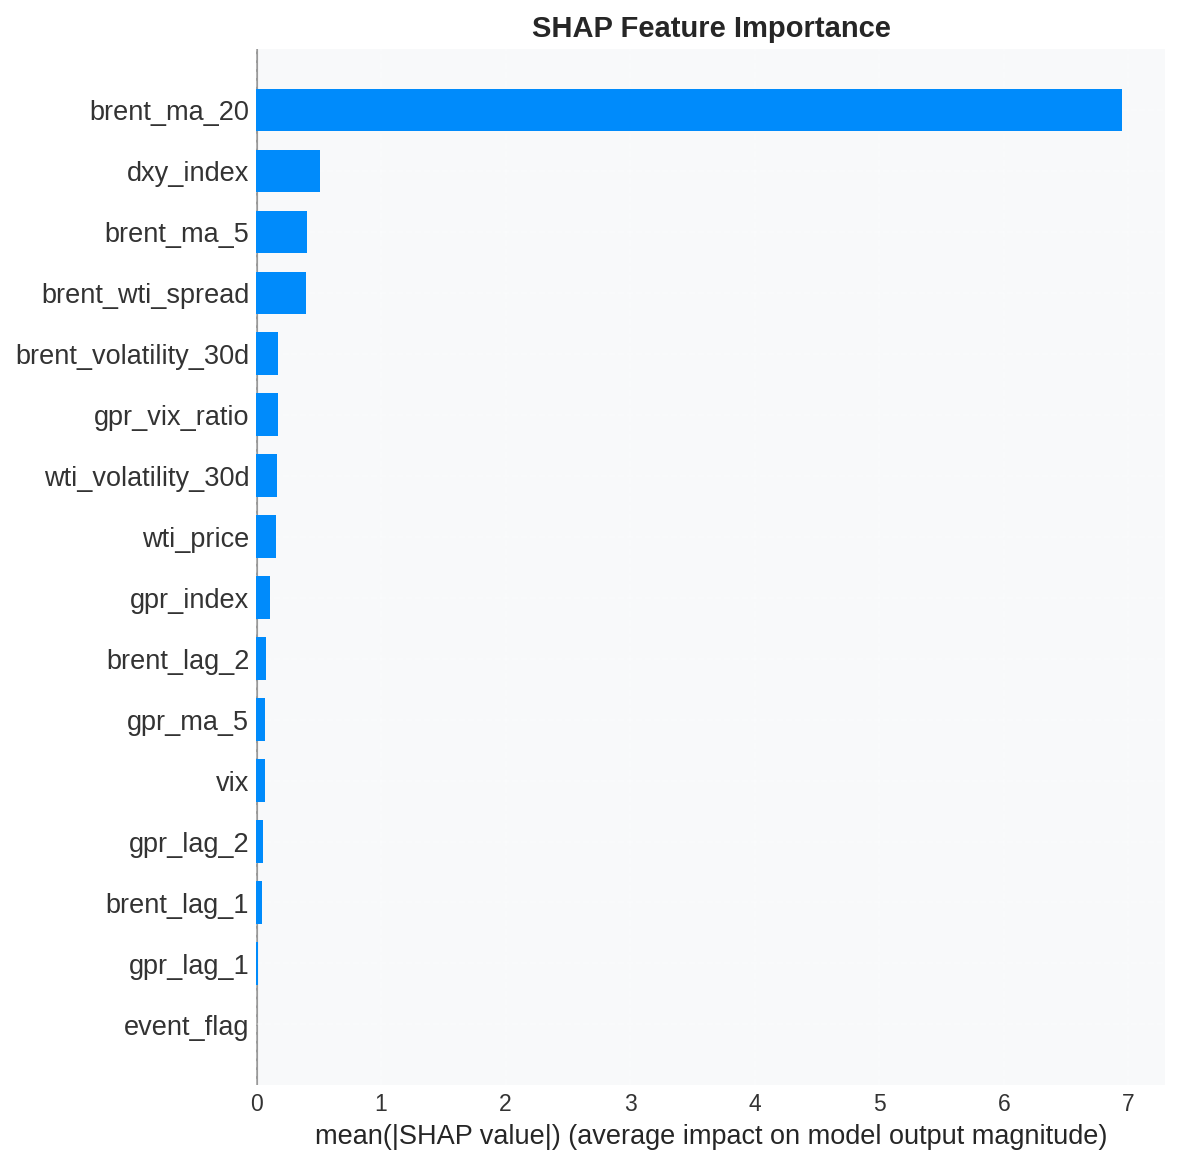

In [30]:
# Use XGBoost model for SHAP analysis
if len(ml_data_full) > 100:
    X_full = ml_data_full[feature_cols]
    y_full = ml_data_full['target']
    
    X_train_full, X_test_full = X_full[:split_idx], X_full[split_idx:]
    
    # Train model on full features
    xgb_full = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=6, random_state=42)
    xgb_full.fit(X_train_full, y_train)
    
    # Calculate SHAP values
    explainer = shap.TreeExplainer(xgb_full)
    shap_values = explainer.shap_values(X_test_full)
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_full, show=False)
    plt.title('SHAP Feature Impact on Predictions', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Bar plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_full, plot_type="bar", show=False)
    plt.title('SHAP Feature Importance', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.show()

#  PROPHET FORECASTING

17:45:50 - cmdstanpy - INFO - Chain [1] start processing
17:45:52 - cmdstanpy - INFO - Chain [1] done processing


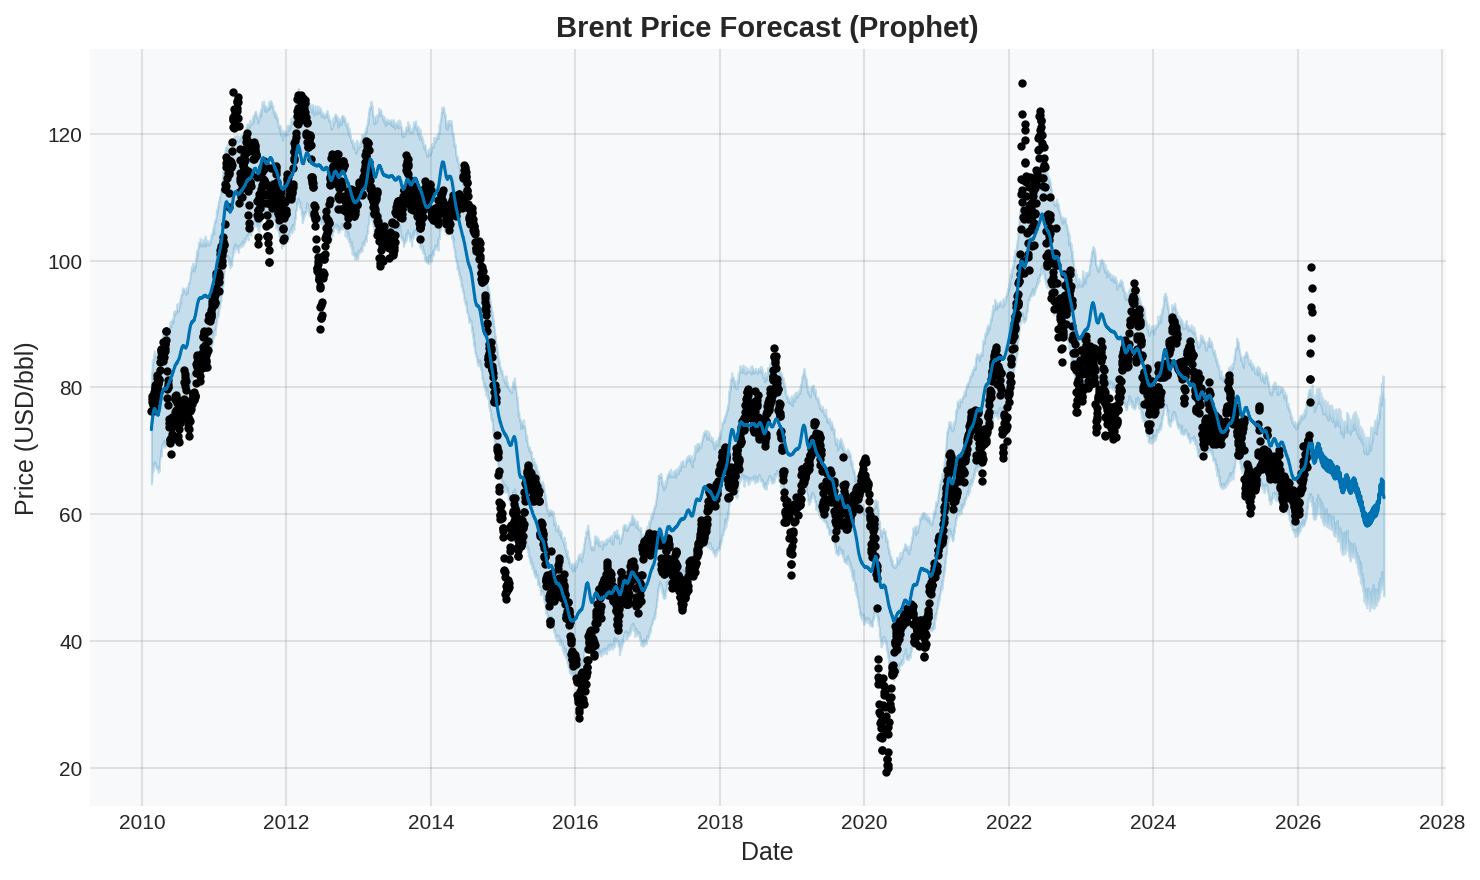

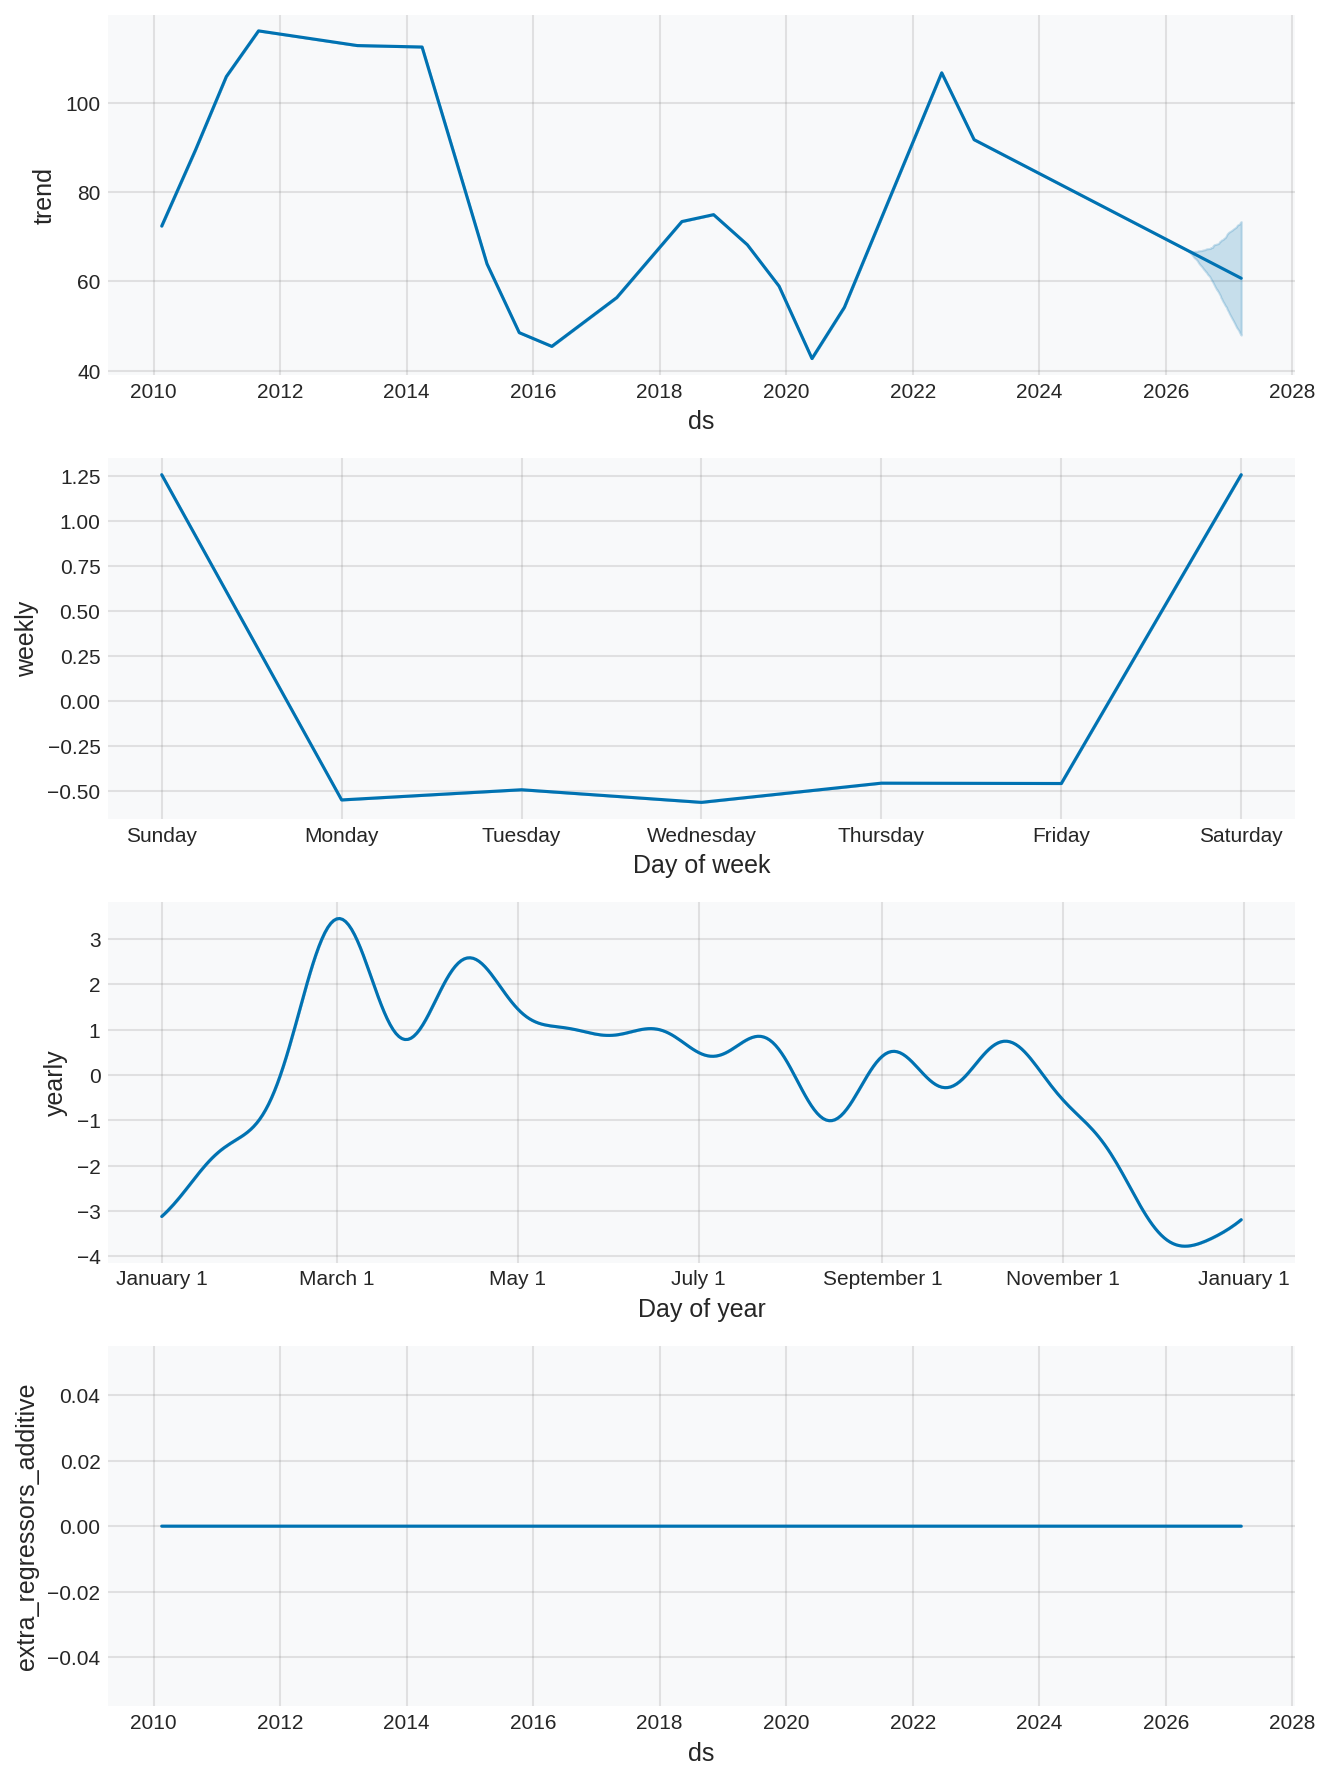


Forecast Summary (Next Year):
----------------------------------------
Predicted average price: $64.38
Price range: $44.77 - $81.82


In [31]:
# Prepare data for Prophet
prophet_df = df[["date", "brent_price"]].rename(
    columns={"date": "ds", "brent_price": "y"}
)

# Initialize and fit Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

# Add event regressor if available
if 'event_flag' in df.columns:
    prophet_df['event'] = df['event_flag'].values
    prophet_model.add_regressor('event')

prophet_model.fit(prophet_df)

# Create future dataframe (1 year)
future = prophet_model.make_future_dataframe(periods=365)

# Add event flag for future (assuming no events - conservative forecast)
if 'event' in prophet_df.columns:
    future['event'] = 0

# Generate forecast
forecast = prophet_model.predict(future)

# Plot forecast
fig = prophet_model.plot(forecast)
plt.title('Brent Price Forecast (Prophet)', fontweight='bold', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD/bbl)')
plt.tight_layout()
plt.show()

# Plot components
fig2 = prophet_model.plot_components(forecast)
plt.tight_layout()
plt.show()

# Display forecast metrics
print("\nForecast Summary (Next Year):")
print("-"*40)
future_forecast = forecast[forecast['ds'] > df['date'].max()]
print(f"Predicted average price: ${future_forecast['yhat'].mean():.2f}")
print(f"Price range: ${future_forecast['yhat_lower'].min():.2f} - ${future_forecast['yhat_upper'].max():.2f}")


#  INTERACTIVE PLOTLY DASHBOARD

##  Interactive oil price dashboard

In [32]:
fig1 = px.line(
    df,
    x="date",
    y=["brent_price", "wti_price"],
    title="Interactive Oil Price Dashboard (2010-2026)",
    labels={"value": "Price (USD/bbl)", "variable": "Oil Type"},
    color_discrete_map={"brent_price": COLORS['brent'], "wti_price": COLORS['wti']}
)

fig1.update_layout(
    hovermode='x unified',
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
    template="plotly_white"
)

fig1.show()




## Geopolitical Risk vs Oil Price

In [33]:

fig2 = px.scatter(
    df,
    x="gpr_index",
    y="brent_price",
    color="vix",
    size="brent_volatility_30d",
    hover_data=["date", "event_type"],
    title="Geopolitical Risk vs Oil Price (colored by VIX)",
    labels={"gpr_index": "GPR Index", "brent_price": "Brent Price (USD/bbl)"},
    color_continuous_scale="Viridis"
)

fig2.update_layout(template="plotly_white")
fig2.show()



## 3D Scatter Plot

In [34]:

fig3 = go.Figure(data=[go.Scatter3d(
    x=df['gpr_index'],
    y=df['vix'],
    z=df['brent_price'],
    mode='markers',
    marker=dict(
        size=3,
        color=df['brent_volatility_30d'],
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Volatility")
    ),
    text=df['date'].dt.strftime('%Y-%m-%d'),
    hovertemplate='<b>Date</b>: %{text}<br>' +
                  '<b>GPR</b>: %{x:.1f}<br>' +
                  '<b>VIX</b>: %{y:.1f}<br>' +
                  '<b>Price</b>: $%{z:.2f}<br>' +
                  '<extra></extra>'
)])

fig3.update_layout(
    title='3D Visualization: GPR, VIX, and Oil Price',
    scene=dict(
        xaxis_title='GPR Index',
        yaxis_title='VIX',
        zaxis_title='Brent Price (USD/bbl)'
    ),
    template="plotly_white"
)

fig3.show()



## Event timeline

In [35]:

event_counts = events_df.groupby(events_df['date'].dt.to_period('M')).size().reset_index()
event_counts['date'] = event_counts['date'].astype(str)

fig4 = px.bar(
    event_counts,
    x='date',
    y=0,
    title='Geopolitical Events Timeline (Monthly)',
    labels={'date': 'Year-Month', '0': 'Number of Events'},
    color_discrete_sequence=[COLORS['event']]
)

fig4.update_layout(
    xaxis_tickangle=-45,
    template="plotly_white"
)

fig4.show()

#  EXTREME EVENTS ANALYSIS

In [36]:
# Identify extreme price movements
df['extreme_return'] = (df['brent_return'].abs() > df['brent_return'].std() * 2).astype(int)
df['extreme_volatility'] = (df['brent_volatility_30d'] > df['brent_volatility_30d'].quantile(0.95)).astype(int)

print(f"\nExtreme Return Days (|return| > 2σ): {df['extreme_return'].sum():,} ({df['extreme_return'].mean()*100:.2f}%)")
print(f"Extreme Volatility Days (>95th percentile): {df['extreme_volatility'].sum():,} ({df['extreme_volatility'].mean()*100:.2f}%)")

# Analyze what drives extremes
extreme_analysis = df.groupby('extreme_return').agg({
    'gpr_index': 'mean',
    'vix': 'mean',
    'brent_volatility_30d': 'mean',
    'event_flag': 'mean'
}).round(4)

print("\nCharacteristics of Extreme Return Days:")
print("-"*60)
print(extreme_analysis.to_string())

# Top 10 biggest price movements
top_moves = df.nlargest(10, 'brent_return')[['date', 'brent_return', 'brent_price', 
                                              'gpr_index', 'event_flag', 'event_description']]
bottom_moves = df.nsmallest(10, 'brent_return')[['date', 'brent_return', 'brent_price', 
                                                  'gpr_index', 'event_flag', 'event_description']]


print(top_moves.to_string(index=False))


print(bottom_moves.to_string(index=False))



Extreme Return Days (|return| > 2σ): 187 (4.62%)
Extreme Volatility Days (>95th percentile): 203 (5.02%)

Characteristics of Extreme Return Days:
------------------------------------------------------------
                gpr_index     vix  brent_volatility_30d  event_flag
extreme_return                                                     
0                102.0693  18.040                0.0189         1.0
1                113.4773  25.684                0.0354         1.0
      date  brent_return  brent_price  gpr_index  event_flag event_description
2020-04-02      0.210186    29.940001  69.339401           1              none
2019-09-16      0.146131    69.019997 103.404419           1              none
2020-03-19      0.144293    28.469999  73.078384           1              none
2020-04-03      0.139279    34.110001  69.339401           1              none
2020-05-05      0.138603    30.969999  68.507217           1              none
2020-04-30      0.121118    25.270000  69.3394